# Media delle Medie — Stress Relaxation

Questo notebook calcola la **grand mean** (media delle curve medie) a partire dai file `*-media-norm.jpk-force` generati da `Rilassamento.ipynb`.

**Flusso di lavoro:**
1. Seleziona una o più cartelle radice (es. `270326`, `140326/D2_A1`)
2. Il notebook trova automaticamente tutti i file `*-media-norm.jpk-force` nelle sottocartelle `SR`
3. Calcola la media delle medie e produce grafici + report PDF

**Uso rapido:** imposta i percorsi nella cella 2 ed esegui dall'alto verso il basso.

In [67]:
# 1. Import librerie e utility
import sys
sys.path.insert(0, r'/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo')

import warnings
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from sr_utils import (
    load_stress_relaxation_curve,
    calculate_mean_curve,
    smooth_signal,
    despike_signal,
    interpolate_relaxation_curves,
    run_sr_analysis,
    load_sr_curve,
)

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [68]:
# 2. Configurazione: cartelle radice da analizzare
#
# Aggiungi qui i percorsi delle cartelle radice che vuoi includere nella grand mean.
# Puoi mescolare liberamente cartelle ADLD e CTL nello stesso elenco.
# Ogni cartella verrà scansionata ricorsivamente per trovare, in ordine di priorita:
#   1) file riassuntivi giornata (`*_area_results_summary.csv`) con colonna jpk_path
#   2) file medi gia salvati (`*-media-norm.jpk-force`)
#   3) cartelle con curve raw `.jpk-force` / `.jpk` da cui ricostruire la media in memoria
#
# Esempi:
#   - r"/Users/furbetta/.../Dati_ADLD/24-05-2024_ADLD/sample1"
#   - r"/Users/furbetta/.../Dati_CTL/08-11-2024_CTL_P9"

ROOT_FOLDERS = [
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_EV_130526",
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_EV_140526",
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_EV_090626",
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_EV_100626",
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_EV_250626",
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_EV_260626",
    
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_RAB5_090626",
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_RAB5_100626",
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_RAB5_150626",
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_RAB5_160626",
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_RAB5_250626",
    r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_RAB5_260626",
    
    
    


    
    # aggiungi qui anche i percorsi CTL...
    # r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/Dati_CTL/...",
]

# --- Etichette opzionali per i gruppi (lascia [] per usare il nome della cartella) ---
GROUP_LABELS = []

# --- Parametri di caricamento ---
segment_index    = None   # None = rilevamento automatico del segmento pause/dwell
normalization_mode = "peak"
reference_points   = 200

# --- Parametri media ---
smoothing_window = 31    # None per disattivare
outlier_sigma    = 3.0   # filtro robusto 3-sigma
min_valid_curves = 2

# --- Parametri usati se bisogna ricostruire la media dalle curve raw ---
raw_spike_filter_window = 9
raw_spike_filter_z = 3.0
raw_indentation_auto_mode = "median"
save_generated_means_for_grand_mean = False
save_generated_csv_for_grand_mean = False

# Se True usa prima i file riassuntivi giornata generati da Rilassamento (colonna jpk_path).
USE_DAY_AREA_SUMMARY_FILES = True
DAY_AREA_SUMMARY_GLOB = "*_area_results_summary.csv"

# Se True usa solo file medi gia' salvati (consigliato quando hai gia' generato le medie per area)
USE_ONLY_SAVED_MEANS = True

# --- Esclusione automatica curve anomale ---
curve_exclusion_time_s = 10.0        # valuta l'anomalia nei primi secondi piu informativi
curve_exclusion_sigma = 3.0
curve_exclusion_max_fraction = 0.20
curve_exclusion_min_value = -0.30
curve_exclusion_max_value = 1.05
# Escludi sempre curve troppo corte per mantenere affidabile il fit post-0.5 s
min_curve_duration_s = 5.0
# Escludi curve con plateau finale troppo basso (non fisico dopo normalizzazione)
min_plateau_force = -0.15

# --- Transizione poro -> visco anche nel fit finale delle medie ---
transition_time_s = 0.5
auto_optimize_transition = True
transition_search_range_s = (0.25, 1.20)
transition_search_steps = 41
transition_max_join_gap = 0.03
transition_max_local_rmse = 0.05
transition_late_models = ("plr", "bi", "mono")
transition_min_late_r2 = 0.90
show_transition_diagnostic_plot = False  # False = non mostra il grafico diagnostico poro/visco

# --- Diagnostica pulizia/rumore ---
cleaning_report_top_n = 10

# --- Visualizzazione finale ---
plot_max_time_s = 10.0   # limita i grafici finali ai primi 10 secondi

# --- Output ---
output_folder = r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/aggregated/Riassuntoumane"    # None -> salva nella prima cartella radice selezionata
experiment_label = "grand_mean"   # prefisso del file PDF di output
save_outputs = True

In [69]:
# 2b. Configurazione aggregazione A1/0R
# Se True, la cella finale esegue analisi separate per A1 e 0R
# e costruisce una tabella riassuntiva per gruppo.
ENABLE_A1_0R_ANALYSIS = True

# Alias retrocompatibile usato nel codice esistente
ENABLE_EV_RAB5_ANALYSIS = ENABLE_A1_0R_ANALYSIS

# Se False, include anche curve non classificate come A1/0R nel report di log (non nella tabella finale)
INCLUDE_UNCLASSIFIED = False

# File CSV della tabella finale (salvato in aggregated/Riassunto/SR)
SUMMARY_TABLE_NAME = "sr_summary_A1_0R.csv"

# Macro-gruppi confrontati nella cella finale
MACRO_GROUPS = ("A1", "0R")

In [70]:
# 2c. Setup robusto variabili globali usate nelle celle successive
import pandas as pd

if "visual_spike_window" not in globals():
    visual_spike_window = 9
if "visual_spike_z" not in globals():
    visual_spike_z = 3.0

In [71]:
# 3. Scansione: trova curve medie salvate oppure cartelle raw da cui ricostruirle
from collections import defaultdict
import pandas as pd

_MEAN_TAGS = ("media-norm", "mean-norm")
_RAW_EXCLUDE_TAGS = ("-mean", "-media", "-norm")
_RAW_FOLDER_EXCLUDE_TOKENS = ("sbstr", "substr")


def _is_saved_mean_file(path_obj):
    stem_lower = path_obj.stem.lower()
    return any(tag in stem_lower for tag in _MEAN_TAGS)


def _is_raw_curve_file(path_obj):
    stem_lower = path_obj.stem.lower()
    return not any(tag in stem_lower for tag in _RAW_EXCLUDE_TAGS)


def _is_usable_raw_folder(folder_path):
    folder_name = folder_path.name.lower()
    return not any(token in folder_name for token in _RAW_FOLDER_EXCLUDE_TOKENS)


def _is_in_sr_subtree(path_obj):
    return any(part.upper() == "SR" for part in path_obj.parts)


def _load_mean_paths_from_day_summaries(root):
    summary_files = sorted(root.rglob(DAY_AREA_SUMMARY_GLOB))
    if not summary_files:
        return []

    found_paths = []
    for summary_path in summary_files:
        try:
            df = pd.read_csv(summary_path)
        except Exception as exc:
            print(f"  ! Impossibile leggere {summary_path.name}: {exc}")
            continue

        if "jpk_path" not in df.columns:
            print(f"  ! {summary_path.name}: colonna 'jpk_path' non trovata")
            continue

        for raw_path in df["jpk_path"].dropna().astype(str):
            p = Path(raw_path)
            if p.exists() and p.is_file():
                found_paths.append(p)

    # dedup mantenendo ordine
    unique_paths = []
    seen = set()
    for p in found_paths:
        s = str(p.resolve())
        if s in seen:
            continue
        seen.add(s)
        unique_paths.append(p)
    return unique_paths


def find_group_inputs(root_folder):
    """
    Cerca ricorsivamente sorgenti valide per la grand mean.
    Priorita: file riassuntivi giornata, poi file medi, poi raw.
    Restituisce una lista ordinata di Path: file medi oppure cartelle contenenti curve raw.
    """
    root = Path(root_folder)
    if not root.exists():
        raise FileNotFoundError(f"Cartella non trovata: {root_folder}")

    if USE_DAY_AREA_SUMMARY_FILES:
        summary_mean_files = _load_mean_paths_from_day_summaries(root)
        if summary_mean_files:
            return summary_mean_files

    # File medi: cerca ovunque sotto la root (le medie area possono essere salvate fuori da SR).
    mean_files = sorted(
        path for path in root.rglob("*.jpk-force")
        if path.is_file() and _is_saved_mean_file(path)
    )

    if USE_ONLY_SAVED_MEANS:
        return list(mean_files)

    # Raw fallback: includi solo file nella sottostruttura SR (esclude FD e altre cartelle).
    raw_dirs = defaultdict(list)
    for pattern in ("*.jpk-force", "*.jpk"):
        for path in root.rglob(pattern):
            if not path.is_file() or not _is_raw_curve_file(path):
                continue
            if not _is_in_sr_subtree(path.parent):
                continue
            if not _is_usable_raw_folder(path.parent):
                continue
            raw_dirs[path.parent].append(path)

    covered_dirs = {path.parent.resolve() for path in mean_files}
    raw_folder_sources = [
        folder for folder, files in sorted(raw_dirs.items())
        if len(files) >= 2 and folder.resolve() not in covered_dirs
    ]

    return list(mean_files) + raw_folder_sources


# Scansiona tutti i ROOT_FOLDERS
all_groups = {}   # label -> lista di Path (file medio oppure cartella raw)
for idx, folder in enumerate(ROOT_FOLDERS):
    folder_path = Path(folder)
    if GROUP_LABELS and idx < len(GROUP_LABELS):
        label = GROUP_LABELS[idx]
    else:
        parts = folder_path.parts
        label = "/".join(parts[-2:]) if len(parts) >= 2 else folder_path.name

    sources = find_group_inputs(folder)
    all_groups[label] = sources
    print(f"[{label}]  ->  {len(sources)} sorgenti trovate")
    for source in sources:
        if source.is_file():
            try:
                rel = source.relative_to(folder_path)
            except Exception:
                rel = source
            print(f"   • mean file: {rel}")
        else:
            print(f"   • raw folder: {source.relative_to(folder_path.parent)}")
    print()

total_curves = sum(len(v) for v in all_groups.values())
print(f"Totale sorgenti da includere nella grand mean: {total_curves}")
if USE_DAY_AREA_SUMMARY_FILES:
    print("Modalita scansione: priorita ai file riassuntivi giornata")
elif USE_ONLY_SAVED_MEANS:
    print("Modalita scansione: solo file medi salvati")

[PyFMGUI_DyNaMo/MCF10_EV_130526]  ->  4 sorgenti trovate
   • mean file: cell02/Area2_SR-0000-media-norm.jpk-force
   • mean file: cell03/Area3_SR-0004-media-norm.jpk-force
   • mean file: cell04/Area4_SR-0000-media-norm.jpk-force
   • mean file: cell05/Area5_SR-0000-1-media-norm.jpk-force

[PyFMGUI_DyNaMo/MCF10_EV_140526]  ->  3 sorgenti trovate
   • mean file: cell01/Area1_FD-0000-media-norm.jpk-force
   • mean file: cell02/Area2_SR-0000-media-norm.jpk-force
   • mean file: cell03/Area3_SR-0000-media-norm.jpk-force

[PyFMGUI_DyNaMo/MCF10_EV_090626]  ->  9 sorgenti trovate
   • mean file: cell01/Area1_SR-0000-media-norm.jpk-force
   • mean file: cell02/Area2_SR-0000-media-norm.jpk-force
   • mean file: cell03/Area3_SR-0000-media-norm.jpk-force
   • mean file: cell05/Area5_SR-0000-media-norm.jpk-force
   • mean file: cell06/Area6_SR-0000-media-norm.jpk-force
   • mean file: cell07/Area7_SR-0000-media-norm.jpk-force
   • mean file: cell08/Area8_SR-0000-media-norm.jpk-force
   • mean fil

In [72]:
# 4. Caricamento delle curve medie: usa file salvati se presenti, altrimenti ricostruisce da raw
import importlib
import zipfile as _zipfile

import sr_utils
importlib.reload(sr_utils)

from sr_utils import get_force_curve_and_segment


def _read_force_channel(jpk_path, seg_idx):
    with _zipfile.ZipFile(str(jpk_path), "r") as zf:
        dat_name = f"segments/{seg_idx}/channels/vDeflection.dat"
        raw_bytes = zf.read(dat_name)
    return np.frombuffer(raw_bytes, dtype="<f4")


def _build_curve_from_raw(force_raw, time_data, distance_data, seg_idx, seg_name):
    n_points = len(time_data)

    if len(force_raw) != n_points:
        src_idx = np.linspace(0, len(force_raw) - 1, n_points)
        force_norm = np.interp(src_idx, np.arange(len(force_raw)), force_raw).astype(np.float32)
    else:
        force_norm = force_raw.astype(np.float32)

    head = min(max(10, n_points // 50), n_points)
    if np.nanmedian(force_norm[:head]) < 0:
        force_norm = -force_norm

    return {
        "time": time_data,
        "force": force_norm,
        "normalized_force": force_norm,
        "distance": distance_data,
        "segment_index": seg_idx,
        "segment_name": seg_name,
        "reference_force": 1.0,
    }


def _load_saved_mean_curve(jpk_path):
    seg = get_force_curve_and_segment(str(jpk_path), segment_index=segment_index)
    force_raw = _read_force_channel(jpk_path, seg["segment_index"])
    return _build_curve_from_raw(
        force_raw=force_raw,
        time_data=seg["time"],
        distance_data=seg["distance"],
        seg_idx=seg["segment_index"],
        seg_name=seg["segment_name"],
    )


def _load_generated_mean_curve(folder_path):
    generated_input = sr_utils.resolve_sr_input(
        str(folder_path),
        num_curves=None,
        selected_curve_names=None,
        segment_index=segment_index,
        normalization_mode=normalization_mode,
        reference_points=reference_points,
        outlier_sigma=outlier_sigma,
        min_valid_curves=min_valid_curves,
        smoothing_window=smoothing_window,
        spike_filter_window=raw_spike_filter_window,
        spike_filter_z=raw_spike_filter_z,
        indentation_auto_mode=raw_indentation_auto_mode,
        save_preprocessed_mean=save_generated_means_for_grand_mean,
        save_mean_csv=save_generated_csv_for_grand_mean,
    )

    return {
        "time": np.asarray(generated_input["time"], dtype=np.float32),
        "force": np.asarray(generated_input["force"], dtype=np.float32),
        "normalized_force": np.asarray(generated_input["force"], dtype=np.float32),
        "distance": np.asarray(generated_input["distance"], dtype=np.float32),
        "segment_index": int(segment_index) if segment_index is not None else 0,
        "segment_name": "generated_mean_in_memory",
        "reference_force": 1.0,
    }


# --- Caricamento ---
loaded_curves = []
load_errors = []

for group_label, source_list in all_groups.items():
    for source_path in source_list:
        try:
            if source_path.is_file():
                curve = _load_saved_mean_curve(source_path)
                curve_origin = source_path.parent.name
                source_kind = "mean file"
            else:
                curve = _load_generated_mean_curve(source_path)
                curve_origin = source_path.name
                source_kind = "raw folder"

            curve["label"] = f"{group_label} / {curve_origin}"
            curve["source_path"] = str(source_path)
            curve["source_kind"] = source_kind
            loaded_curves.append(curve)

            f_range = f"[{np.nanmin(curve['normalized_force']):.3f}, {np.nanmax(curve['normalized_force']):.3f}]"
            print(f"  ✓  {curve['label']}  [{source_kind}]  ({len(curve['time'])} pt)  F={f_range}")
        except Exception as exc:
            load_errors.append((str(source_path), str(exc)))
            print(f"  ✗  ERRORE: {source_path.name}  →  {exc}")

print(f"\nCaricate con successo: {len(loaded_curves)} curve medie")
if load_errors:
    print(f"Errori durante il caricamento: {len(load_errors)}")

  ✓  PyFMGUI_DyNaMo/MCF10_EV_130526 / cell02  [mean file]  (150000 pt)  F=[0.130, 1.000]
  ✓  PyFMGUI_DyNaMo/MCF10_EV_130526 / cell03  [mean file]  (150000 pt)  F=[0.099, 1.000]
  ✓  PyFMGUI_DyNaMo/MCF10_EV_130526 / cell04  [mean file]  (150000 pt)  F=[0.155, 1.000]
  ✓  PyFMGUI_DyNaMo/MCF10_EV_130526 / cell05  [mean file]  (150000 pt)  F=[-0.115, 1.000]
  ✓  PyFMGUI_DyNaMo/MCF10_EV_140526 / cell01  [mean file]  (150000 pt)  F=[-0.602, 1.000]
  ✓  PyFMGUI_DyNaMo/MCF10_EV_140526 / cell02  [mean file]  (150000 pt)  F=[-0.051, 1.000]
  ✓  PyFMGUI_DyNaMo/MCF10_EV_140526 / cell03  [mean file]  (150000 pt)  F=[-0.244, 1.000]
  ✓  PyFMGUI_DyNaMo/MCF10_EV_090626 / cell01  [mean file]  (150000 pt)  F=[-1.137, 1.000]
  ✓  PyFMGUI_DyNaMo/MCF10_EV_090626 / cell02  [mean file]  (150000 pt)  F=[-1.005, 1.750]
  ✓  PyFMGUI_DyNaMo/MCF10_EV_090626 / cell03  [mean file]  (150000 pt)  F=[-0.981, 1.000]
  ✓  PyFMGUI_DyNaMo/MCF10_EV_090626 / cell05  [mean file]  (150000 pt)  F=[-1.000, 1.497]
  ✓  PyFMGUI_

In [73]:
# 5. Selezione curve affidabili + calcolo della Grand Mean

if len(loaded_curves) < 2:
    raise ValueError(f"Servono almeno 2 curve medie per calcolare la grand mean. "
                     f"Trovate: {len(loaded_curves)}")

# 0) Esclusioni hard: curve troppo corte o con plateau finale non fisico
curve_tmax = np.array([
    float(np.nanmax(np.asarray(c["time"], dtype=float))) if len(c["time"]) > 0 else np.nan
    for c in loaded_curves
], dtype=float)
curve_plateau = np.array([
    float(np.nanmean(np.asarray(c["normalized_force"], dtype=float)[-min(50, len(c["normalized_force"])):]))
    if len(c["normalized_force"]) > 0 else np.nan
    for c in loaded_curves
] , dtype=float)

duration_fail = curve_tmax < float(min_curve_duration_s)
plateau_fail = curve_plateau < float(min_plateau_force)

# 1) Filtro range (soft)
curve_mins = np.array([np.nanmin(c["normalized_force"]) for c in loaded_curves], dtype=float)
curve_maxs = np.array([np.nanmax(c["normalized_force"]) for c in loaded_curves], dtype=float)
range_fail = (curve_mins < curve_exclusion_min_value) | (curve_maxs > curve_exclusion_max_value)

# 2) Filtro forma (soft)
time_grid, interpolated_forces, _ = interpolate_relaxation_curves(loaded_curves)
analysis_mask = time_grid <= float(curve_exclusion_time_s)
forces_eval = interpolated_forces[:, analysis_mask] if np.any(analysis_mask) else interpolated_forces

median_force = np.nanmedian(forces_eval, axis=0)
curve_distance = np.nanmedian(np.abs(forces_eval - median_force), axis=1)
curve_distance = np.where(np.isfinite(curve_distance), curve_distance, np.inf)

finite_dist = curve_distance[np.isfinite(curve_distance)]
dist_mean = np.nanmean(finite_dist)
dist_std = np.nanstd(finite_dist)
dist_threshold = dist_mean + curve_exclusion_sigma * dist_std
shape_fail = curve_distance > dist_threshold

# Esclusioni hard e soft separate
hard_exclude_mask = duration_fail | plateau_fail
soft_exclude_mask = (range_fail | shape_fail) & (~hard_exclude_mask)

# 3) Salvaguardia sulle esclusioni soft
n_total = len(loaded_curves)
n_soft_initial = int(np.sum(soft_exclude_mask))
max_soft_allowed = int(np.floor(float(curve_exclusion_max_fraction) * n_total))
max_soft_allowed = min(max_soft_allowed, max(0, n_total - int(np.sum(hard_exclude_mask)) - 2))

if n_soft_initial > max_soft_allowed:
    range_excess = np.maximum(curve_exclusion_min_value - curve_mins, 0.0) + np.maximum(curve_maxs - curve_exclusion_max_value, 0.0)
    shape_excess = np.maximum(curve_distance - dist_threshold, 0.0)
    severity = range_excess + shape_excess

    candidate_idx = np.where(soft_exclude_mask)[0]
    order = np.argsort(severity[candidate_idx])[::-1]
    idx_to_keep_soft_excluded = candidate_idx[order[:max_soft_allowed]] if max_soft_allowed > 0 else np.array([], dtype=int)

    relaxed_soft_mask = np.zeros_like(soft_exclude_mask, dtype=bool)
    relaxed_soft_mask[idx_to_keep_soft_excluded] = True

    restored = n_soft_initial - int(np.sum(relaxed_soft_mask))
    soft_exclude_mask = relaxed_soft_mask
    print(
        f"[RILASSAMENTO FILTRO SOFT] esclusioni soft iniziali={n_soft_initial}/{n_total} "
        f"-> limitate a {int(np.sum(soft_exclude_mask))}/{n_total} "
        f"(ripristinate {restored} curve, max_fraction={curve_exclusion_max_fraction})"
    )

exclude_mask = hard_exclude_mask | soft_exclude_mask
filtered_curves = [c for i, c in enumerate(loaded_curves) if not exclude_mask[i]]

if len(filtered_curves) < 2:
    print("Filtro non applicato: resterebbero meno di 2 curve.")
    excluded_curves = []
    filtered_curves = list(loaded_curves)
else:
    excluded_curves = []
    for i, c in enumerate(loaded_curves):
        if not exclude_mask[i]:
            continue
        reasons = []
        cmin = float(curve_mins[i])
        cmax = float(curve_maxs[i])
        if duration_fail[i]:
            reasons.append(f"curva troppo corta (t_max={curve_tmax[i]:.3f} s < {min_curve_duration_s:.3f} s)")
        if plateau_fail[i]:
            reasons.append(f"plateau finale basso (F_plateau={curve_plateau[i]:.3f} < {min_plateau_force:.3f})")
        if range_fail[i]:
            reasons.append(f"range fuori soglia (min={cmin:.3f}, max={cmax:.3f})")
        if shape_fail[i]:
            reasons.append(
                f"curva lontana dalla mediana (distance={curve_distance[i]:.4f}, soglia={dist_threshold:.4f}, {curve_exclusion_sigma}σ)"
            )
        excluded_curves.append({
            "label": c["label"],
            "source_path": c.get("source_path", "n/d"),
            "reason": " ; ".join(reasons),
        })

print("=== Selezione curve per la Grand Mean ===")
print(f"  Durata minima curva: {min_curve_duration_s} s")
print(f"  Plateau minimo finale: {min_plateau_force}")
print(f"  Range logico usato: [{curve_exclusion_min_value}, {curve_exclusion_max_value}]")
print(f"  Soglia esclusione forma: distanza > {curve_exclusion_sigma}σ  (media={dist_mean:.4f}, std={dist_std:.4f}, soglia={dist_threshold:.4f})")
print(f"  Curve iniziali : {len(loaded_curves)}")
print(f"  Curve tenute   : {len(filtered_curves)}")
print(f"  Curve escluse  : {len(excluded_curves)}")

if excluded_curves:
    print("Dettaglio curve escluse automaticamente:")
    for i, item in enumerate(excluded_curves, start=1):
        print(f"{i:02d}. {item['label']}")
        print(f"    motivo: {item['reason']}")
        print(f"    file:   {item.get('source_path', 'n/d')}")
else:
    print("Nessuna curva esclusa automaticamente.")

grand_time, grand_mean, grand_std, grand_distance, grand_stats = calculate_mean_curve(
    filtered_curves,
    outlier_sigma=outlier_sigma,
    min_valid_curves=min_valid_curves,
    smoothing_window=smoothing_window,
    spike_filter_window=visual_spike_window,
    spike_filter_z=visual_spike_z,
)

print("=== Grand Mean calcolata ===")
print(f"  Curve incluse       : {len(filtered_curves)}")
print(f"  Intervallo temporale: {grand_stats['t_min']:.4f} s  -> {grand_stats['t_max']:.4f} s")
print(f"  Punti temporali     : {grand_stats['n_timepoints_common']}")
print(f"  Valori outlier scart: {grand_stats['n_outlier_values']}")
print(f"  Spike corretti      : {grand_stats['n_spike_values']}")
print(f"  Smoothing window    : {grand_stats['smoothing_window']}")

# Diagnostica quantitativa per capire quanto rumore viene effettivamente rimosso
def _roughness_metric(y):
    y = np.asarray(y, dtype=float)
    if y.size < 3:
        return np.nan
    dy = np.diff(y)
    dy = dy[np.isfinite(dy)]
    if dy.size == 0:
        return np.nan
    return float(np.nanmedian(np.abs(dy)))

pre_t, pre_f, _ = interpolate_relaxation_curves(filtered_curves)
mask_pre = pre_t <= float(curve_exclusion_time_s)
if not np.any(mask_pre):
    mask_pre = np.ones_like(pre_t, dtype=bool)
pre_forces = pre_f[:, mask_pre]

post_rows = []
for row in pre_forces:
    row_clean, _ = despike_signal(
        row,
        window=int(visual_spike_window),
        z_thresh=float(visual_spike_z),
    )
    if smoothing_window is not None and int(smoothing_window) >= 5:
        row_clean = smooth_signal(row_clean, int(smoothing_window)).astype(float)
    post_rows.append(row_clean)
post_forces = np.asarray(post_rows, dtype=float)

pre_roughness = np.array([_roughness_metric(row) for row in pre_forces], dtype=float)
post_roughness = np.array([_roughness_metric(row) for row in post_forces], dtype=float)

pre_r = float(np.nanmedian(pre_roughness)) if np.any(np.isfinite(pre_roughness)) else np.nan
post_r = float(np.nanmedian(post_roughness)) if np.any(np.isfinite(post_roughness)) else np.nan
reduction_pct = 100.0 * (pre_r - post_r) / pre_r if np.isfinite(pre_r) and abs(pre_r) > 1e-12 and np.isfinite(post_r) else np.nan

n_points_total = int(np.prod(pre_forces.shape)) if pre_forces.size > 0 else 0
outlier_pct = 100.0 * grand_stats['n_outlier_values'] / n_points_total if n_points_total > 0 else np.nan
spike_pct = 100.0 * grand_stats['n_spike_values'] / n_points_total if n_points_total > 0 else np.nan

print("=== Diagnostica pulizia segnale ===")
print(f"  Punti valutati (curve x tempo): {n_points_total}")
print(f"  Outlier rimossi (3σ): {grand_stats['n_outlier_values']} ({outlier_pct:.2f}%)")
print(f"  Spike corretti: {grand_stats['n_spike_values']} ({spike_pct:.2f}%)")
print(f"  Rugosita mediana pre-pulizia : {pre_r:.6f}")
print(f"  Rugosita mediana post-pulizia: {post_r:.6f}")
print(f"  Riduzione rugosita: {reduction_pct:.2f}%")

[RILASSAMENTO FILTRO SOFT] esclusioni soft iniziali=14/56 -> limitate a 11/56 (ripristinate 3 curve, max_fraction=0.2)
=== Selezione curve per la Grand Mean ===
  Durata minima curva: 5.0 s
  Plateau minimo finale: -0.15
  Range logico usato: [-0.3, 1.05]
  Soglia esclusione forma: distanza > 3.0σ  (media=0.4747, std=0.3997, soglia=1.6737)
  Curve iniziali : 56
  Curve tenute   : 29
  Curve escluse  : 27
Dettaglio curve escluse automaticamente:
01. PyFMGUI_DyNaMo/MCF10_EV_140526 / cell01
    motivo: plateau finale basso (F_plateau=-0.445 < -0.150) ; range fuori soglia (min=-0.602, max=1.000)
    file:   /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_EV_140526/cell01/Area1_FD-0000-media-norm.jpk-force
02. PyFMGUI_DyNaMo/MCF10_EV_140526 / cell03
    motivo: plateau finale basso (F_plateau=-0.236 < -0.150)
    file:   /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/MCF10_EV_140526/cell03/Area3_SR-0000-media-norm.jpk-force
03. PyFMGUI_DyNaMo/MCF10_EV_090626 / cell01
    

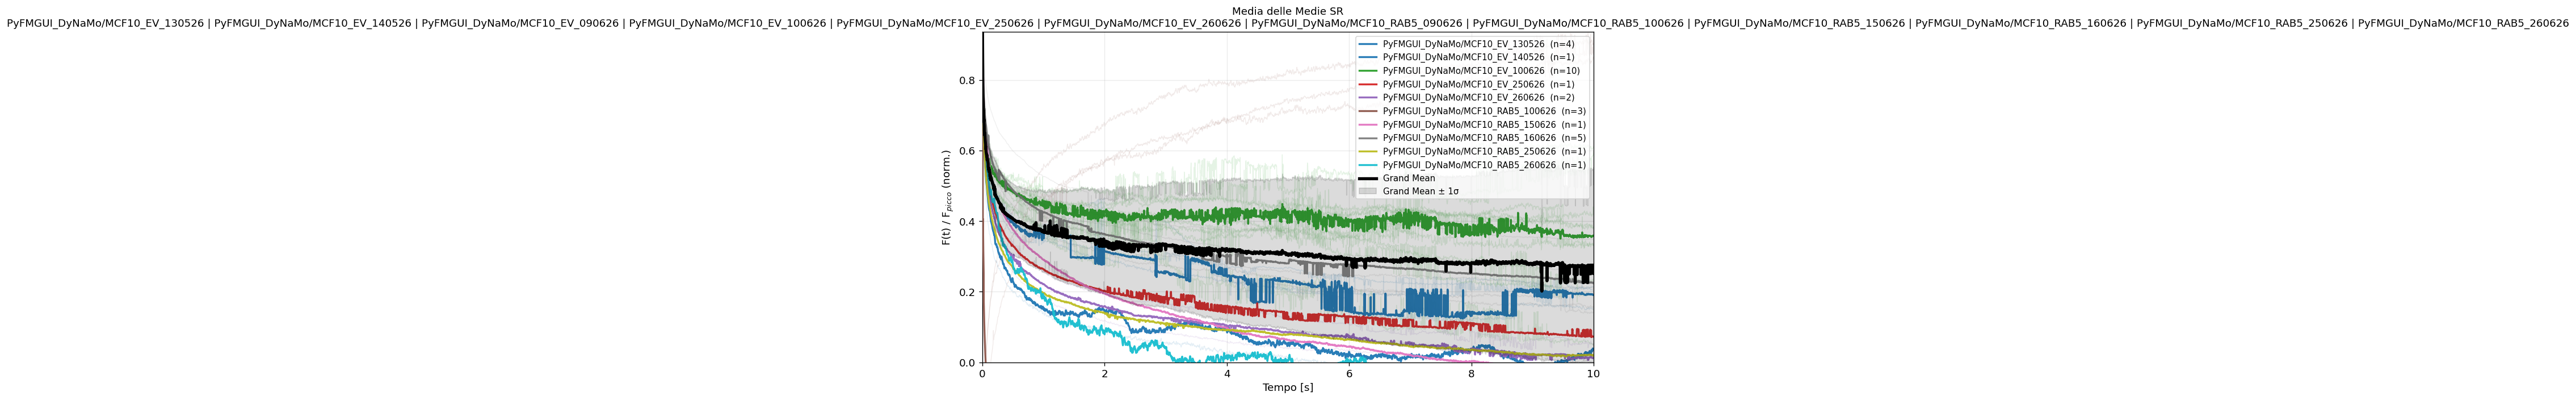

In [74]:
# 6. Visualizzazione: curve singole + medie per gruppo + Grand Mean

# Palette colori per i diversi gruppi
group_names = list(all_groups.keys())
group_colors = plt.cm.tab10(np.linspace(0, 0.9, max(len(group_names), 1)))
group_color_map = {g: group_colors[i] for i, g in enumerate(group_names)}

fig, ax = plt.subplots(figsize=(10.0, 6.0))

plot_values = []
visual_spike_window = 9
visual_spike_z = 3.0

# 1. Curve singole tenute nel calcolo, molto leggere, ripulite solo per la visualizzazione
for curve in filtered_curves:
    t = curve["time"]
    f = curve["normalized_force"]
    f, _ = despike_signal(f, window=visual_spike_window, z_thresh=visual_spike_z)
    if smoothing_window is not None and int(smoothing_window) >= 5:
        f = smooth_signal(f, int(smoothing_window))

    mask = t <= plot_max_time_s
    if not np.any(mask):
        continue

    t_plot = t[mask]
    f_plot = f[mask]
    finite_f = f_plot[np.isfinite(f_plot)]
    if len(finite_f) == 0:
        continue

    plot_values.append(finite_f)

    group_of_curve = next(
        (g for g, files in all_groups.items()
         if any(str(fp) == curve["source_path"] for fp in files)),
        group_names[0],
    )
    color = group_color_map[group_of_curve]
    ax.plot(t_plot, f_plot, lw=0.8, alpha=0.12, color=color, zorder=1)

# 2. Media di ciascun gruppo, ben visibile, usando solo le curve non escluse
for g_label, g_files in all_groups.items():
    group_curves = [
        c for c in filtered_curves
        if any(str(fp) == c["source_path"] for fp in g_files)
    ]
    if not group_curves:
        continue

    group_time, group_mean, _, _, _ = calculate_mean_curve(
        group_curves,
        outlier_sigma=outlier_sigma,
        min_valid_curves=max(1, min_valid_curves),
        smoothing_window=smoothing_window,
        spike_filter_window=visual_spike_window,
        spike_filter_z=visual_spike_z,
    )
    mask = group_time <= plot_max_time_s
    ax.plot(
        group_time[mask],
        group_mean[mask],
        lw=2.0,
        color=group_color_map[g_label],
        alpha=0.95,
        zorder=4,
        label=f"{g_label}  (n={len(group_curves)})",
    )
    plot_values.append(group_mean[mask])

# 3. Grand Mean
mean_mask = grand_time <= plot_max_time_s
ax.plot(grand_time[mean_mask], grand_mean[mean_mask], color="black", lw=3.2, zorder=6, label="Grand Mean")
ax.fill_between(
    grand_time[mean_mask],
    (grand_mean - grand_std)[mean_mask],
    (grand_mean + grand_std)[mean_mask],
    color="black", alpha=0.14, zorder=5, label="Grand Mean ± 1σ",
)
plot_values.append(grand_mean[mean_mask])
plot_values.append((grand_mean - grand_std)[mean_mask])
plot_values.append((grand_mean + grand_std)[mean_mask])

# 4. Limiti robusti dell'asse y
all_plot_values = np.concatenate([vals for vals in plot_values if len(vals) > 0])
all_plot_values = all_plot_values[np.isfinite(all_plot_values)]
if len(all_plot_values) > 0:
    y_low = np.nanpercentile(all_plot_values, 0.2)
    y_high = np.nanpercentile(all_plot_values, 99.8)
    y_low = max(0.0, y_low - 0.04)
    y_high = y_high + 0.04
    if y_high > y_low:
        ax.set_ylim(y_low, y_high)

folders_str = " | ".join(group_names)
ax.set_title(f"Media delle Medie SR\n{folders_str}", fontsize=11)
ax.set_xlabel("Tempo [s]")
ax.set_ylabel("F(t) / F$_{picco}$ (norm.)")
ax.set_xlim(0, plot_max_time_s)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [75]:
# 8. Analisi separata A1 vs 0R + tabella riassuntiva finale (Young, betaE, deltaF, transizione)

import importlib
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import sr_utils
importlib.reload(sr_utils)
from sr_utils import plr

run_sr_analysis = sr_utils.run_sr_analysis

def infer_macro_group(text):
    s = re.sub(r"[^A-Z0-9]+", "_", str(text).upper()).strip("_")
    if re.search(r"(^|_)A1(_|$)", s):
        return "A1"
    if re.search(r"(^|_)0R(_|$)", s):
        return "0R"
    return None


def fit_curve_metrics_for_sd(curve, smoothing_window_local=None, spike_window=9, spike_z=3.0):
    """Stima betaE (PLR con prefattore fisso a 1) e deltaF su una curva media singola."""
    t = np.asarray(curve["time"], dtype=float)
    f = np.asarray(curve["normalized_force"], dtype=float)
    m = np.isfinite(t) & np.isfinite(f)
    t = t[m]
    f = f[m]

    if len(t) < 20:
        return {"betaE": np.nan, "deltaF": np.nan}

    order = np.argsort(t)
    t = t[order]
    f = f[order]

    f_clean, _ = despike_signal(f, window=int(spike_window), z_thresh=float(spike_z))
    if smoothing_window_local is not None and int(smoothing_window_local) >= 5:
        f_clean = smooth_signal(f_clean, int(smoothing_window_local)).astype(float)

    if np.isfinite(f_clean[0]) and abs(f_clean[0]) > 1e-12:
        f_clean = f_clean / f_clean[0]

    avg_pts = min(50, len(f_clean))
    delta_f = float(f_clean[0] - np.mean(f_clean[-avg_pts:]))

    mask_plr = (t > 0.5) & np.isfinite(f_clean) & (f_clean > 0)
    t_plr = t[mask_plr]
    y_plr = f_clean[mask_plr]

    if len(t_plr) < 10:
        return {"betaE": np.nan, "deltaF": delta_f}

    t0_fix = float(t_plr[0])

    def _plr_fixed_t0(tt, beta):
        return plr(tt, 1.0, t0_fix, beta)

    try:
        popt, _ = curve_fit(
            _plr_fixed_t0,
            t_plr,
            y_plr,
            p0=[0.2],
            maxfev=20000,
            bounds=([0.01], [2.0]),
        )
        beta_val = float(popt[0])
    except Exception:
        beta_val = np.nan

    return {"betaE": beta_val, "deltaF": delta_f}


def collect_young_summaries(root_folders):
    """Legge i *_young_summary.json prodotti da Rilassamento e li divide in A1/0R."""
    grouped = {macro: [] for macro in MACRO_GROUPS}
    seen = set()

    for root in root_folders:
        root_path = Path(root)
        if not root_path.exists():
            continue
        for summary_path in root_path.rglob("*_young_summary.json"):
            resolved = str(summary_path.resolve())
            if resolved in seen:
                continue
            seen.add(resolved)

            try:
                data = json.loads(summary_path.read_text())
            except Exception:
                continue

            key_text = f"{data.get('data_dir', '')} {data.get('analysis_label', '')} {summary_path}"
            macro = infer_macro_group(key_text)
            if macro not in grouped:
                continue

            young_pa = data.get("young_modulus_pa")
            if young_pa is None or not np.isfinite(float(young_pa)):
                continue

            grouped[macro].append(float(young_pa))

    return grouped


analysis_enabled = bool(globals().get("ENABLE_A1_0R_ANALYSIS", ENABLE_EV_RAB5_ANALYSIS))
if not analysis_enabled:
    print("Analisi A1/0R disattivata (ENABLE_A1_0R_ANALYSIS=False)")
else:
    grouped_curves = {macro: [] for macro in MACRO_GROUPS}
    unclassified = []

    for curve in filtered_curves:
        key_text = f"{curve.get('label', '')} {curve.get('source_path', '')}"
        macro = infer_macro_group(key_text)
        if macro in grouped_curves:
            grouped_curves[macro].append(curve)
        else:
            unclassified.append(curve)

    print("Classificazione curve (dopo filtri):")
    for macro in MACRO_GROUPS:
        print(f"  {macro}: {len(grouped_curves[macro])}")
    print(f"  non classificate: {len(unclassified)}")
    if unclassified and INCLUDE_UNCLASSIFIED:
        print(f"Curve non classificate A1/0R: {len(unclassified)}")

    out_base = Path(output_folder) if output_folder is not None else Path(ROOT_FOLDERS[0])
    summary_dir = out_base / "Riassunto" / "SR"
    summary_dir.mkdir(parents=True, exist_ok=True)

    classification_log_df = pd.DataFrame([
        {
            "label": curve.get("label", "n/d"),
            "source_path": curve.get("source_path", "n/d"),
            "macro_group": infer_macro_group(f"{curve.get('label', '')} {curve.get('source_path', '')}"),
        }
        for curve in filtered_curves
    ])
    classification_log_path = summary_dir / "sr_curve_classification_log_A1_0R.csv"
    classification_log_df.to_csv(classification_log_path, index=False)
    print(f"Log classificazione curve salvato in: {classification_log_path}")

    spike_w = int(globals().get("visual_spike_window", 9))
    spike_z = float(globals().get("visual_spike_z", 3.0))

    young_by_group = collect_young_summaries(ROOT_FOLDERS)
    print("\nRiepiloghi Young trovati:")
    for macro in MACRO_GROUPS:
        print(f"  {macro}: {len(young_by_group[macro])}")

    summary_rows = []
    analysis_results_by_group = {}

    for macro in MACRO_GROUPS:
        curves_macro = grouped_curves[macro]
        if len(curves_macro) < 2:
            print(f"[{macro}] curve insufficienti per grand mean: {len(curves_macro)}")
            continue

        print(f"\n=== Analisi macro-gruppo {macro} ===")
        print(f"Curve usate: {len(curves_macro)}")
        print(
            f"Pulizia condivisa: outlier_sigma={outlier_sigma}, "
            f"smoothing_window={smoothing_window}, "
            f"spike_window={spike_w}, spike_z={spike_z}, "
            f"min_valid_curves={min_valid_curves}"
        )

        gm_time, gm_mean, gm_std, gm_dist, gm_stats = calculate_mean_curve(
            curves_macro,
            outlier_sigma=outlier_sigma,
            min_valid_curves=min_valid_curves,
            smoothing_window=smoothing_window,
            spike_filter_window=spike_w,
            spike_filter_z=spike_z,
        )

        group_out_dir = out_base / f"SR_{macro}"
        group_out_dir.mkdir(parents=True, exist_ok=True)

        output_stem = f"{experiment_label}_{macro}_grand_mean"
        grand_mean_input = {
            "is_generated_mean": True,
            "folder_path": str(group_out_dir),
            "base_name": output_stem,
            "display_name": f"{output_stem} (grand mean in memoria)",
            "time": gm_time.astype(float),
            "force": gm_mean.astype(float),
            "std": gm_std.astype(float),
            "distance": gm_dist.astype(float),
            "csv_path": str(group_out_dir / f"{output_stem}.csv"),
            "jpk_path": None,
        }

        sr_group = load_sr_curve(grand_mean_input, input_force_mode="auto", normalized_reference="Fpicco,init")

        res = run_sr_analysis(
            sr=sr_group,
            analysis_input_path=grand_mean_input,
            save_outputs=save_outputs,
            open_output_folder=False,
            plot_max_time_s=plot_max_time_s,
            fit_spike_filter_window=spike_w,
            fit_spike_filter_z=spike_z,
            fit_smoothing_window=smoothing_window,
            transition_time_s=transition_time_s,
            auto_optimize_transition=auto_optimize_transition,
            transition_search_range_s=transition_search_range_s,
            transition_search_steps=transition_search_steps,
            transition_max_join_gap=transition_max_join_gap,
            transition_max_local_rmse=transition_max_local_rmse,
            transition_late_models=transition_late_models,
            transition_min_late_r2=transition_min_late_r2,
            show_transition_diagnostic_plot=show_transition_diagnostic_plot,
        )
        analysis_results_by_group[macro] = res

        plr_params = res.get("fit_results", {}).get("plr", None)
        beta_mean_final = float(plr_params[2]) if plr_params is not None else np.nan
        deltaf_mean_final = float(res.get("delta_F", np.nan))

        transition_selected_s = float(res.get("transition_time_selected_s", np.nan))
        transition_delta_vs_05_s = transition_selected_s - 0.5 if np.isfinite(transition_selected_s) else np.nan
        transition_info = res.get("transition_search_info", {})
        transition_n_accepted = int(transition_info.get("n_accepted_candidates", 0))
        transition_used_fallback = bool(transition_info.get("used_fallback_transition", False))
        transition_best_score = float(transition_info.get("best_score", np.nan))
        transition_selected_late_model = transition_info.get("selected_late_model", "n/d")
        transition_selected_late_r2 = float(transition_info.get("selected_late_model_r2", np.nan))

        per_curve_metrics = [
            fit_curve_metrics_for_sd(
                c,
                smoothing_window_local=smoothing_window,
                spike_window=spike_w,
                spike_z=spike_z,
            )
            for c in curves_macro
        ]

        beta_vals = np.array([m["betaE"] for m in per_curve_metrics], dtype=float)
        deltaf_vals = np.array([m["deltaF"] for m in per_curve_metrics], dtype=float)

        beta_sd = float(np.nanstd(beta_vals, ddof=1)) if np.sum(np.isfinite(beta_vals)) > 1 else 0.0
        deltaf_sd = float(np.nanstd(deltaf_vals, ddof=1)) if np.sum(np.isfinite(deltaf_vals)) > 1 else 0.0

        young_vals_pa = np.asarray(young_by_group.get(macro, []), dtype=float)
        young_mean_pa = float(np.nanmean(young_vals_pa)) if young_vals_pa.size else np.nan
        young_sd_pa = float(np.nanstd(young_vals_pa, ddof=1)) if np.sum(np.isfinite(young_vals_pa)) > 1 else np.nan
        young_mean_kpa = young_mean_pa / 1e3 if np.isfinite(young_mean_pa) else np.nan
        young_sd_kpa = young_sd_pa / 1e3 if np.isfinite(young_sd_pa) else np.nan

        summary_rows.append(
            {
                "Gruppo": macro,
                "N cellule": int(len(curves_macro)),
                "N Young": int(np.sum(np.isfinite(young_vals_pa))),
                "Young media Pa": young_mean_pa,
                "Young SD Pa": young_sd_pa,
                "Young media kPa": young_mean_kpa,
                "Young SD kPa": young_sd_kpa,
                "betaE media finale": beta_mean_final,
                "betaE SD": beta_sd,
                "deltaF media finale": deltaf_mean_final,
                "deltaF SD": deltaf_sd,
                "t_transizione_s": transition_selected_s,
                "delta_vs_0.5_s": transition_delta_vs_05_s,
                "transizione_score": transition_best_score,
                "transizione_modello_late": transition_selected_late_model,
                "transizione_r2_late": transition_selected_late_r2,
                "transizione_candidati_ok": transition_n_accepted,
                "transizione_fallback": transition_used_fallback,
            }
        )

        if np.isfinite(transition_selected_s):
            print(
                f"[{macro}] transizione poro/visco: {transition_selected_s:.3f} s "
                f"(delta vs 0.5 s: {transition_delta_vs_05_s:+.3f} s, "
                f"modello late: {transition_selected_late_model}, R2 late: {transition_selected_late_r2:.3f}, "
                f"candidati ok: {transition_n_accepted}, fallback: {transition_used_fallback})"
            )

    if not summary_rows:
        print("\nNessun gruppo A1/0R valido trovato: controlla che nei percorsi selezionati compaiano tag A1 o 0R e che ogni gruppo abbia almeno 2 curve.")
        print(f"Nessun CSV finale A1/0R scritto. Controlla il log classificazione: {classification_log_path}")
    else:
        summary_df = pd.DataFrame(summary_rows)
        summary_df = summary_df.sort_values("Gruppo").reset_index(drop=True)

        summary_display = summary_df.copy()
        for c in [
            "Young media Pa", "Young SD Pa", "Young media kPa", "Young SD kPa",
            "betaE media finale", "betaE SD", "deltaF media finale", "deltaF SD",
            "t_transizione_s", "delta_vs_0.5_s", "transizione_score", "transizione_r2_late",
        ]:
            summary_display[c] = summary_display[c].astype(float).round(6)

        print("\n=== Tabella riassuntiva A1 vs 0R (Young + betaE + deltaF + transizione) ===")
        display(summary_display)

        summary_csv_path = summary_dir / SUMMARY_TABLE_NAME
        summary_df.to_csv(summary_csv_path, index=False)
        print(f"Tabella salvata in: {summary_csv_path}")

        transition_summary_path = summary_dir / "sr_transition_summary_A1_0R.csv"
        summary_df[[
            "Gruppo",
            "t_transizione_s",
            "delta_vs_0.5_s",
            "transizione_score",
            "transizione_modello_late",
            "transizione_r2_late",
            "transizione_candidati_ok",
            "transizione_fallback",
        ]].to_csv(transition_summary_path, index=False)
        print(f"Riepilogo transizione salvato in: {transition_summary_path}")

        summary_cell_like_df = summary_df.rename(columns={
            "Gruppo": "Cellula",
            "N cellule": "N curve",
            "Young media kPa": "Young media kPa",
            "Young SD kPa": "Young SD kPa",
            "betaE media finale": "betaE media",
            "betaE SD": "betaE SD",
            "deltaF media finale": "deltaF media",
            "deltaF SD": "deltaF SD",
            "t_transizione_s": "t transizione [s]",
            "delta_vs_0.5_s": "delta vs 0.5 [s]",
        }).copy()
        summary_cell_like_df = summary_cell_like_df[[
            "Cellula", "N curve", "N Young",
            "Young media kPa", "Young SD kPa",
            "betaE media", "betaE SD",
            "deltaF media", "deltaF SD",
            "t transizione [s]", "delta vs 0.5 [s]",
        ]]
        summary_cell_like_path = summary_dir / "sr_summary_A1_0R_per_cellula.csv"
        summary_cell_like_df.to_csv(summary_cell_like_path, index=False)
        print(f"Tabella formato per-cellula salvata in: {summary_cell_like_path}")

Classificazione curve (dopo filtri):
  A1: 0
  0R: 0
  non classificate: 29
Log classificazione curve salvato in: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/aggregated/Riassuntoumane/Riassunto/SR/sr_curve_classification_log_A1_0R.csv

Riepiloghi Young trovati:
  A1: 0
  0R: 0
[A1] curve insufficienti per grand mean: 0
[0R] curve insufficienti per grand mean: 0

Nessun gruppo A1/0R valido trovato: controlla che nei percorsi selezionati compaiano tag A1 o 0R e che ogni gruppo abbia almeno 2 curve.
Nessun CSV finale A1/0R scritto. Controlla il log classificazione: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/aggregated/Riassuntoumane/Riassunto/SR/sr_curve_classification_log_A1_0R.csv


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


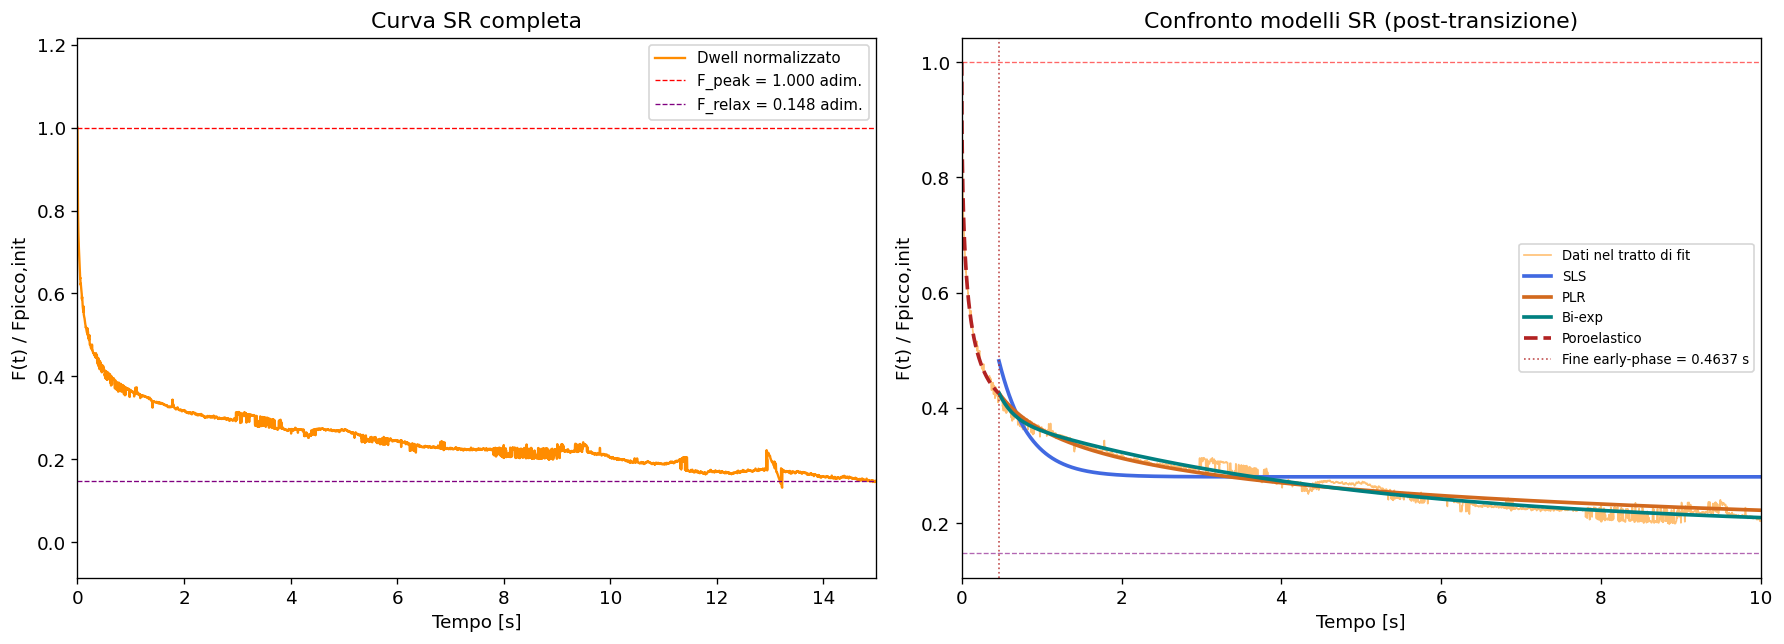

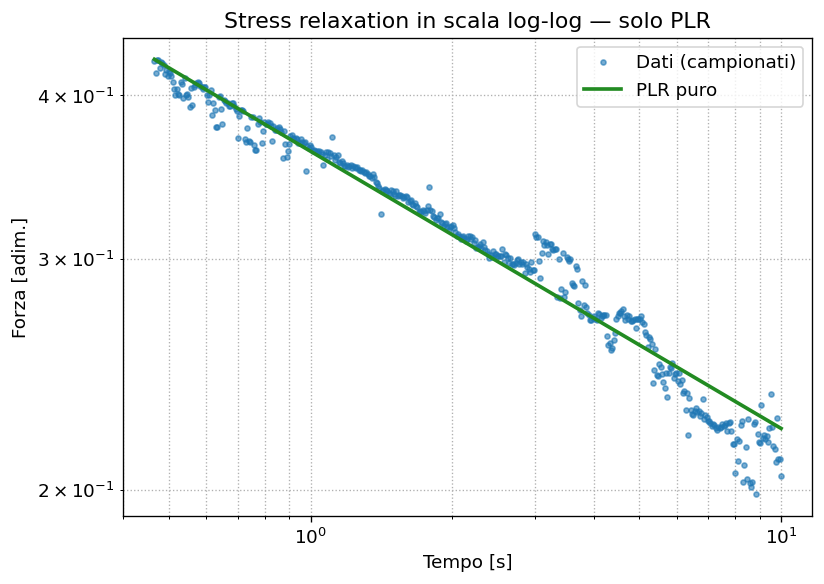

,candidate_t_s,late_model,late_r2,score
10,0.48750,bi,0.983156,0.008502
9,0.46375,plr,0.972687,0.006417


,dominio,modello,parametri,R2
0,early-phase (0-0.464s),Poroelastico,"F∞=0.3759, τp=0.0722 s",0.9902
1,post-transizione (t≥0.464s),Bi-exp GM,"F∞=0.1889, w=0.7366, τ1=0.1811 s, τ2=4.3266 s",0.9840
2,post-transizione (t≥0.464s),PLR puro,"t0=0.0082 s, β=0.2113",0.9727
3,post-transizione (t≥0.464s),SLS,"F∞=0.2807, τ=0.3652 s",0.6115


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


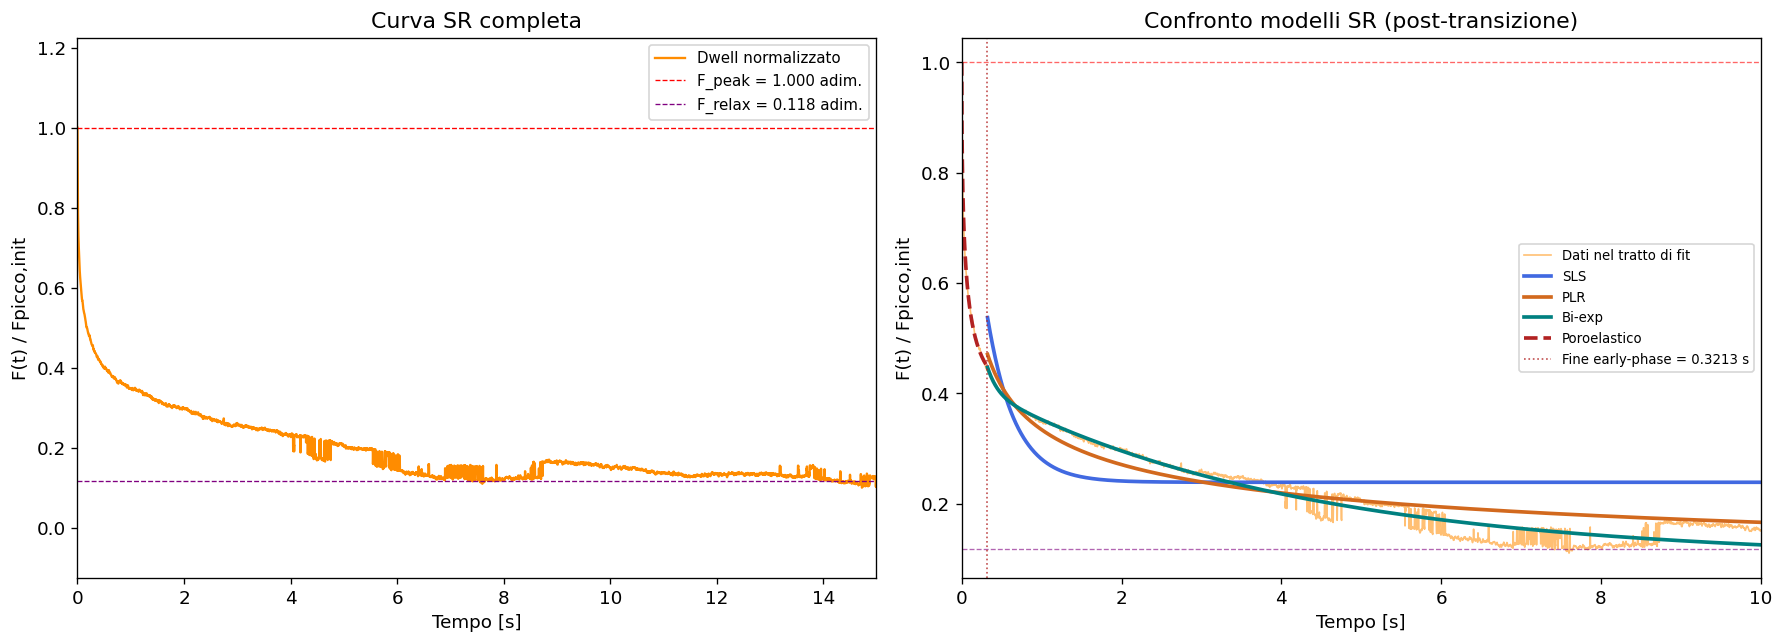

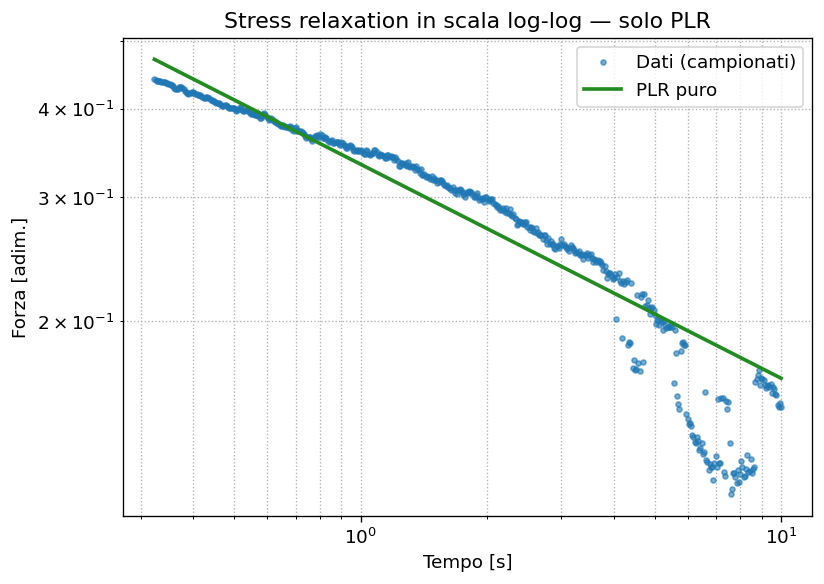

,candidate_t_s,late_model,late_r2,score
3,0.32125,bi,0.981133,0.005576
41,1.20000,plr,0.913875,0.020624


,dominio,modello,parametri,R2
0,early-phase (0-0.321s),Poroelastico,"F∞=0.3892, τp=0.0587 s",0.9870
1,post-transizione (t≥0.321s),Bi-exp GM,"F∞=0.0994, w=0.6388, τ1=0.1298 s, τ2=3.9543 s",0.9811
2,post-transizione (t≥0.321s),PLR puro,"t0=0.0268 s, β=0.3032",0.9290
3,post-transizione (t≥0.321s),SLS,"F∞=0.2387, τ=0.3449 s",0.5674


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


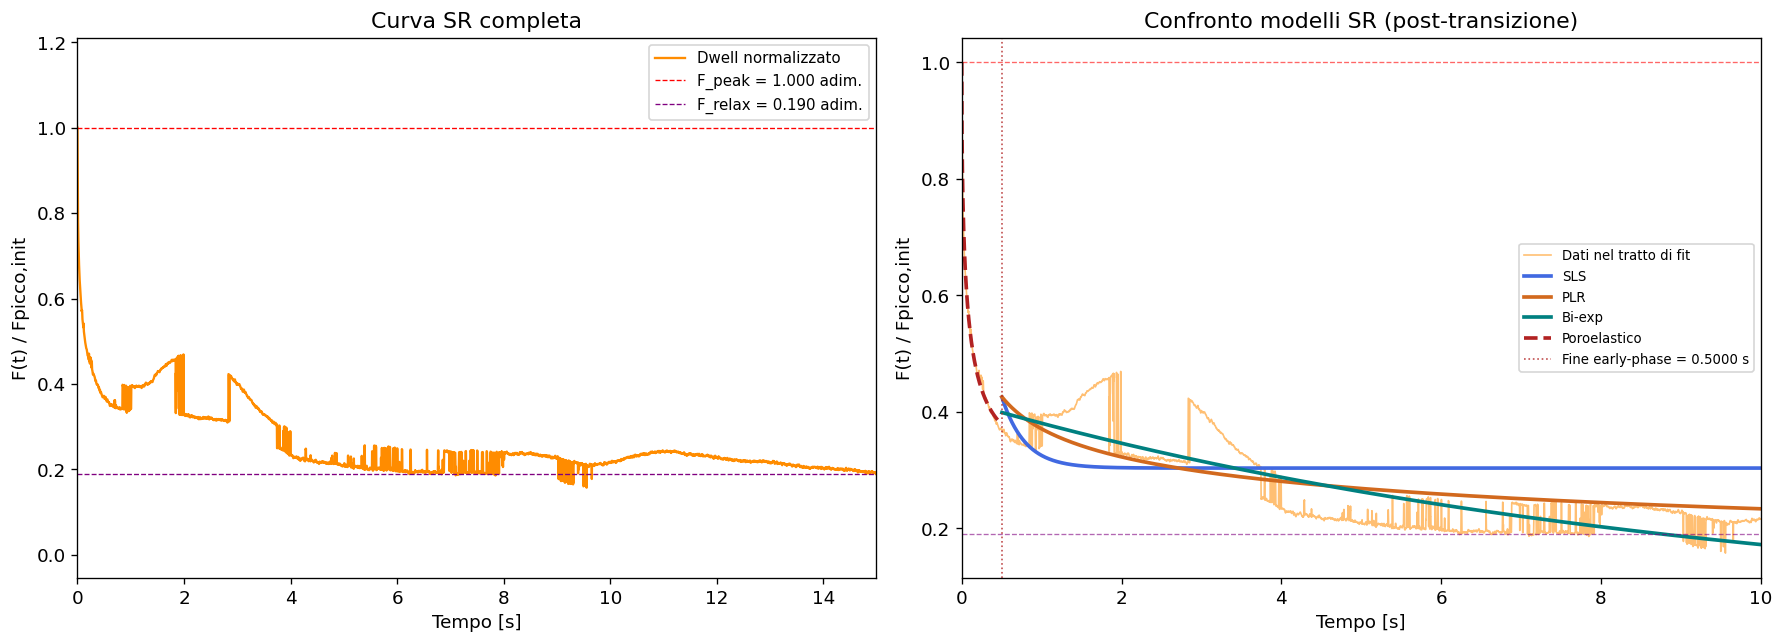

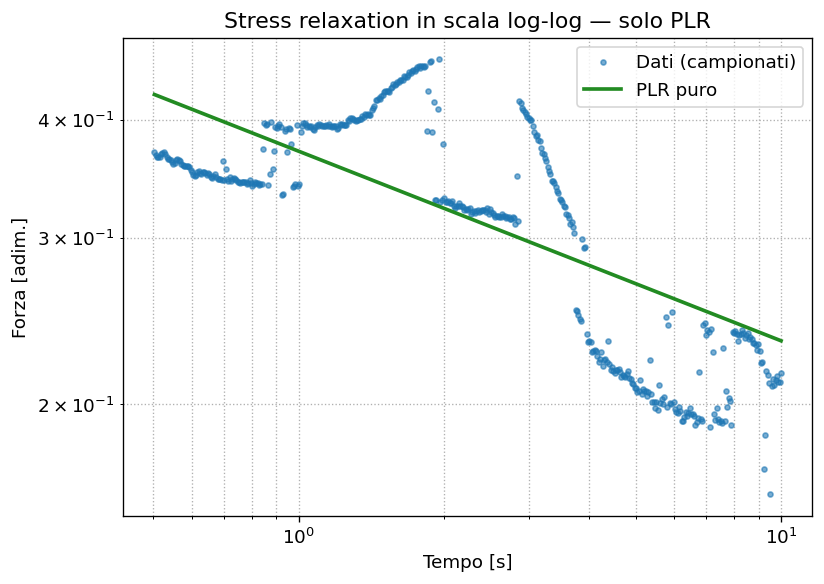

,candidate_t_s,late_model,late_r2,score
11,0.5,bi,0.684478,0.041951


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.3238, τp=0.0789 s",0.9902
1,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.0457, w=0.6095, τ1=0.0274 s, τ2=9.2405 s",0.6845
2,post-transizione (t≥0.500s),PLR puro,"t0=0.0071 s, β=0.2008",0.5247
3,post-transizione (t≥0.500s),SLS,"F∞=0.3033, τ=0.2880 s",0.0753


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


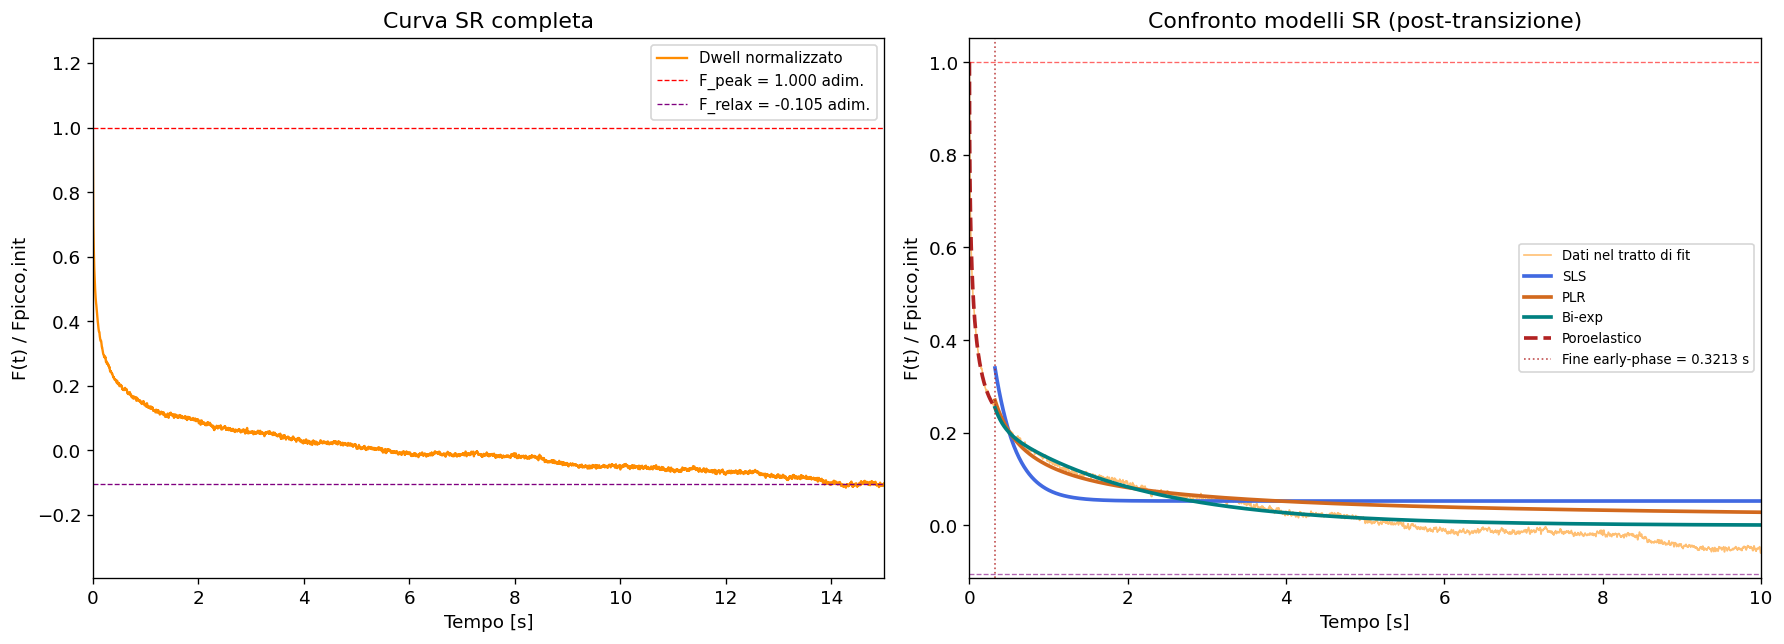

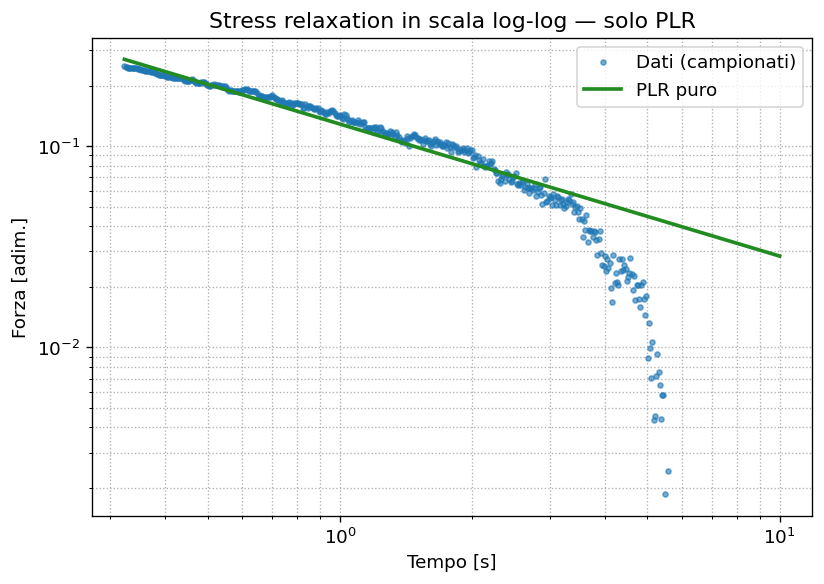

,candidate_t_s,late_model,late_r2,score
3,0.32125,bi,0.972817,0.002707
27,0.86750,plr,0.837934,0.022986


,dominio,modello,parametri,R2
0,early-phase (0-0.321s),Poroelastico,"F∞=0.1926, τp=0.0489 s",0.9881
1,post-transizione (t≥0.321s),Bi-exp GM,"F∞=0.0000, w=0.7458, τ1=0.1121 s, τ2=1.7893 s",0.9728
2,post-transizione (t≥0.321s),PLR puro,"t0=0.0440 s, β=0.6561",0.9571
3,post-transizione (t≥0.321s),SLS,"F∞=0.0527, τ=0.2708 s",0.6231


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


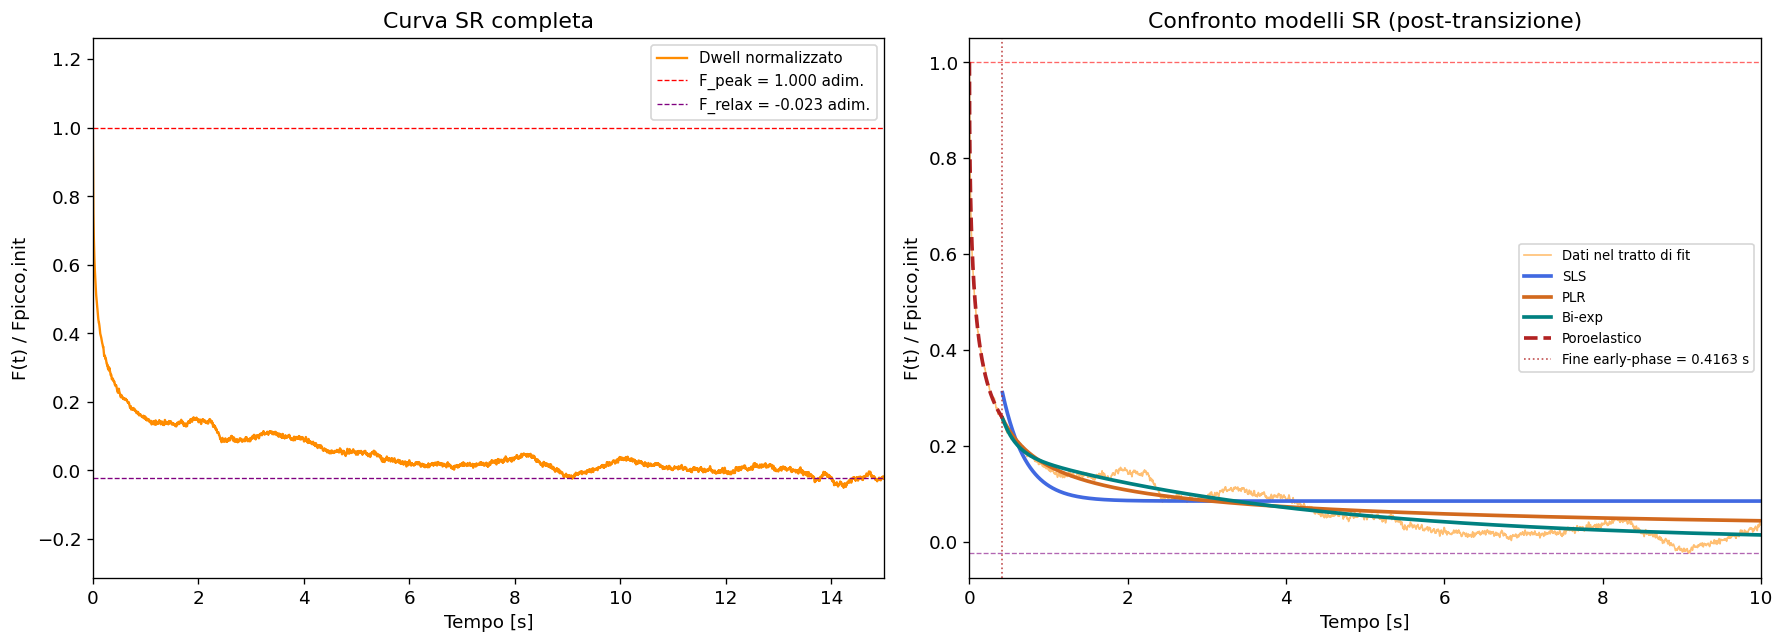

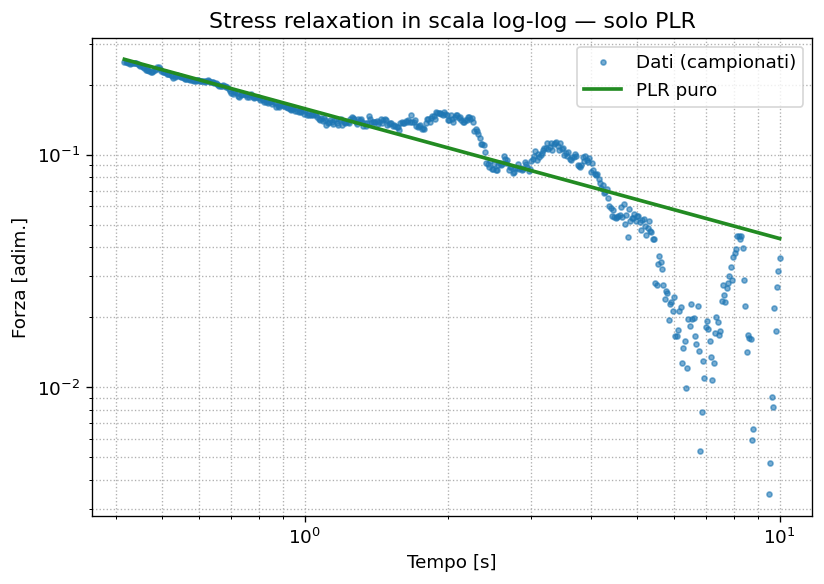

,candidate_t_s,late_model,late_r2,score
7,0.41625,bi,0.959366,0.004440
8,0.44000,plr,0.892866,0.008363


,dominio,modello,parametri,R2
0,early-phase (0-0.416s),Poroelastico,"F∞=0.1669, τp=0.0855 s",0.9903
1,post-transizione (t≥0.416s),Bi-exp GM,"F∞=0.0000, w=0.7905, τ1=0.1723 s, τ2=3.7070 s",0.9594
2,post-transizione (t≥0.416s),PLR puro,"t0=0.0369 s, β=0.5590",0.9069
3,post-transizione (t≥0.416s),SLS,"F∞=0.0847, τ=0.2985 s",0.5999


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


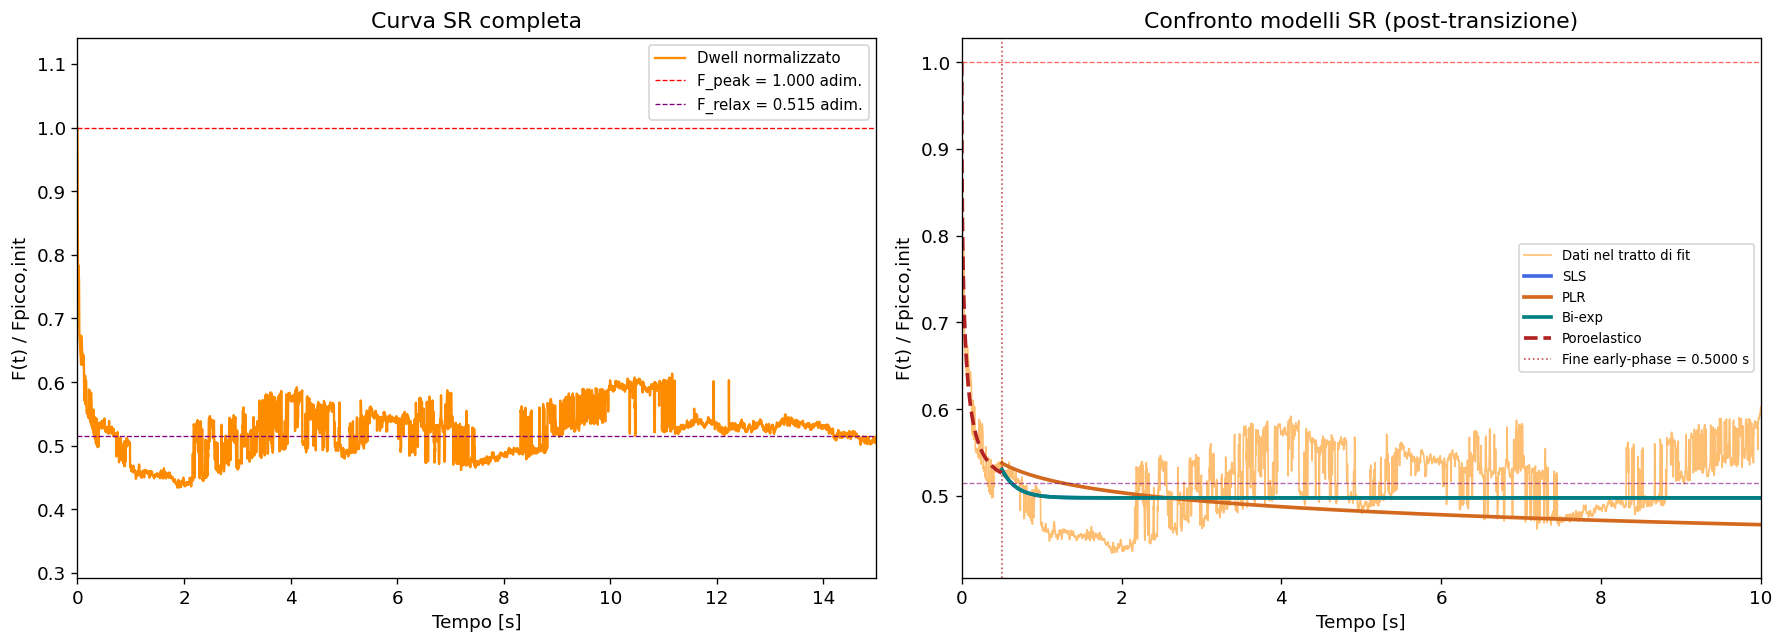

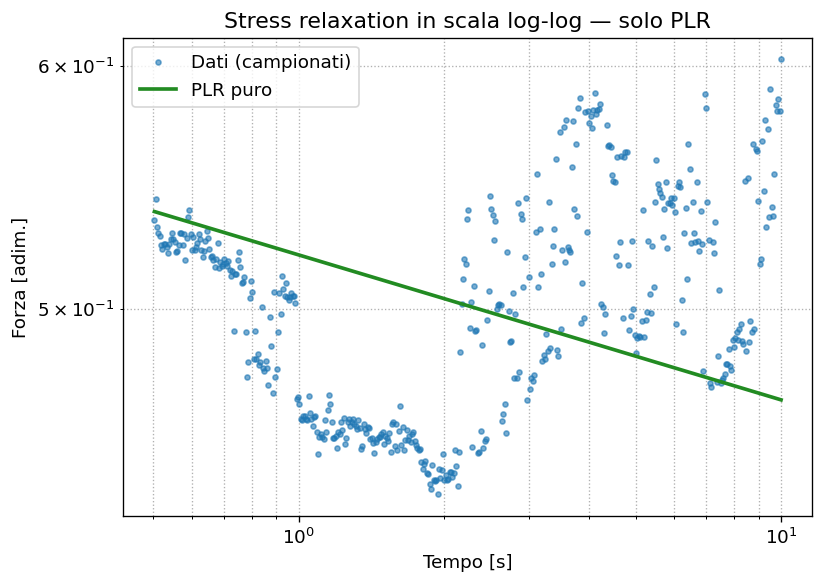

,candidate_t_s,late_model,late_r2,score
11,0.5,bi,0.037414,0.010062


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.5129, τp=0.0390 s",0.9498
1,post-transizione (t≥0.500s),SLS,"F∞=0.4978, τ=0.1837 s",0.0374
2,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.4978, w=0.0626, τ1=0.1837 s, τ2=0.1837 s",0.0374
3,post-transizione (t≥0.500s),PLR puro,"t0=0.0000 s, β=0.0473",-0.5952


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


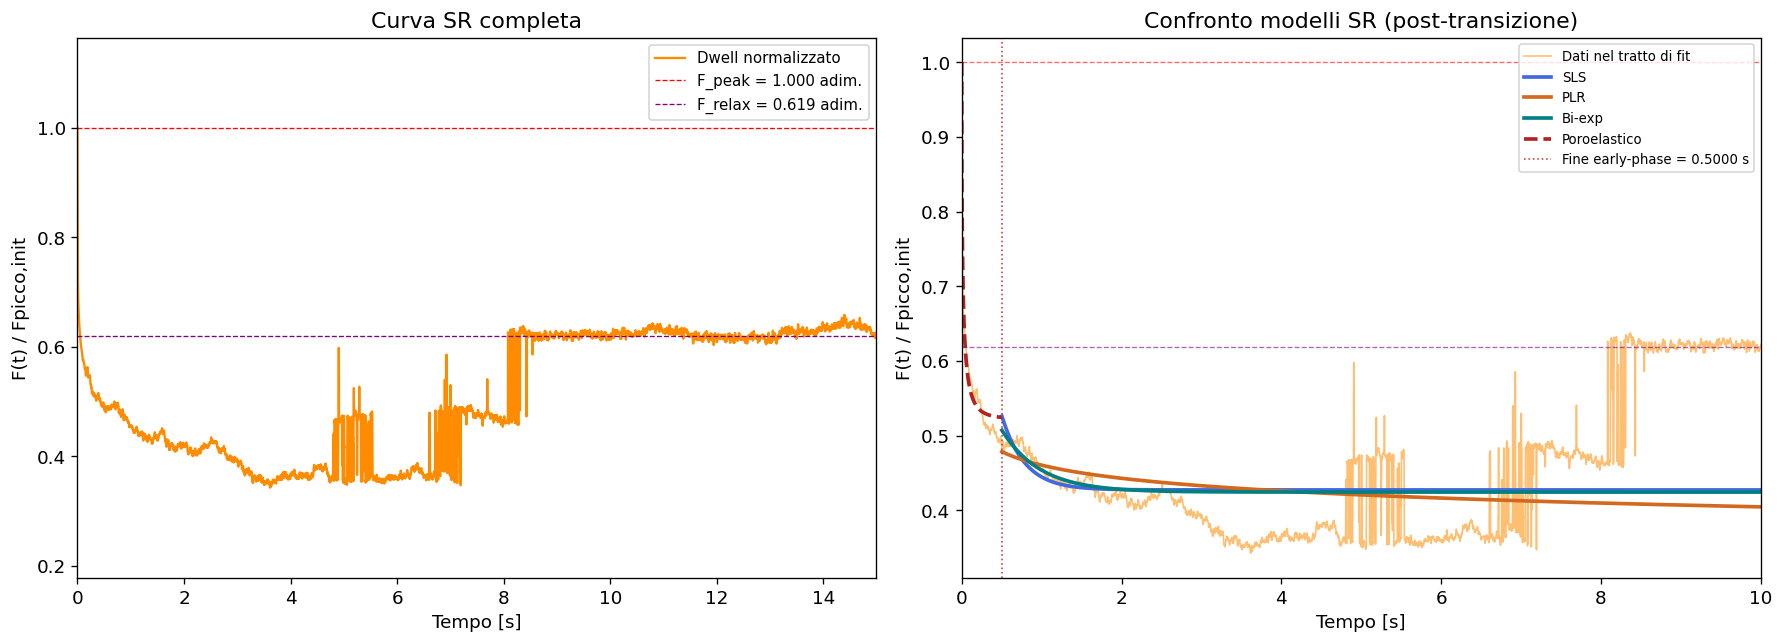

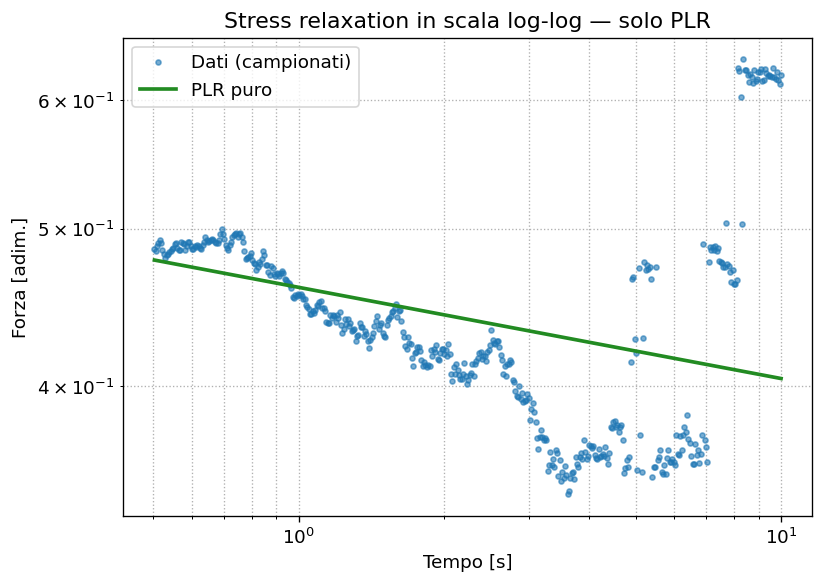

,candidate_t_s,late_model,late_r2,score
11,0.5,mono,0.111812,0.034801


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.5222, τp=0.0167 s",0.9547
1,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.4243, w=0.5890, τ1=0.0093 s, τ2=0.4790 s",0.1231
2,post-transizione (t≥0.500s),SLS,"F∞=0.4272, τ=0.2859 s",0.1118
3,post-transizione (t≥0.500s),PLR puro,"t0=0.0000 s, β=0.0562",-0.0369


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


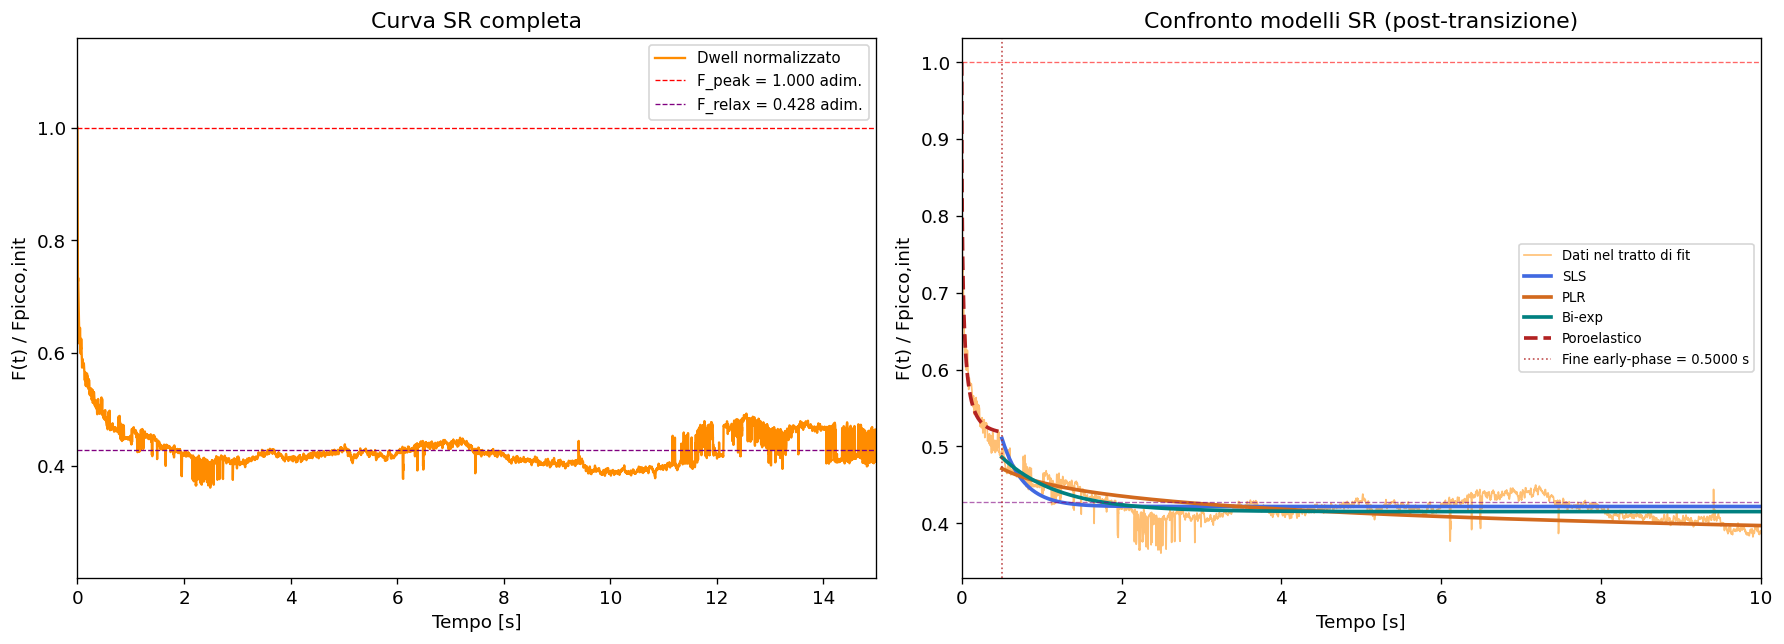

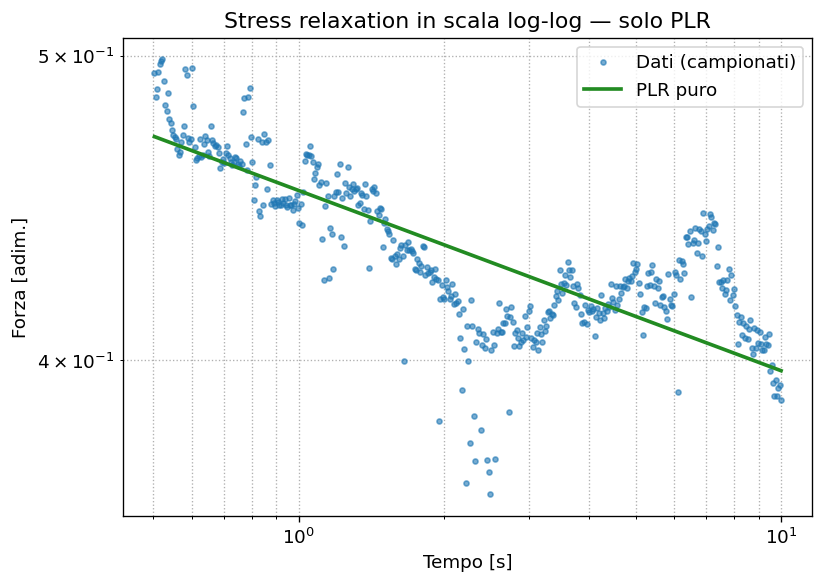

,candidate_t_s,late_model,late_r2,score
11,0.5,mono,0.587669,0.02908


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.5149, τp=0.0212 s",0.9633
1,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.4151, w=0.7577, τ1=0.0576 s, τ2=0.7219 s",0.7365
2,post-transizione (t≥0.500s),SLS,"F∞=0.4217, τ=0.2680 s",0.5877
3,post-transizione (t≥0.500s),PLR puro,"t0=0.0000 s, β=0.0573",0.5740


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


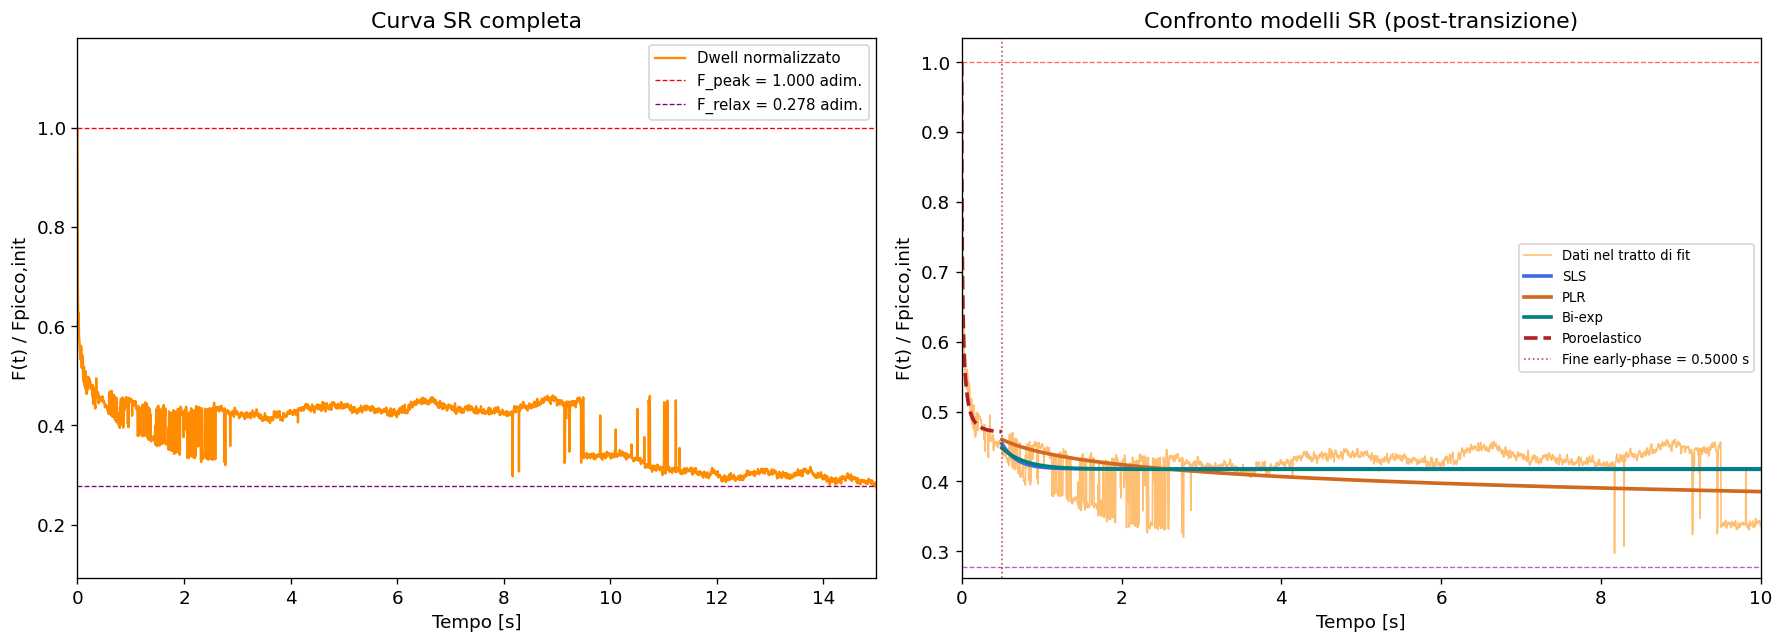

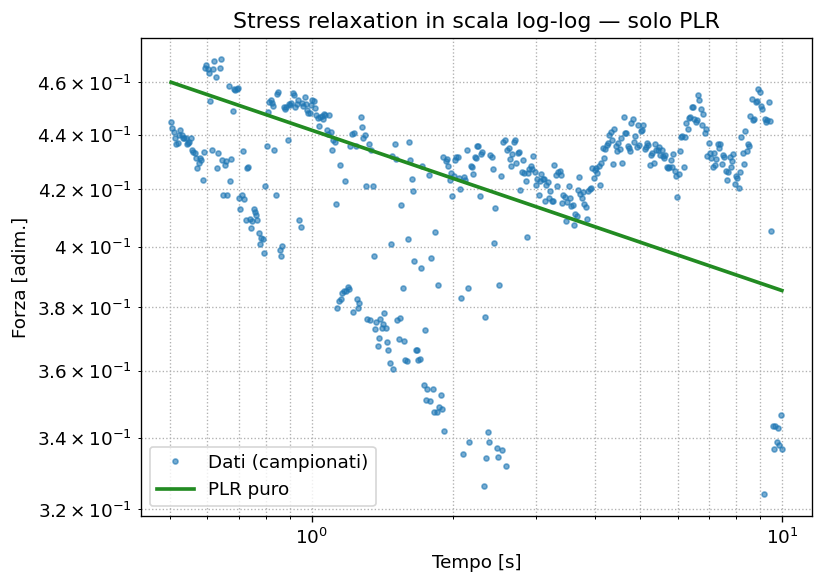

,candidate_t_s,late_model,late_r2,score
11,0.5,bi,0.056329,0.031498


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.4702, τp=0.0128 s",0.9461
1,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.4173, w=0.7005, τ1=0.0155 s, τ2=0.2887 s",0.0636
2,post-transizione (t≥0.500s),SLS,"F∞=0.4180, τ=0.1809 s",0.0563
3,post-transizione (t≥0.500s),PLR puro,"t0=0.0000 s, β=0.0592",-0.4747


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


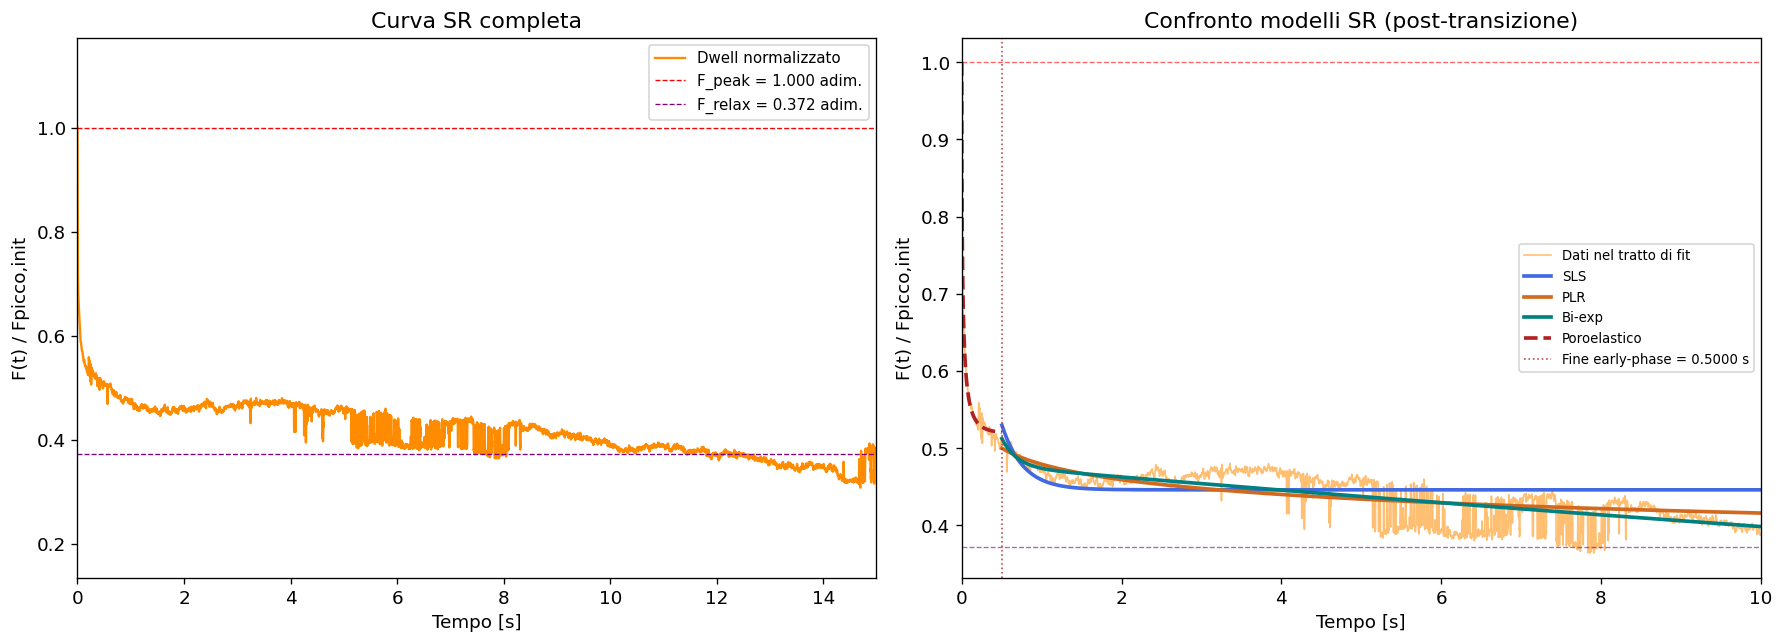

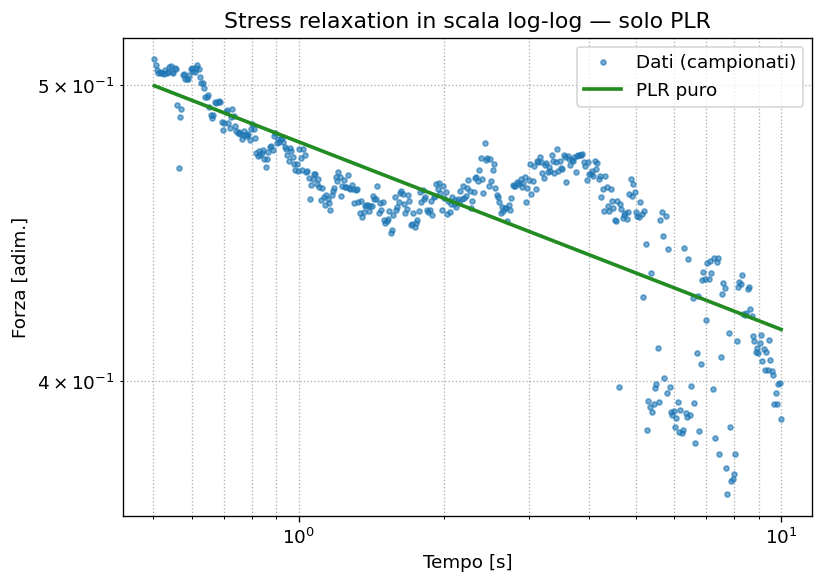

,candidate_t_s,late_model,late_r2,score
11,0.5,bi,0.723484,0.016827


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.5188, τp=0.0158 s",0.9689
1,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.0000, w=0.5198, τ1=0.1897 s, τ2=53.6082 s",0.7235
2,post-transizione (t≥0.500s),PLR puro,"t0=0.0000 s, β=0.0615",0.6422
3,post-transizione (t≥0.500s),SLS,"F∞=0.4460, τ=0.2660 s",0.3780


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


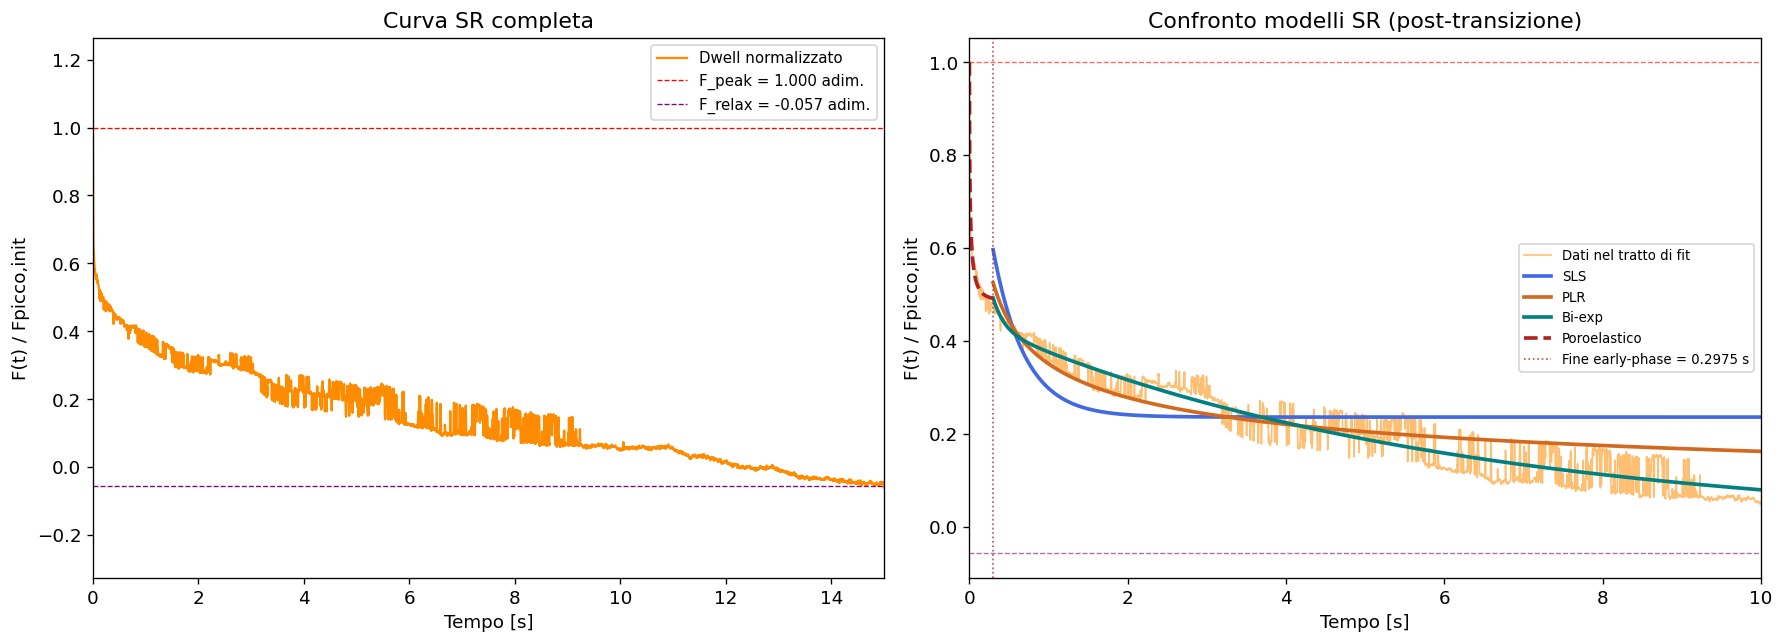

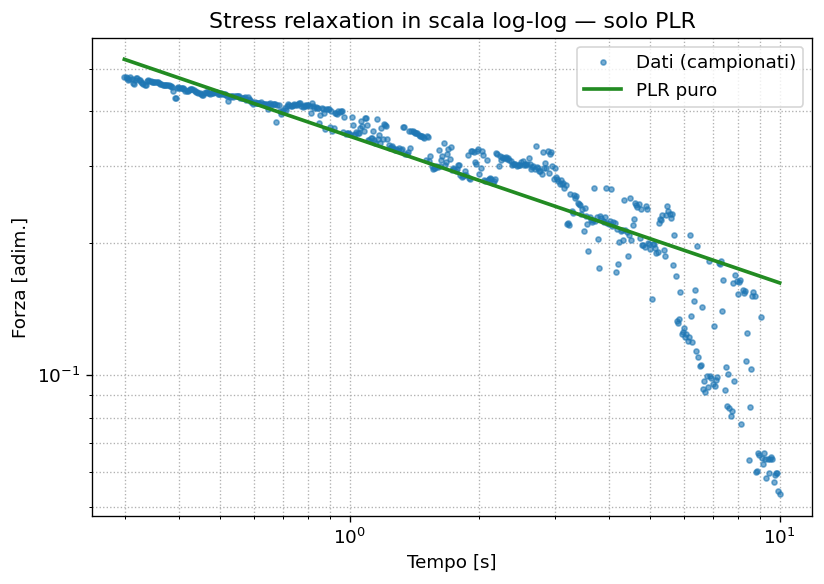

,candidate_t_s,late_model,late_r2,score
2,0.2975,bi,0.956077,0.016337


,dominio,modello,parametri,R2
0,early-phase (0-0.297s),Poroelastico,"F∞=0.4873, τp=0.0132 s",0.9480
1,post-transizione (t≥0.297s),Bi-exp GM,"F∞=0.0000, w=0.5537, τ1=0.1432 s, τ2=5.7979 s",0.9561
2,post-transizione (t≥0.297s),PLR puro,"t0=0.0437 s, β=0.3347",0.8788
3,post-transizione (t≥0.297s),SLS,"F∞=0.2361, τ=0.3981 s",0.5654


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


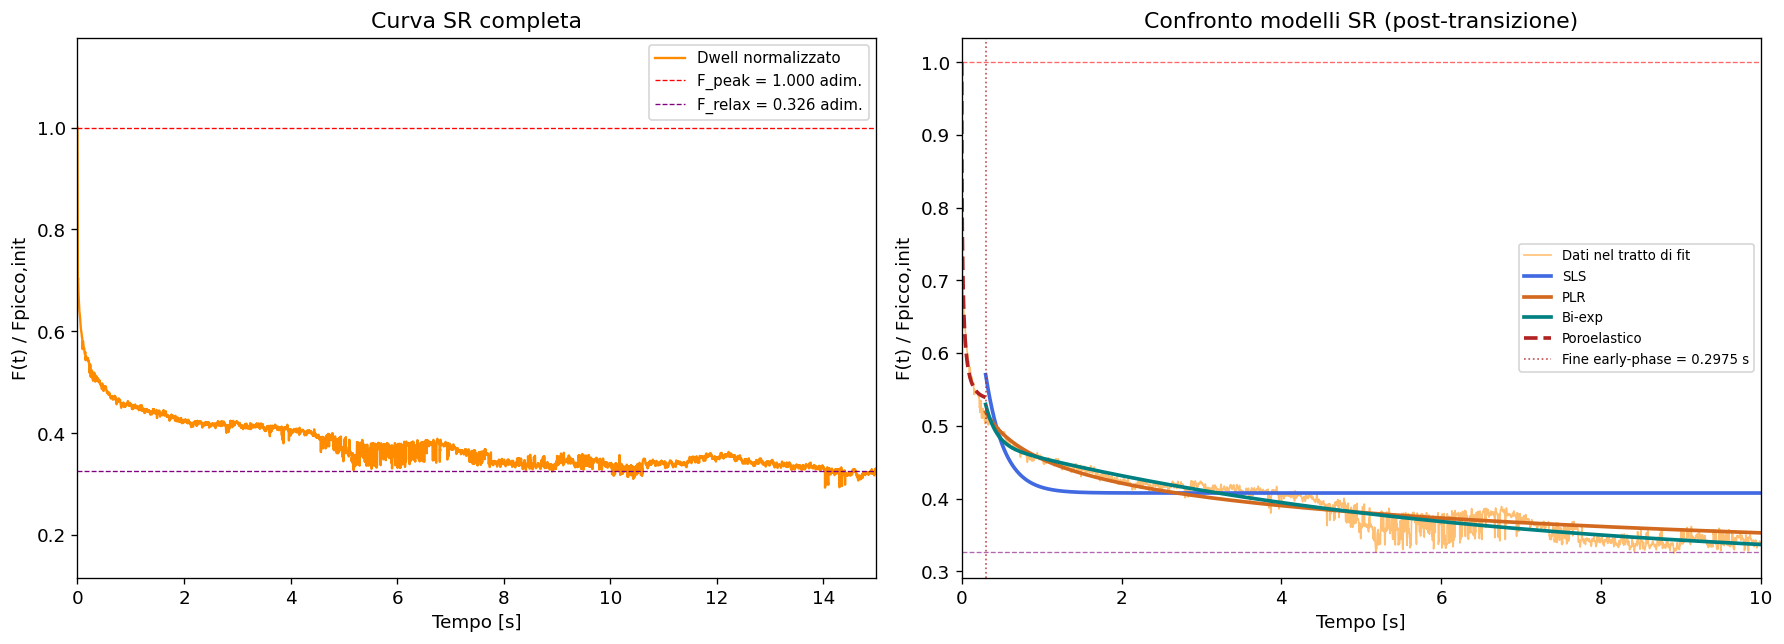

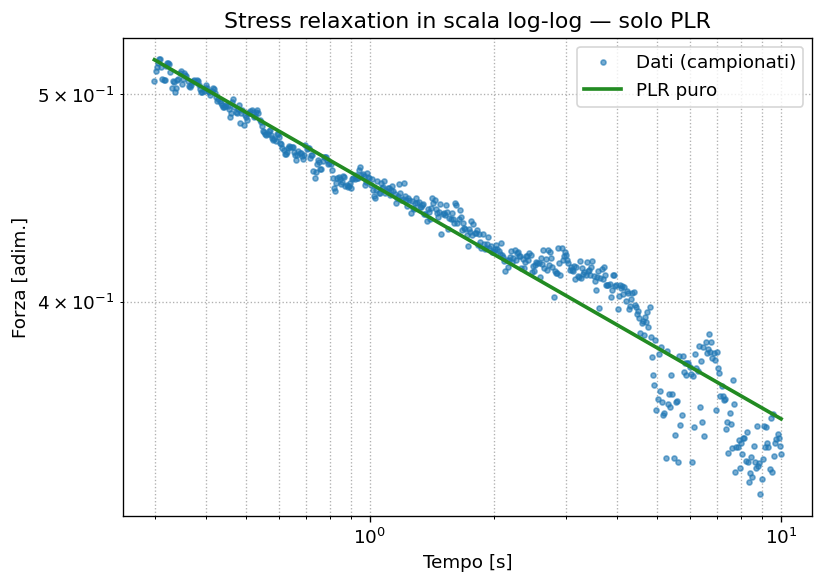

,candidate_t_s,late_model,late_r2,score
2,0.2975,bi,0.968528,0.027724


,dominio,modello,parametri,R2
0,early-phase (0-0.297s),Poroelastico,"F∞=0.5340, τp=0.0146 s",0.9507
1,post-transizione (t≥0.297s),Bi-exp GM,"F∞=0.3053, w=0.7432, τ1=0.1334 s, τ2=5.7720 s",0.9685
2,post-transizione (t≥0.297s),PLR puro,"t0=0.0008 s, β=0.1099",0.9547
3,post-transizione (t≥0.297s),SLS,"F∞=0.4076, τ=0.2317 s",0.5394


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


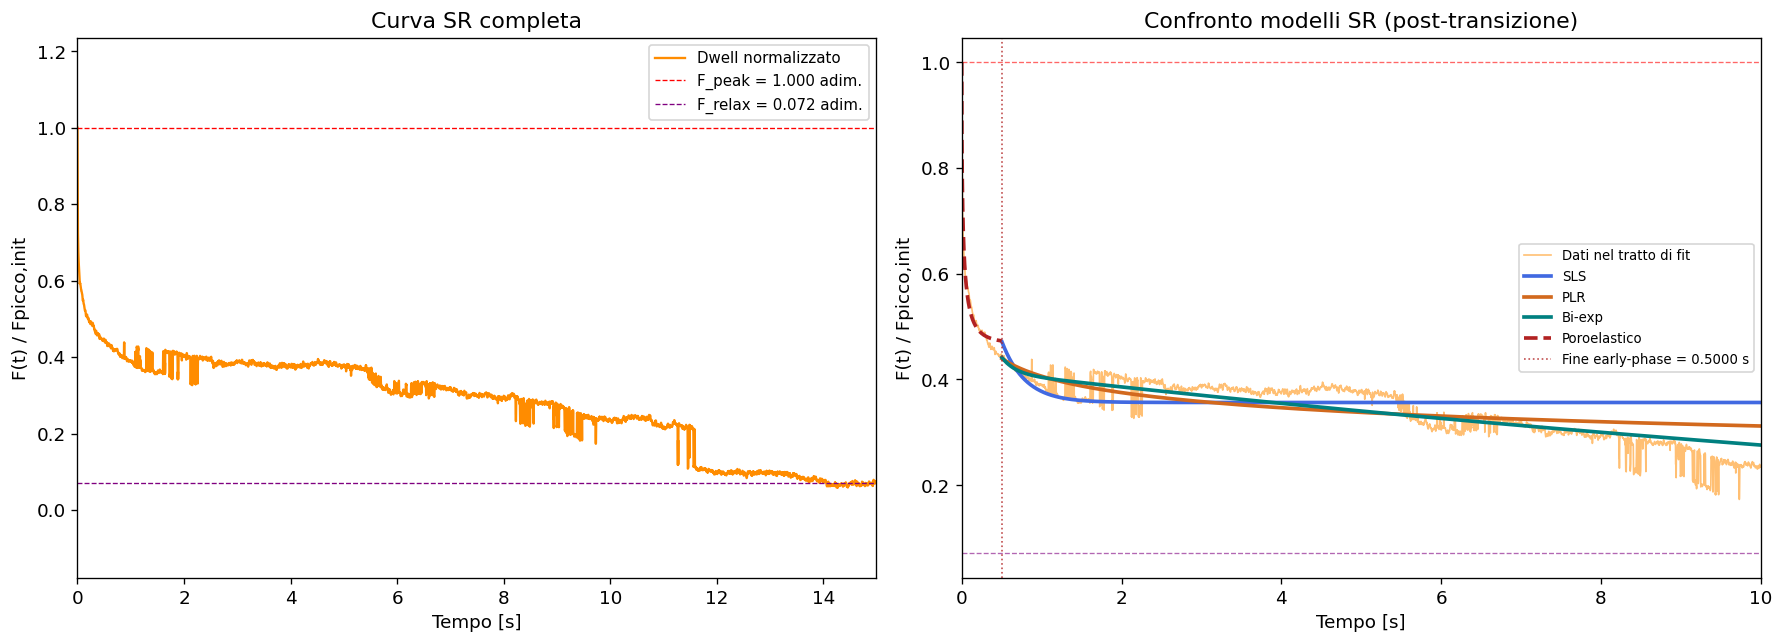

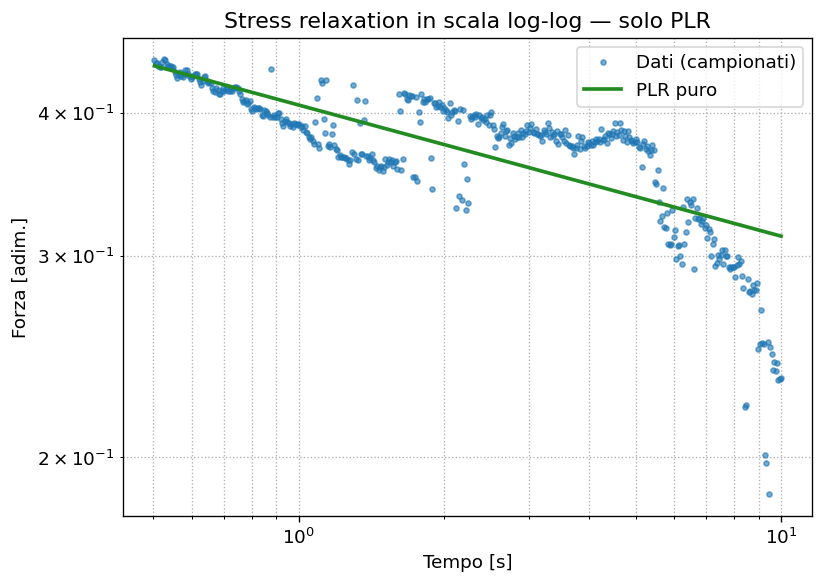

,candidate_t_s,late_model,late_r2,score
11,0.5,mono,0.305207,0.025727


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.4682, τp=0.0224 s",0.9693
1,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.0000, w=0.5804, τ1=0.1713 s, τ2=23.8731 s",0.7682
2,post-transizione (t≥0.500s),PLR puro,"t0=0.0004 s, β=0.1145",0.6175
3,post-transizione (t≥0.500s),SLS,"F∞=0.3565, τ=0.2917 s",0.3052


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


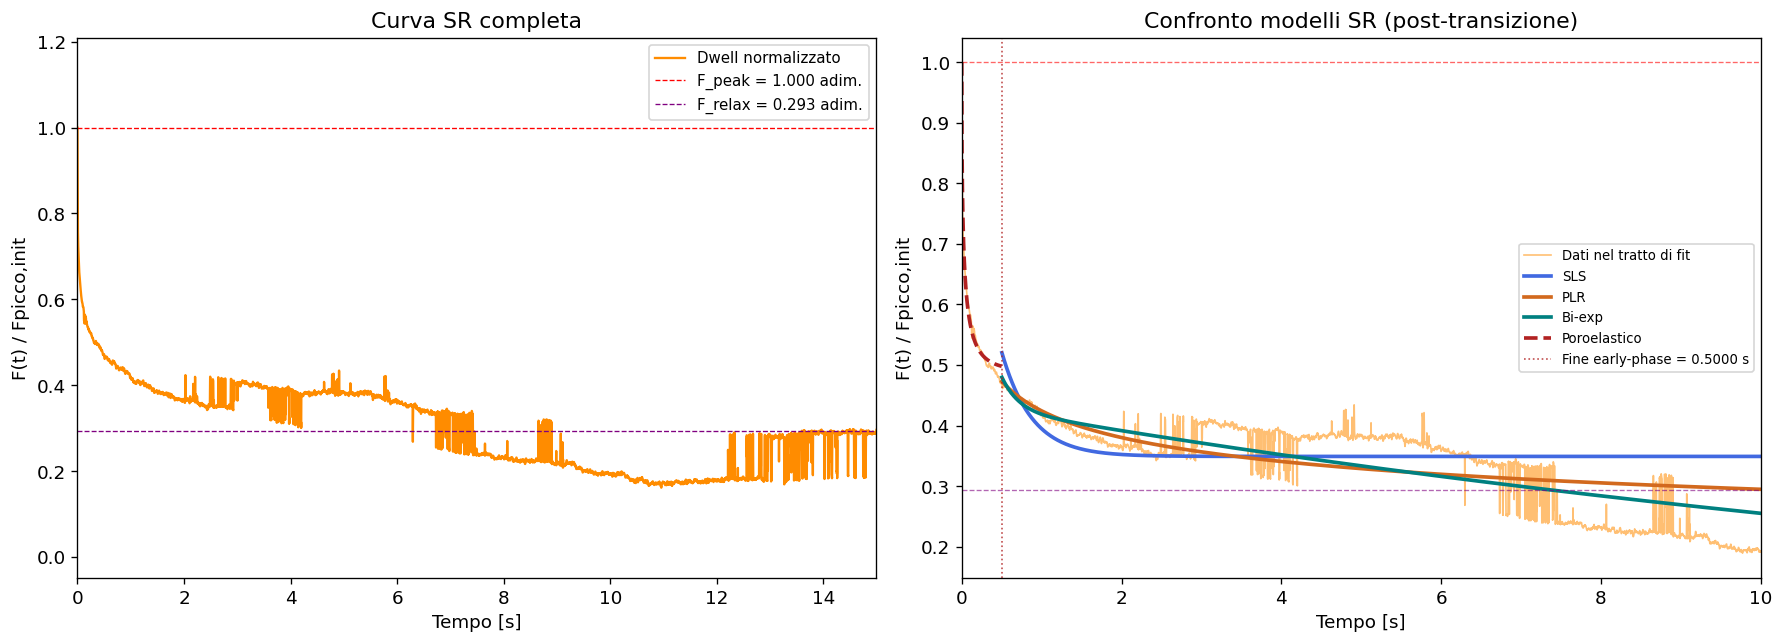

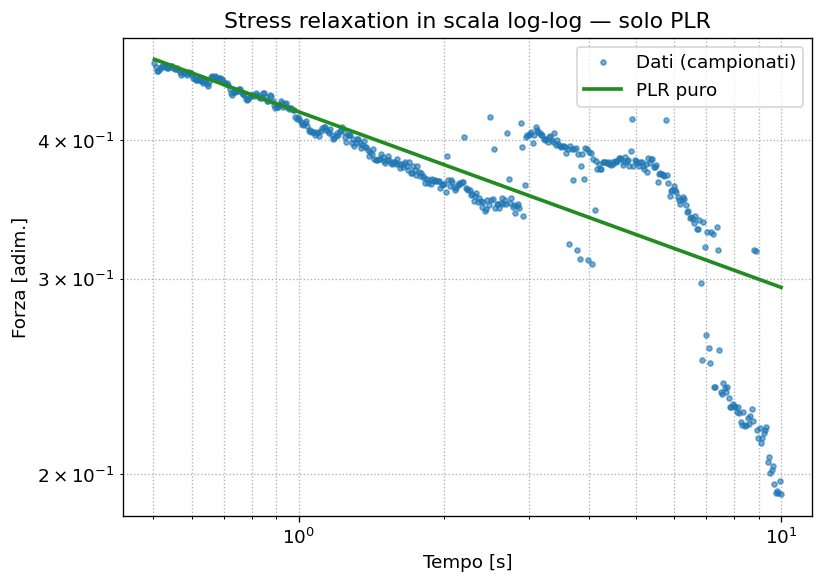

,candidate_t_s,late_model,late_r2,score
11,0.5,bi,0.760935,0.034144


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.4893, τp=0.0300 s",0.9780
1,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.0000, w=0.5642, τ1=0.2167 s, τ2=18.6816 s",0.7609
2,post-transizione (t≥0.500s),PLR puro,"t0=0.0044 s, β=0.1581",0.6625
3,post-transizione (t≥0.500s),SLS,"F∞=0.3491, τ=0.3763 s",0.4042


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


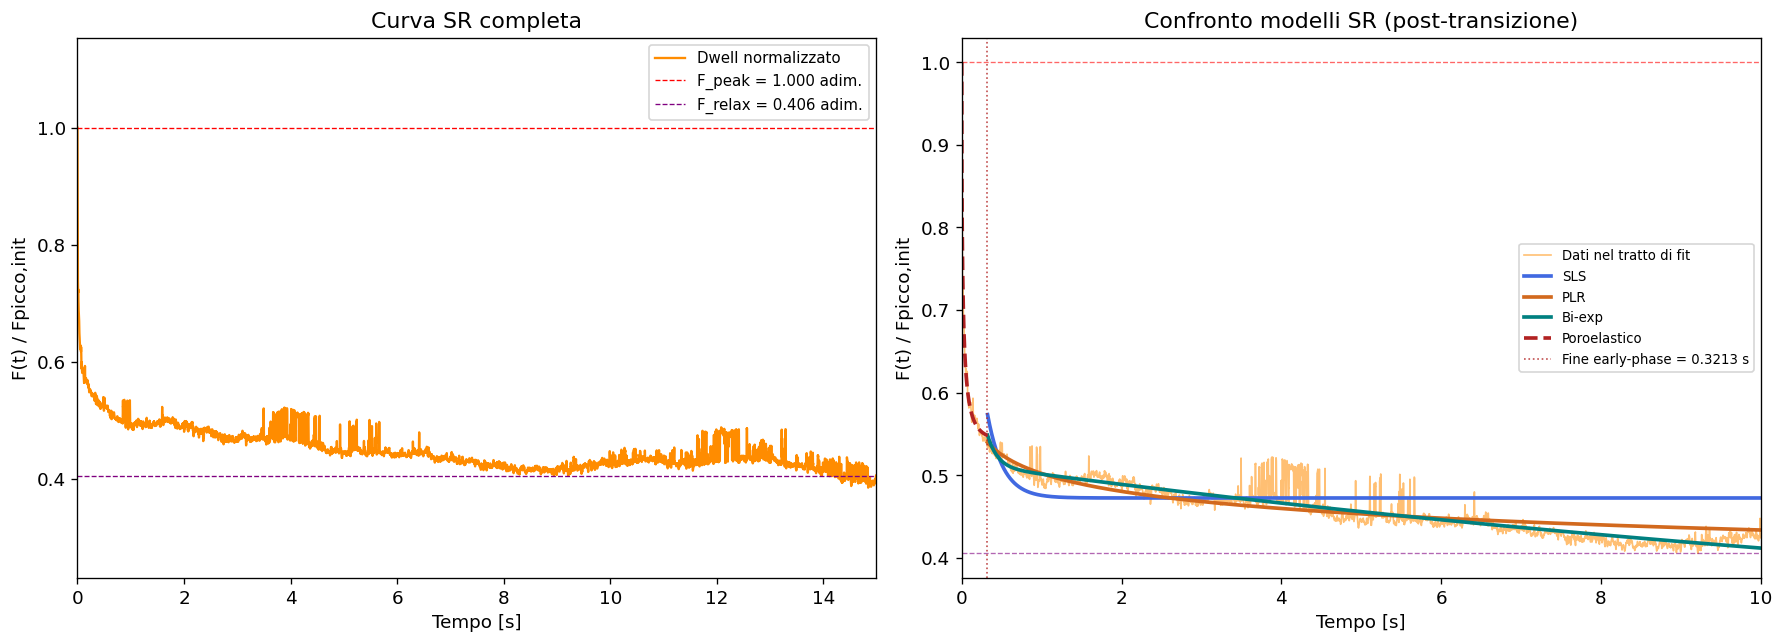

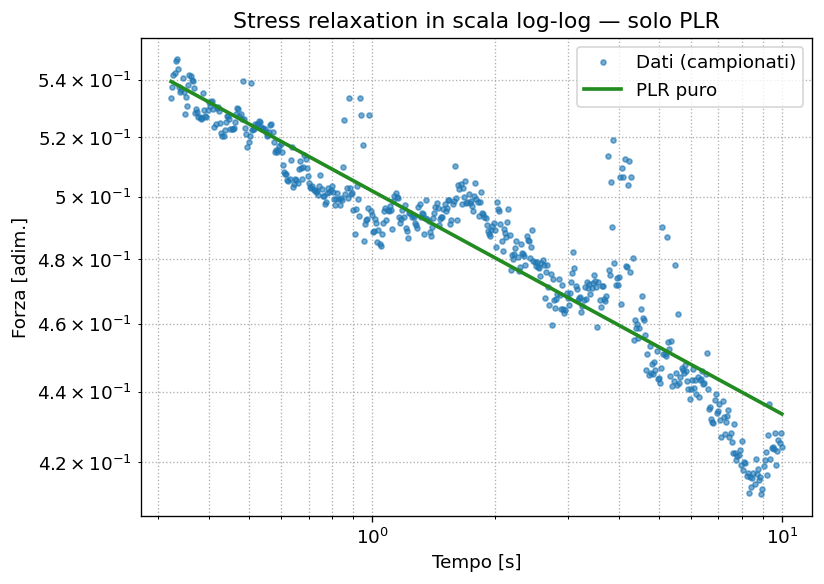

,candidate_t_s,late_model,late_r2,score
3,0.32125,bi,0.912253,0.008279


,dominio,modello,parametri,R2
0,early-phase (0-0.321s),Poroelastico,"F∞=0.5414, τp=0.0178 s",0.9678
1,post-transizione (t≥0.321s),Bi-exp GM,"F∞=0.2751, w=0.6704, τ1=0.1275 s, τ2=17.8746 s",0.9123
2,post-transizione (t≥0.321s),PLR puro,"t0=0.0000 s, β=0.0636",0.8660
3,post-transizione (t≥0.321s),SLS,"F∞=0.4723, τ=0.1954 s",0.4204


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


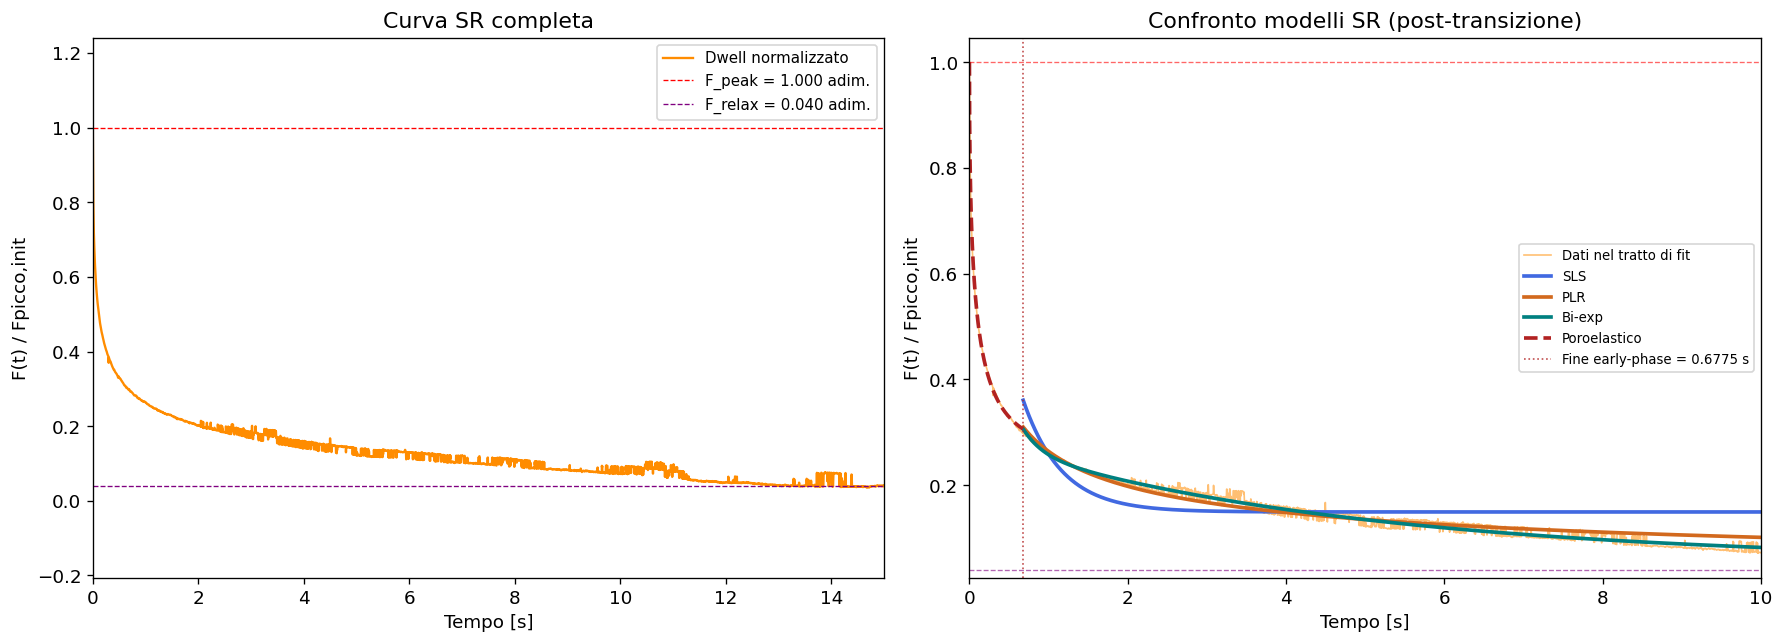

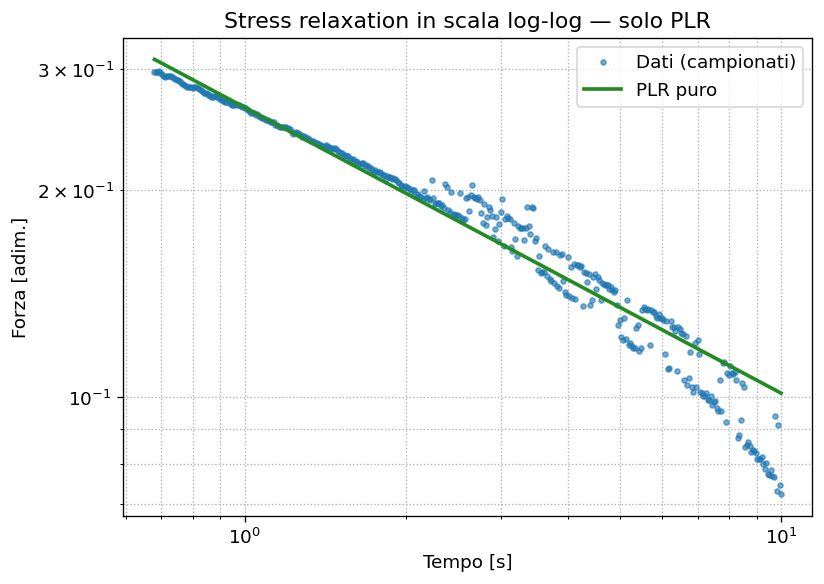

,candidate_t_s,late_model,late_r2,score
19,0.6775,bi,0.987512,0.006796
25,0.8200,plr,0.965964,0.010035


,dominio,modello,parametri,R2
0,early-phase (0-0.677s),Poroelastico,"F∞=0.2569, τp=0.0920 s",0.9936
1,post-transizione (t≥0.677s),Bi-exp GM,"F∞=0.0551, w=0.7522, τ1=0.2537 s, τ2=4.6435 s",0.9875
2,post-transizione (t≥0.677s),PLR puro,"t0=0.0406 s, β=0.4156",0.9707
3,post-transizione (t≥0.677s),SLS,"F∞=0.1494, τ=0.4878 s",0.6771


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


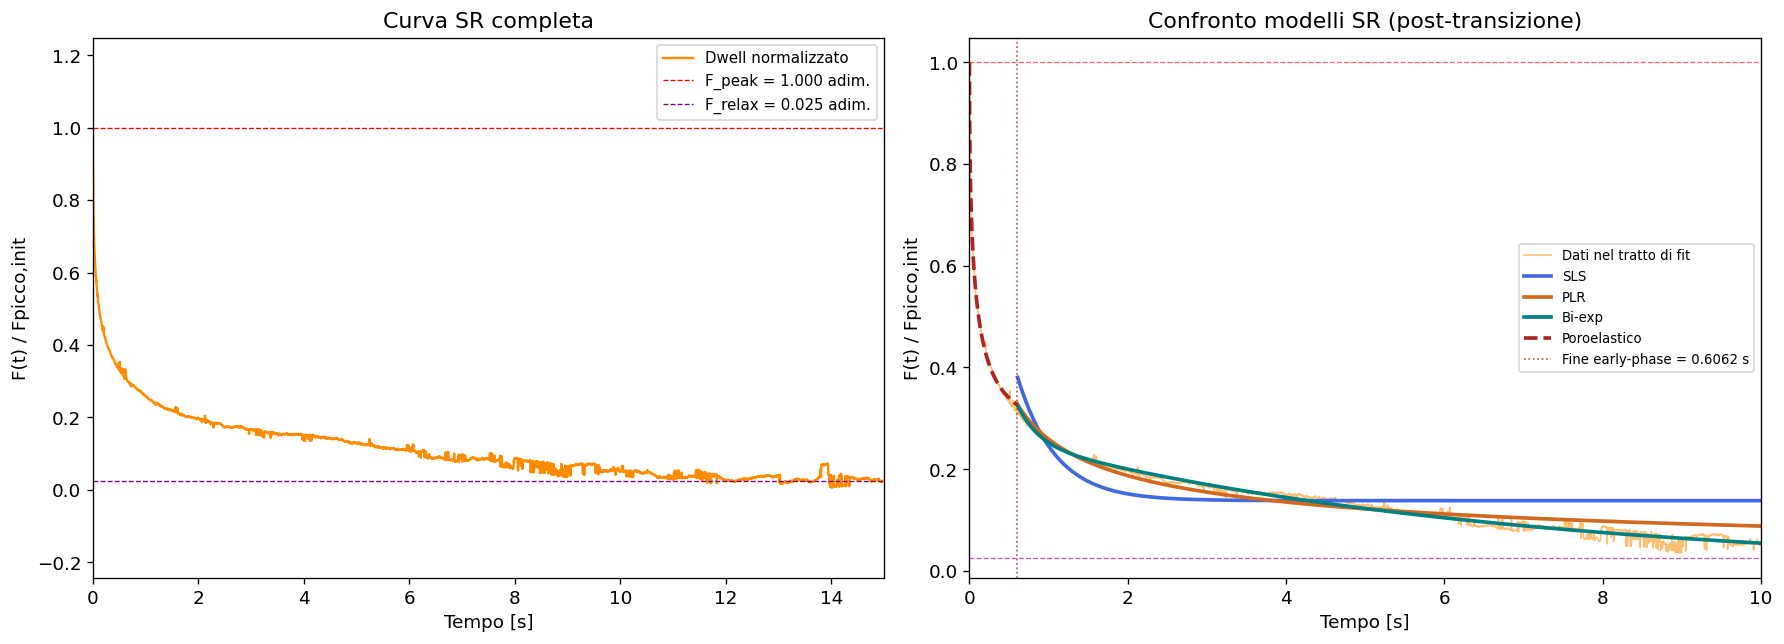

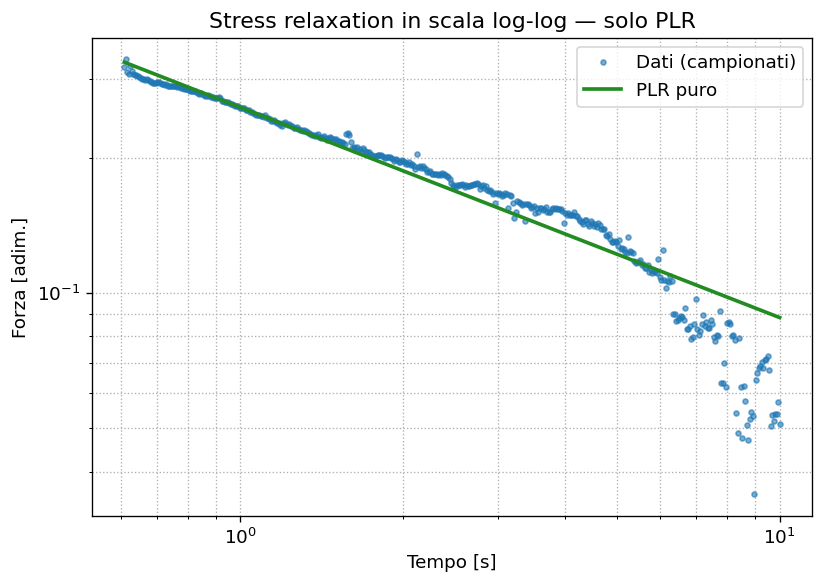

,candidate_t_s,late_model,late_r2,score
16,0.60625,bi,0.990912,0.010187
17,0.63000,plr,0.961000,0.014062


,dominio,modello,parametri,R2
0,early-phase (0-0.606s),Poroelastico,"F∞=0.2778, τp=0.0832 s",0.9921
1,post-transizione (t≥0.606s),Bi-exp GM,"F∞=0.0000, w=0.7239, τ1=0.2683 s, τ2=6.1680 s",0.9909
2,post-transizione (t≥0.606s),PLR puro,"t0=0.0558 s, β=0.4681",0.9627
3,post-transizione (t≥0.606s),SLS,"F∞=0.1381, τ=0.4800 s",0.6899


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


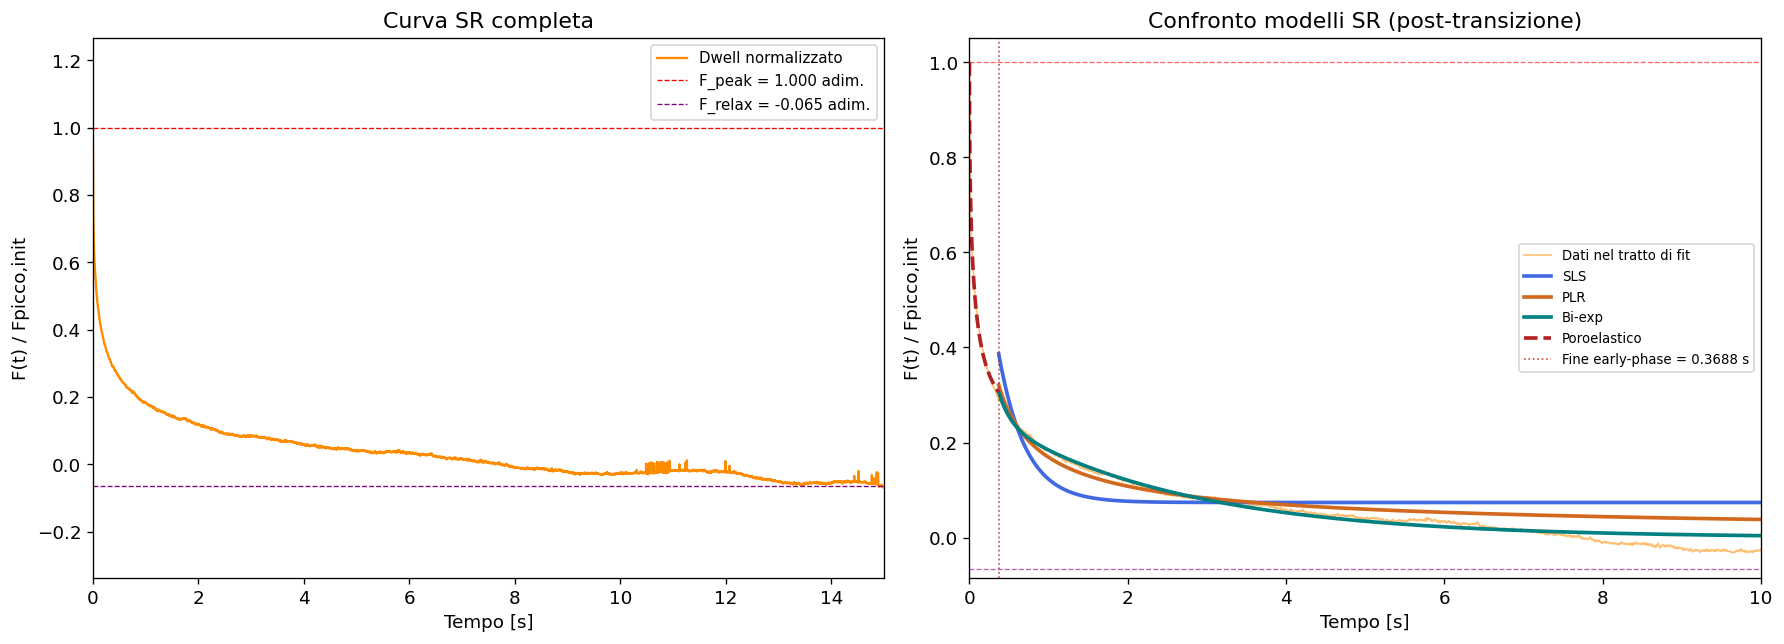

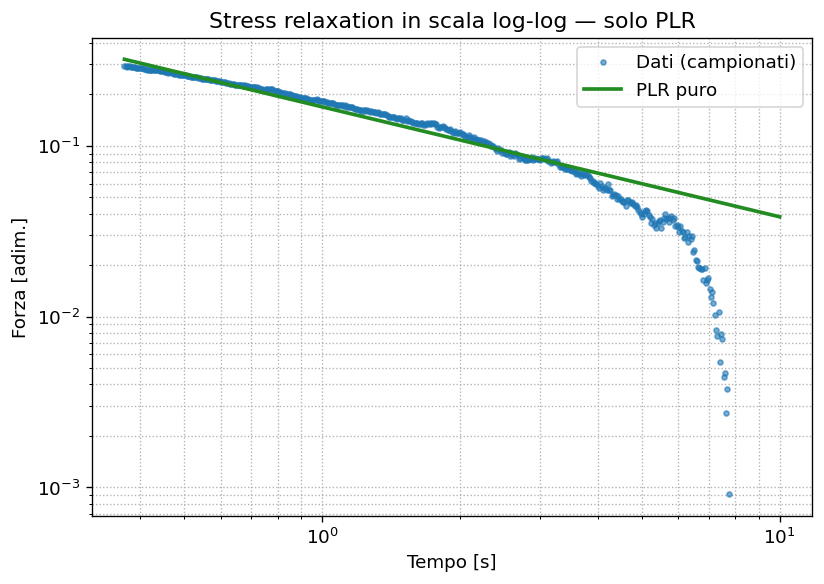

,candidate_t_s,late_model,late_r2,score
5,0.36875,bi,0.989247,0.011031
23,0.77250,plr,0.918547,0.021500


,dominio,modello,parametri,R2
0,early-phase (0-0.369s),Poroelastico,"F∞=0.2373, τp=0.0640 s",0.9891
1,post-transizione (t≥0.369s),Bi-exp GM,"F∞=0.0000, w=0.7224, τ1=0.1565 s, τ2=2.4040 s",0.9892
2,post-transizione (t≥0.369s),PLR puro,"t0=0.0634 s, β=0.6442",0.9675
3,post-transizione (t≥0.369s),SLS,"F∞=0.0741, τ=0.3404 s",0.6931


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


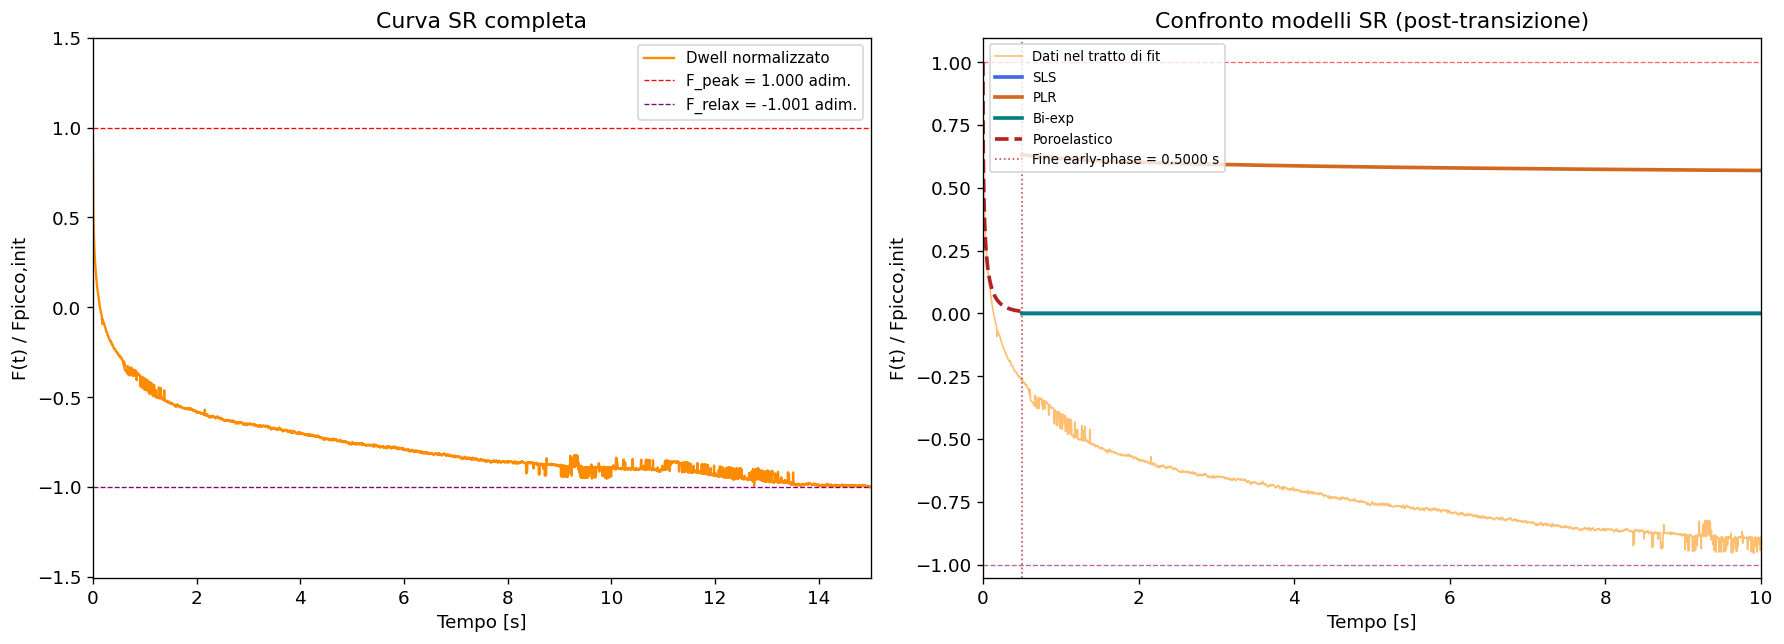

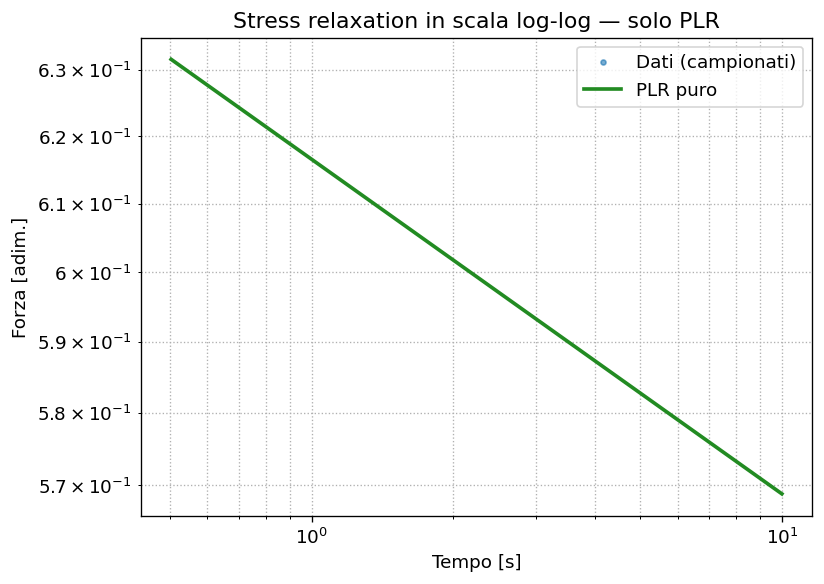

,candidate_t_s,late_model,late_r2,score
11,0.5,bi,-10.813837,0.27757


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.0000, τp=0.0213 s",0.8787
1,post-transizione (t≥0.500s),PLR puro,"t0=0.0000 s, β=0.0350",-0.2113
2,post-transizione (t≥0.500s),SLS,"F∞=0.0000, τ=0.0001 s",-10.8138
3,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.0000, w=0.9987, τ1=0.0031 s, τ2=0.0050 s",-10.8138


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


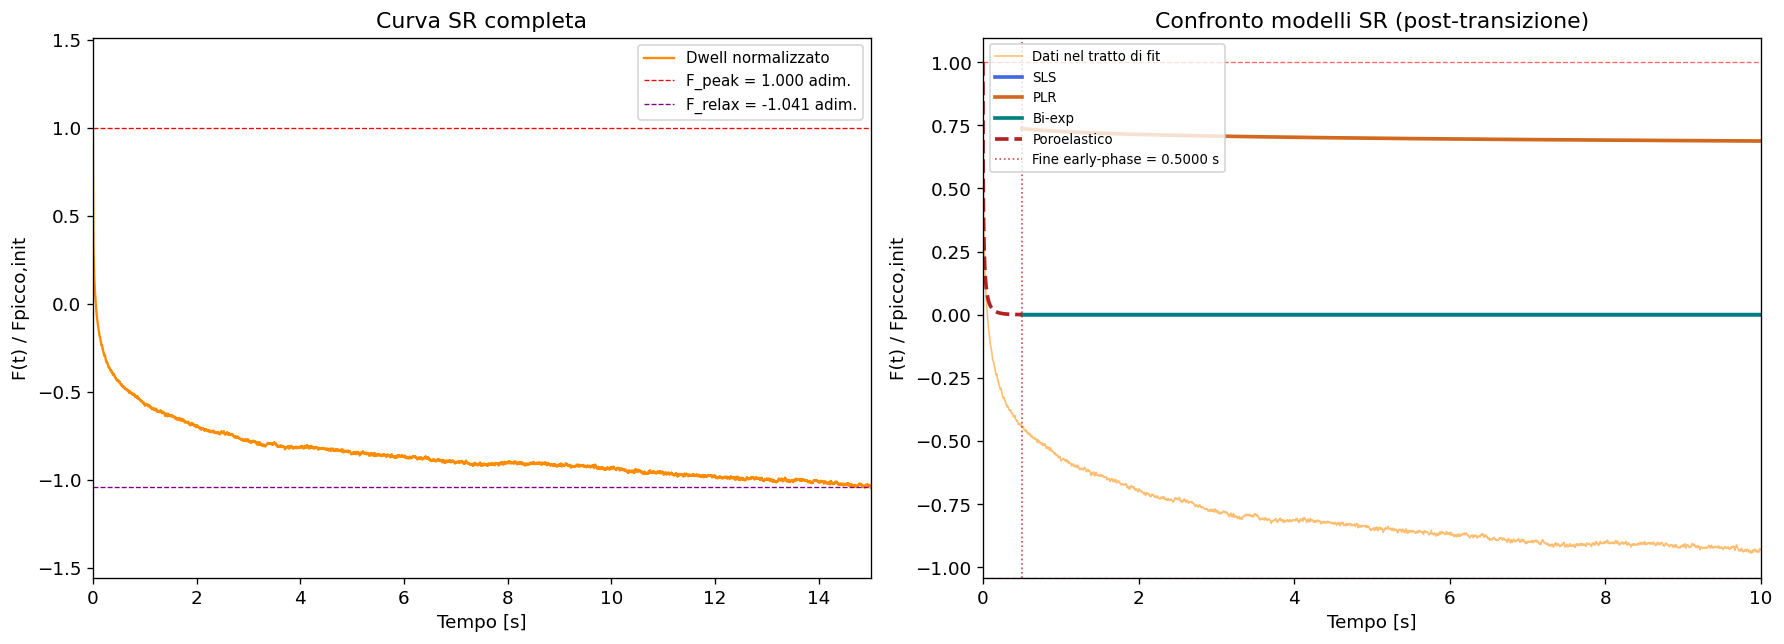

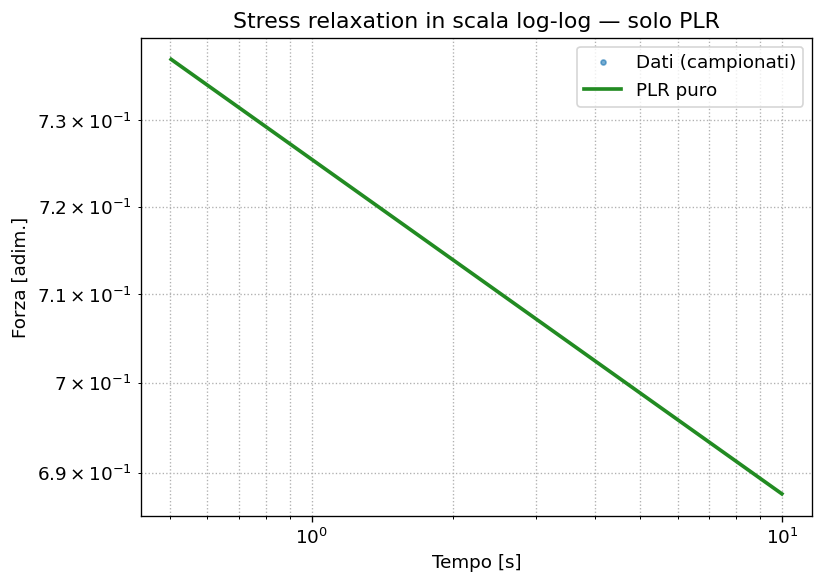

,candidate_t_s,late_model,late_r2,score
11,0.5,plr,-22.817835,0.443868


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.0000, τp=0.0085 s",0.6402
1,post-transizione (t≥0.500s),PLR puro,"t0=0.0000 s, β=0.0232",-0.2043
2,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.0000, w=0.9998, τ1=0.0005 s, τ2=0.0008 s",-22.8178
3,post-transizione (t≥0.500s),SLS,"F∞=0.0000, τ=0.0077 s",-22.8178


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


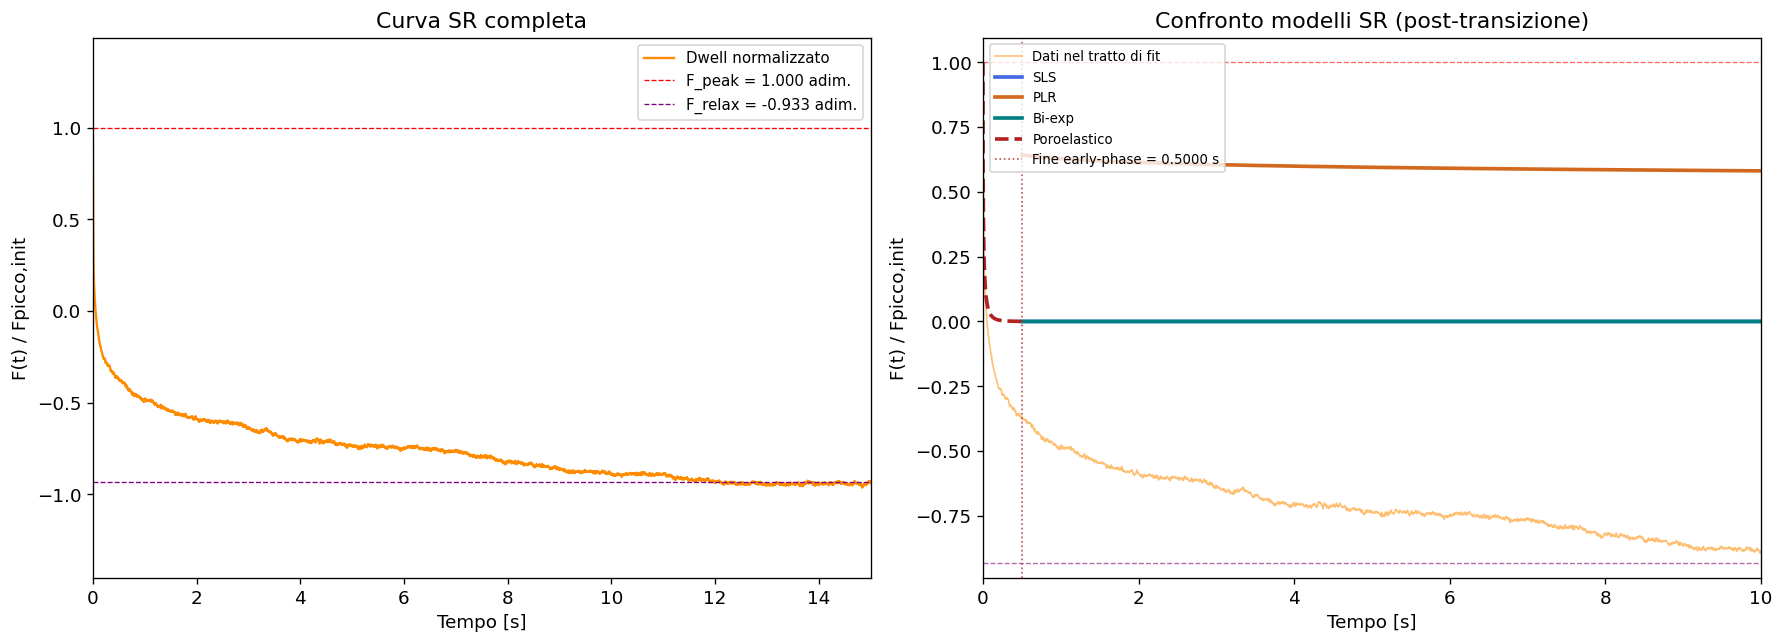

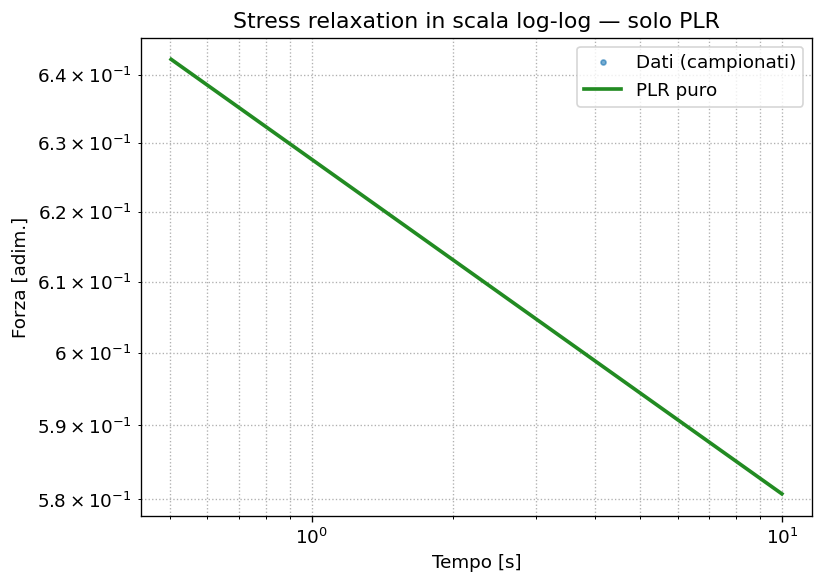

,candidate_t_s,late_model,late_r2,score
11,0.5,mono,-19.459004,0.371503


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.0000, τp=0.0074 s",0.6673
1,post-transizione (t≥0.500s),PLR puro,"t0=0.0000 s, β=0.0337",-0.2757
2,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.0000, w=0.9994, τ1=0.0013 s, τ2=0.0025 s",-19.4590
3,post-transizione (t≥0.500s),SLS,"F∞=0.0000, τ=0.0163 s",-19.4590


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


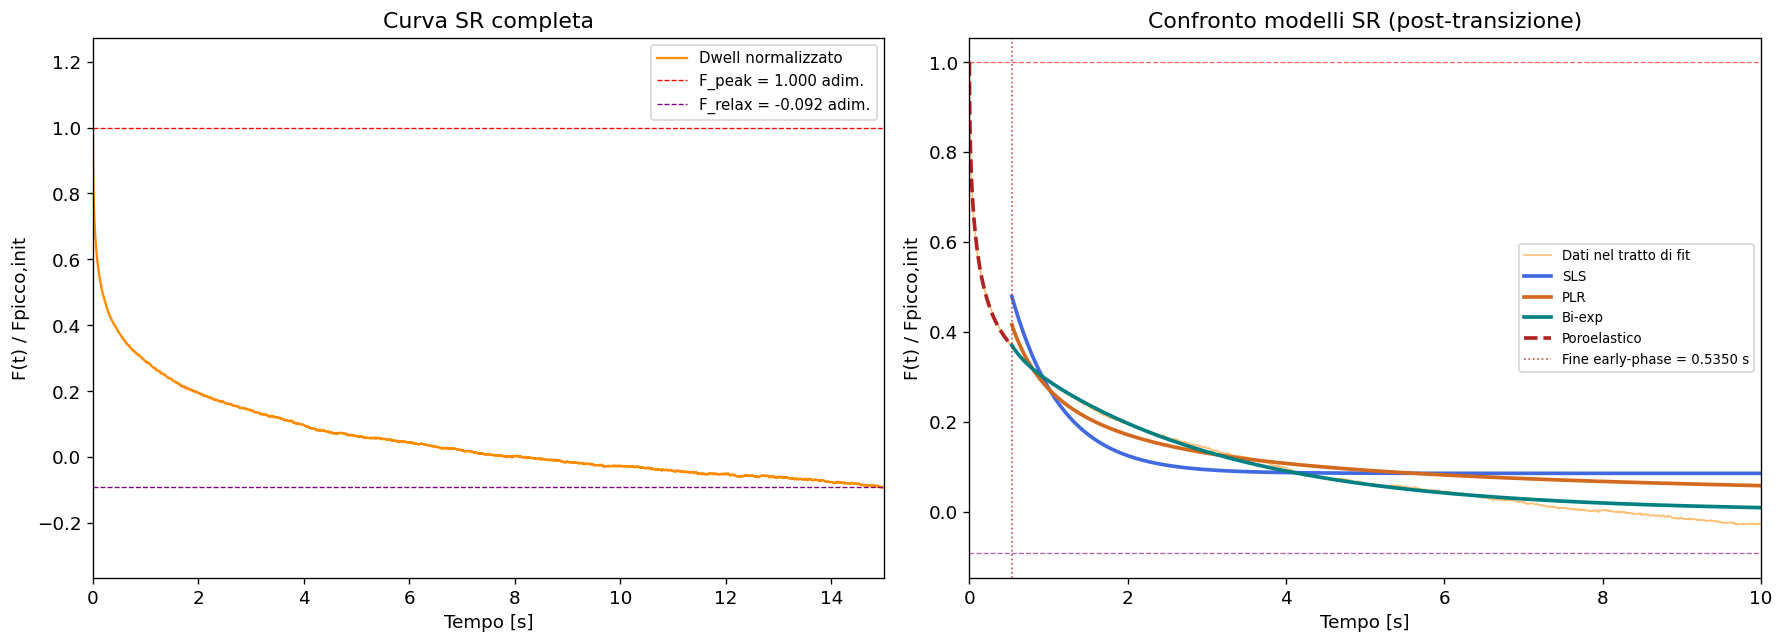

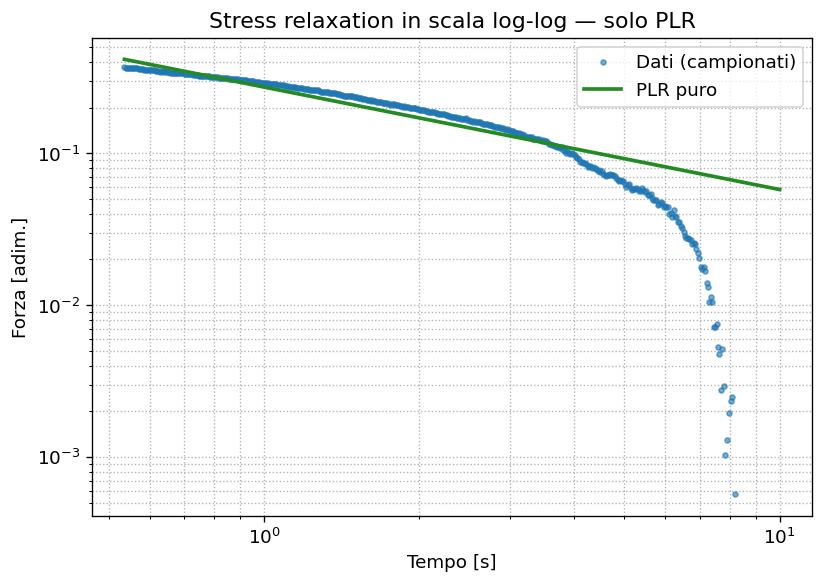

,candidate_t_s,late_model,late_r2,score
13,0.535,bi,0.993582,0.001197


,dominio,modello,parametri,R2
0,early-phase (0-0.535s),Poroelastico,"F∞=0.2687, τp=0.1364 s",0.9937
1,post-transizione (t≥0.535s),Bi-exp GM,"F∞=0.0000, w=0.5735, τ1=0.1673 s, τ2=2.5761 s",0.9936
2,post-transizione (t≥0.535s),PLR puro,"t0=0.1460 s, β=0.6748",0.9349
3,post-transizione (t≥0.535s),SLS,"F∞=0.0851, τ=0.6357 s",0.7510


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


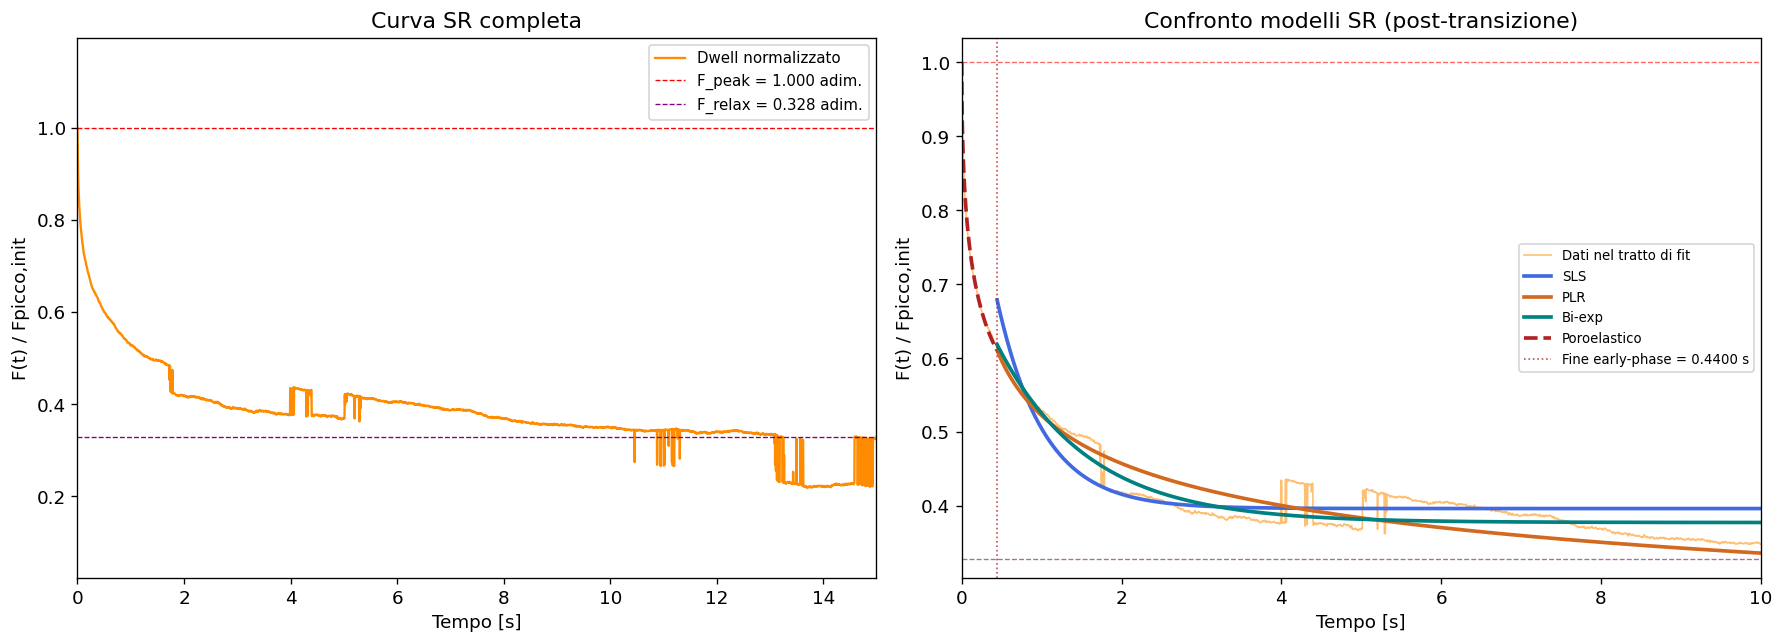

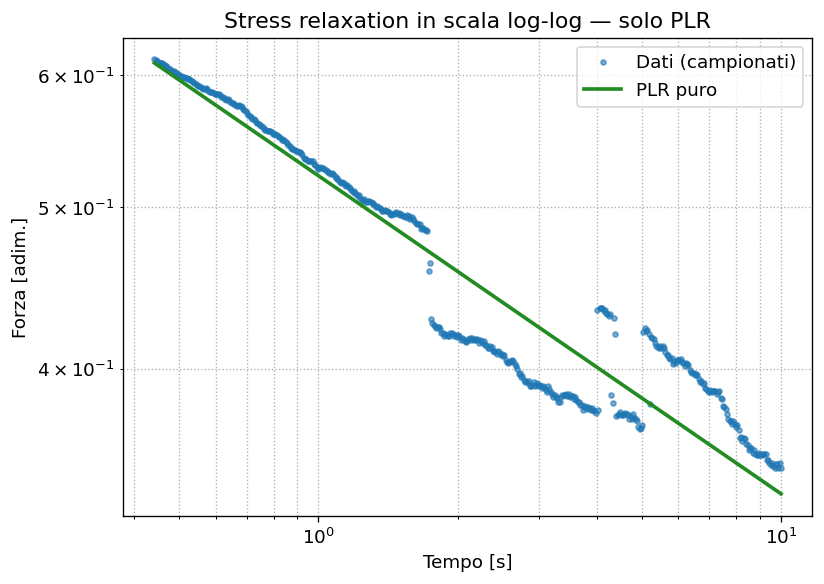

,candidate_t_s,late_model,late_r2,score
0,0.25,bi,0.975917,0.007647
8,0.44,plr,0.920742,0.004578


,dominio,modello,parametri,R2
0,early-phase (0-0.440s),Poroelastico,"F∞=0.4814, τp=0.2276 s",0.9924
1,post-transizione (t≥0.440s),Bi-exp GM,"F∞=0.3778, w=0.4303, τ1=0.0137 s, τ2=1.1409 s",0.9578
2,post-transizione (t≥0.440s),PLR puro,"t0=0.0334 s, β=0.1911",0.9207
3,post-transizione (t≥0.440s),SLS,"F∞=0.3967, τ=0.5815 s",0.8742


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


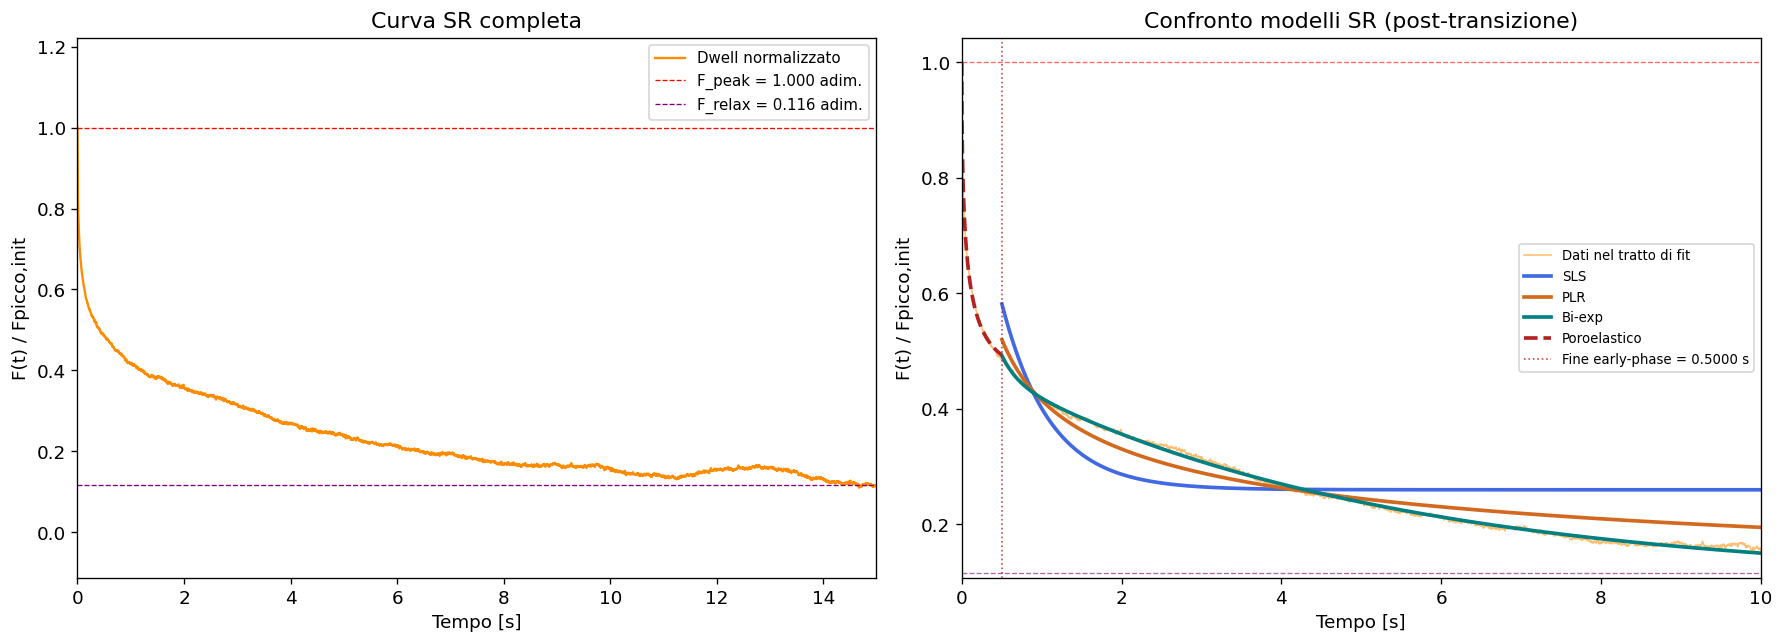

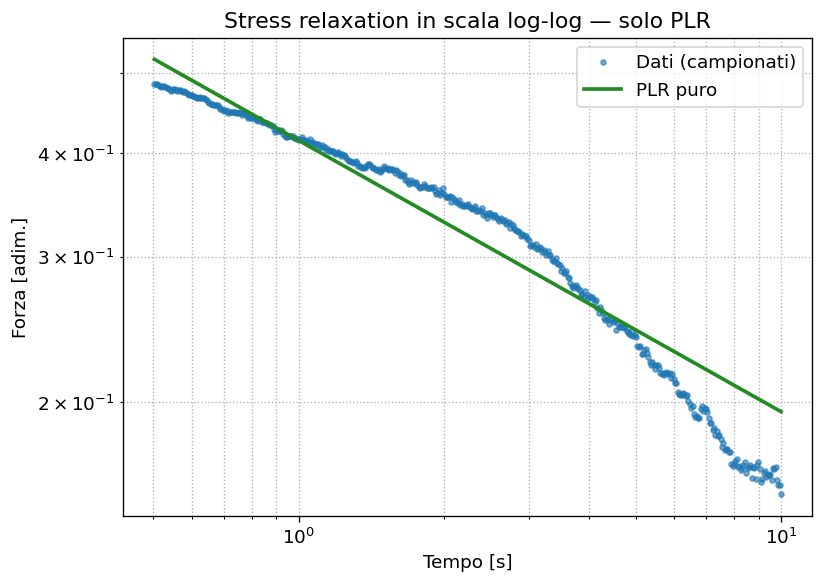

,candidate_t_s,late_model,late_r2,score
11,0.50000,bi,0.998215,0.006172
36,1.08125,plr,0.955599,0.028533


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.4543, τp=0.0717 s",0.9912
1,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.1017, w=0.5713, τ1=0.2032 s, τ2=4.8232 s",0.9982
2,post-transizione (t≥0.500s),PLR puro,"t0=0.0684 s, β=0.3282",0.9512
3,post-transizione (t≥0.500s),SLS,"F∞=0.2598, τ=0.6030 s",0.6753


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


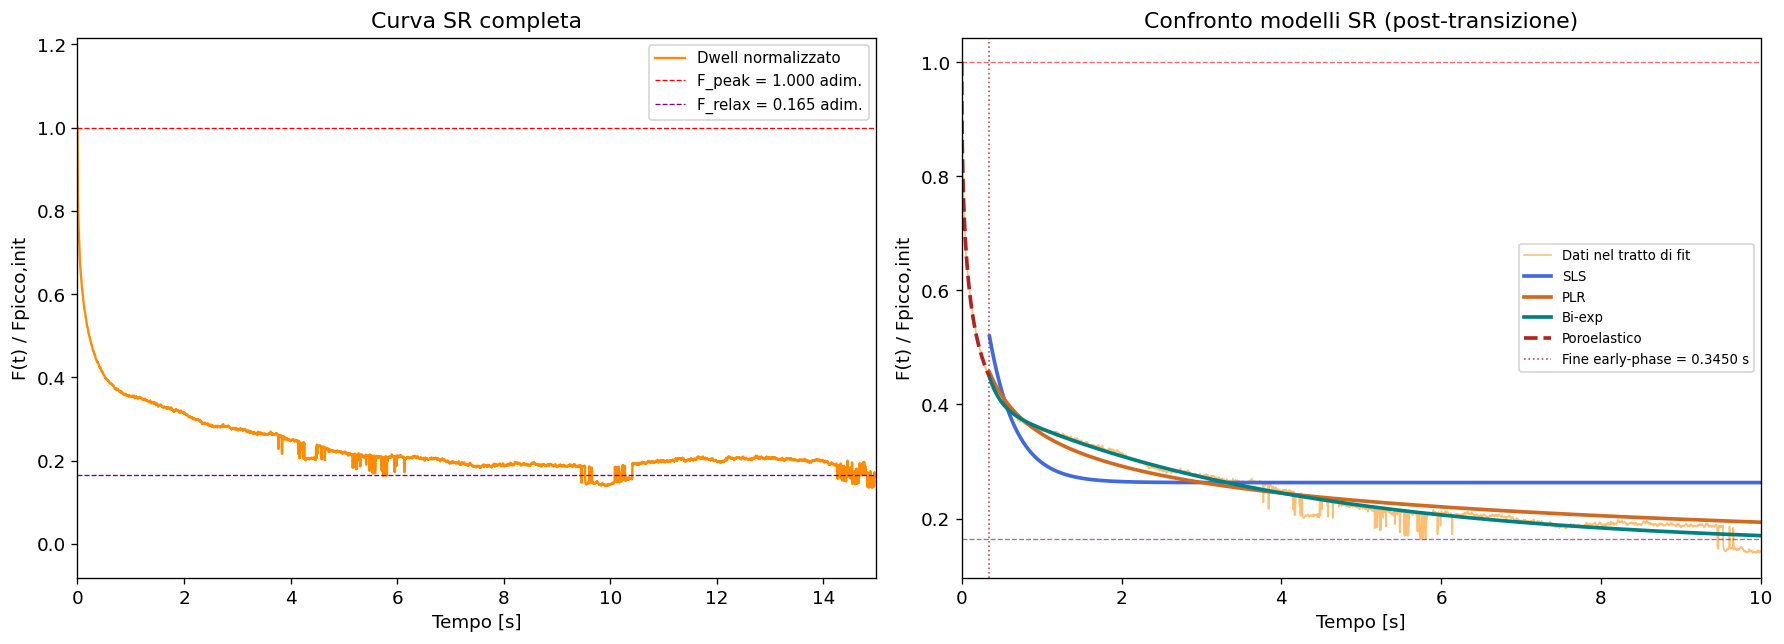

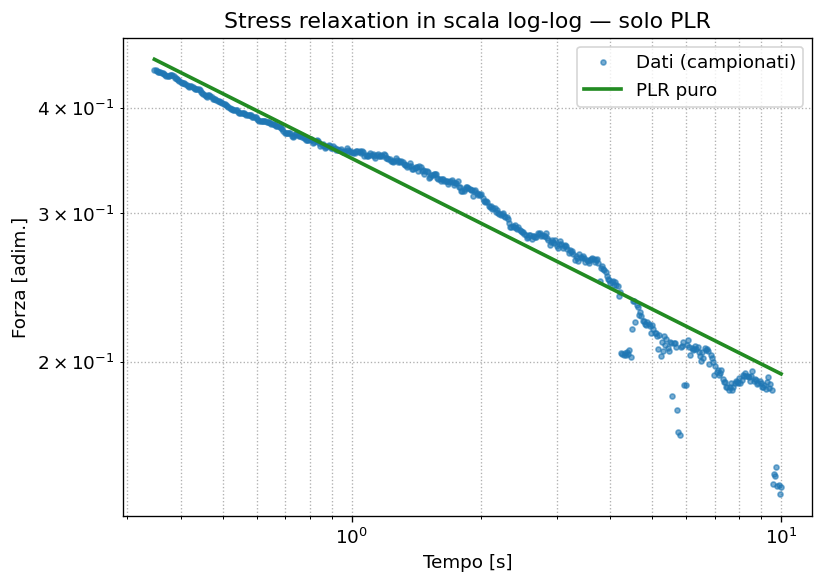

,candidate_t_s,late_model,late_r2,score
4,0.345,bi,0.989293,0.003580
0,0.250,plr,0.968723,0.009388


,dominio,modello,parametri,R2
0,early-phase (0-0.345s),Poroelastico,"F∞=0.3305, τp=0.1156 s",0.9927
1,post-transizione (t≥0.345s),Bi-exp GM,"F∞=0.1504, w=0.6843, τ1=0.1441 s, τ2=3.8288 s",0.9893
2,post-transizione (t≥0.345s),PLR puro,"t0=0.0161 s, β=0.2553",0.9584
3,post-transizione (t≥0.345s),SLS,"F∞=0.2630, τ=0.3286 s",0.5879


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


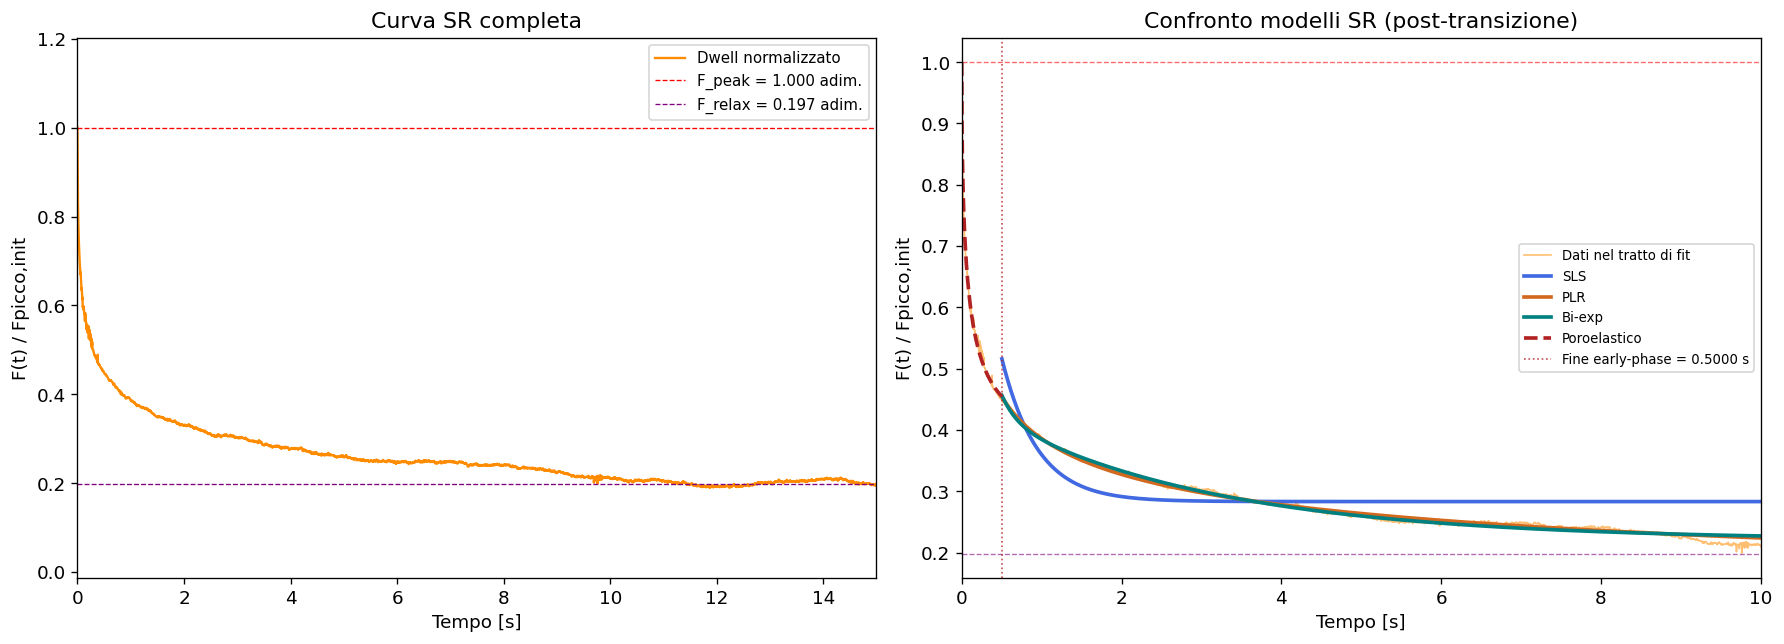

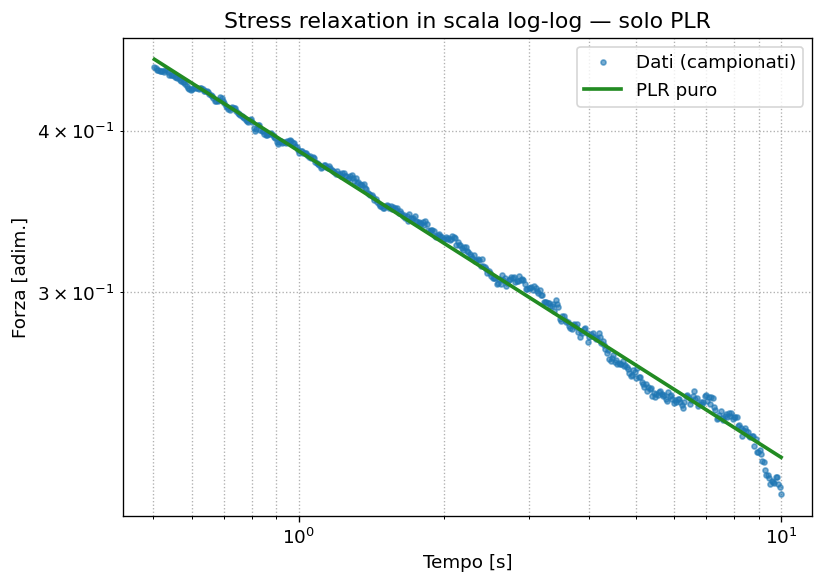

,candidate_t_s,late_model,late_r2,score
14,0.55875,bi,0.996046,0.005874
11,0.50000,plr,0.996432,0.005502


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.3940, τp=0.0946 s",0.9916
1,post-transizione (t≥0.500s),PLR puro,"t0=0.0179 s, β=0.2366",0.9964
2,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.2203, w=0.7074, τ1=0.2004 s, τ2=2.8447 s",0.9960
3,post-transizione (t≥0.500s),SLS,"F∞=0.2831, τ=0.4468 s",0.7272


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


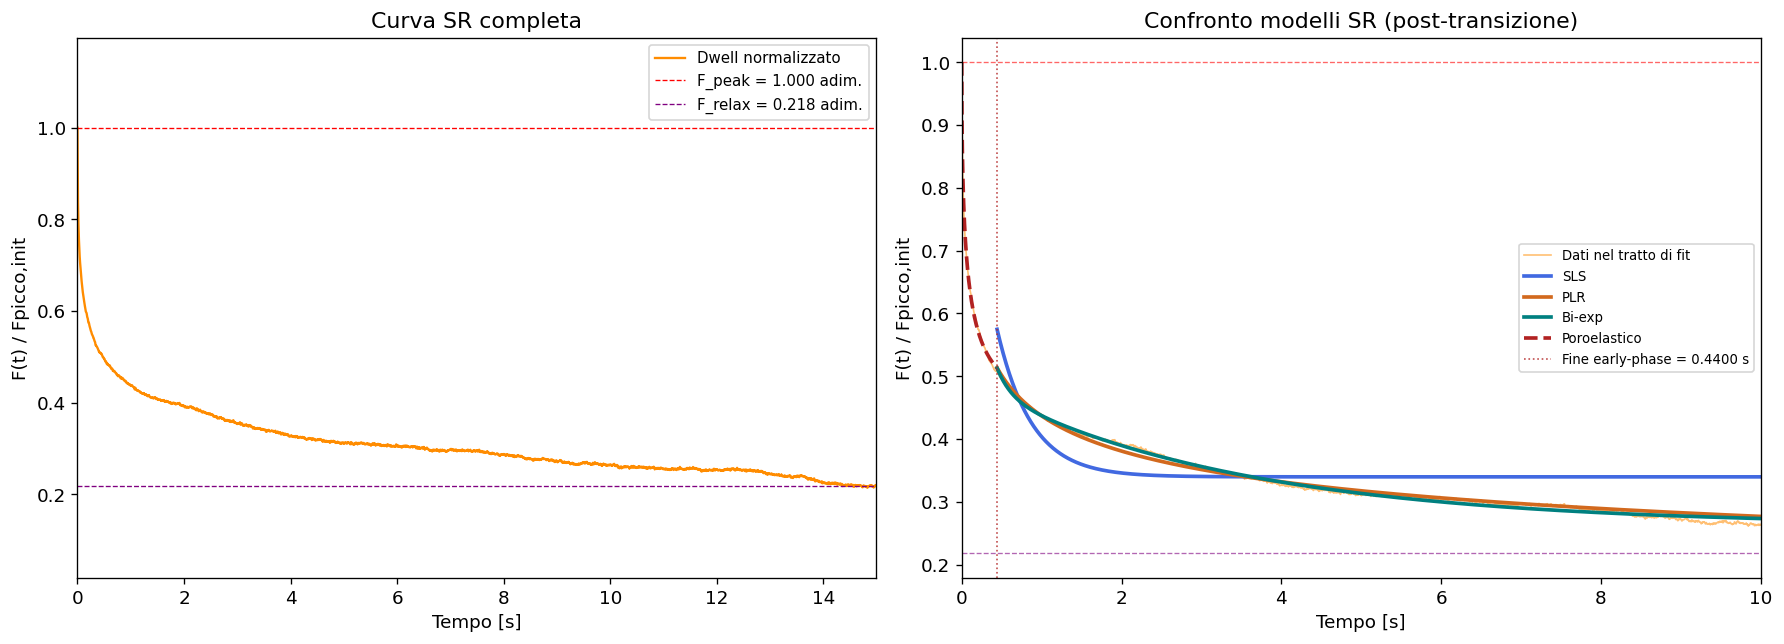

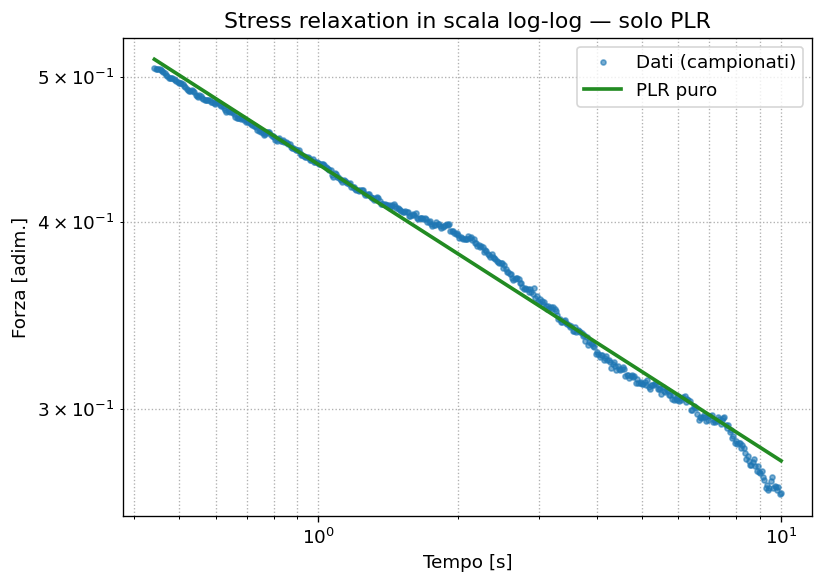

,candidate_t_s,late_model,late_r2,score
8,0.4400,bi,0.997063,0.006015
10,0.4875,plr,0.991855,0.007912


,dominio,modello,parametri,R2
0,early-phase (0-0.440s),Poroelastico,"F∞=0.4600, τp=0.0823 s",0.9916
1,post-transizione (t≥0.440s),Bi-exp GM,"F∞=0.2624, w=0.6825, τ1=0.1848 s, τ2=3.2824 s",0.9971
2,post-transizione (t≥0.440s),PLR puro,"t0=0.0153 s, β=0.1981",0.9924
3,post-transizione (t≥0.440s),SLS,"F∞=0.3399, τ=0.4279 s",0.6893


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


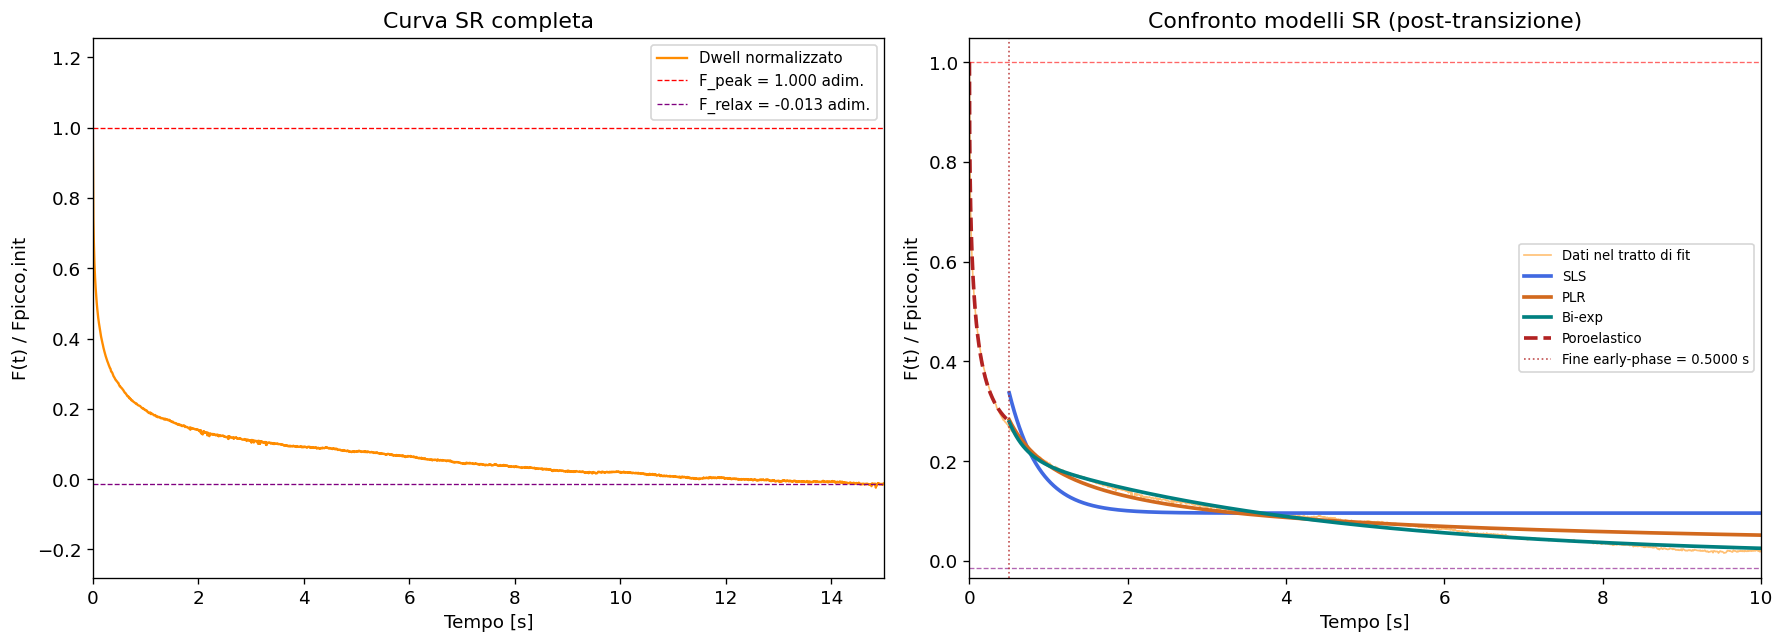

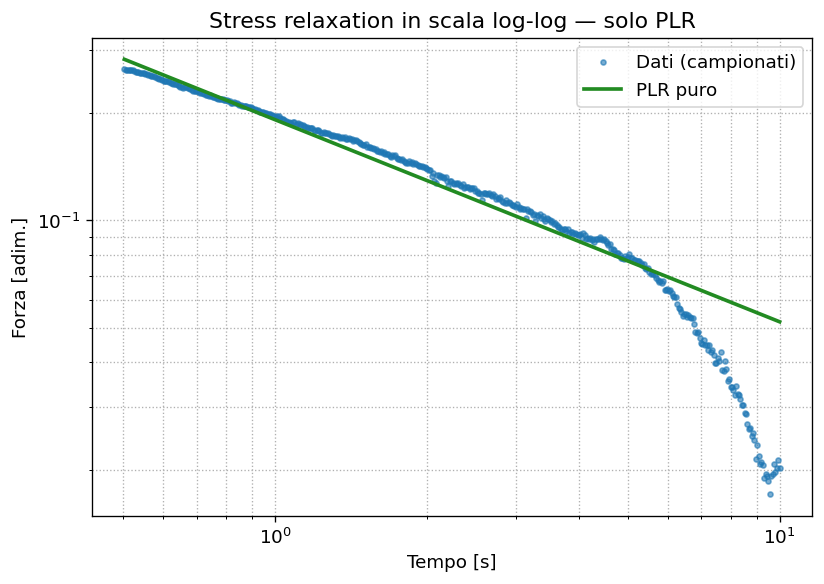

,candidate_t_s,late_model,late_r2,score
11,0.50000,bi,0.994139,0.009693
14,0.55875,plr,0.968199,0.013000


,dominio,modello,parametri,R2
0,early-phase (0-0.500s),Poroelastico,"F∞=0.2291, τp=0.0679 s",0.9912
1,post-transizione (t≥0.500s),Bi-exp GM,"F∞=0.0086, w=0.7695, τ1=0.2101 s, τ2=3.8425 s",0.9941
2,post-transizione (t≥0.500s),PLR puro,"t0=0.0543 s, β=0.5669",0.9704
3,post-transizione (t≥0.500s),SLS,"F∞=0.0961, τ=0.3802 s",0.6893


Nota: curva media generata in memoria → fit eseguito su F(t)/Fpicco,init (nessun CSV salvato)


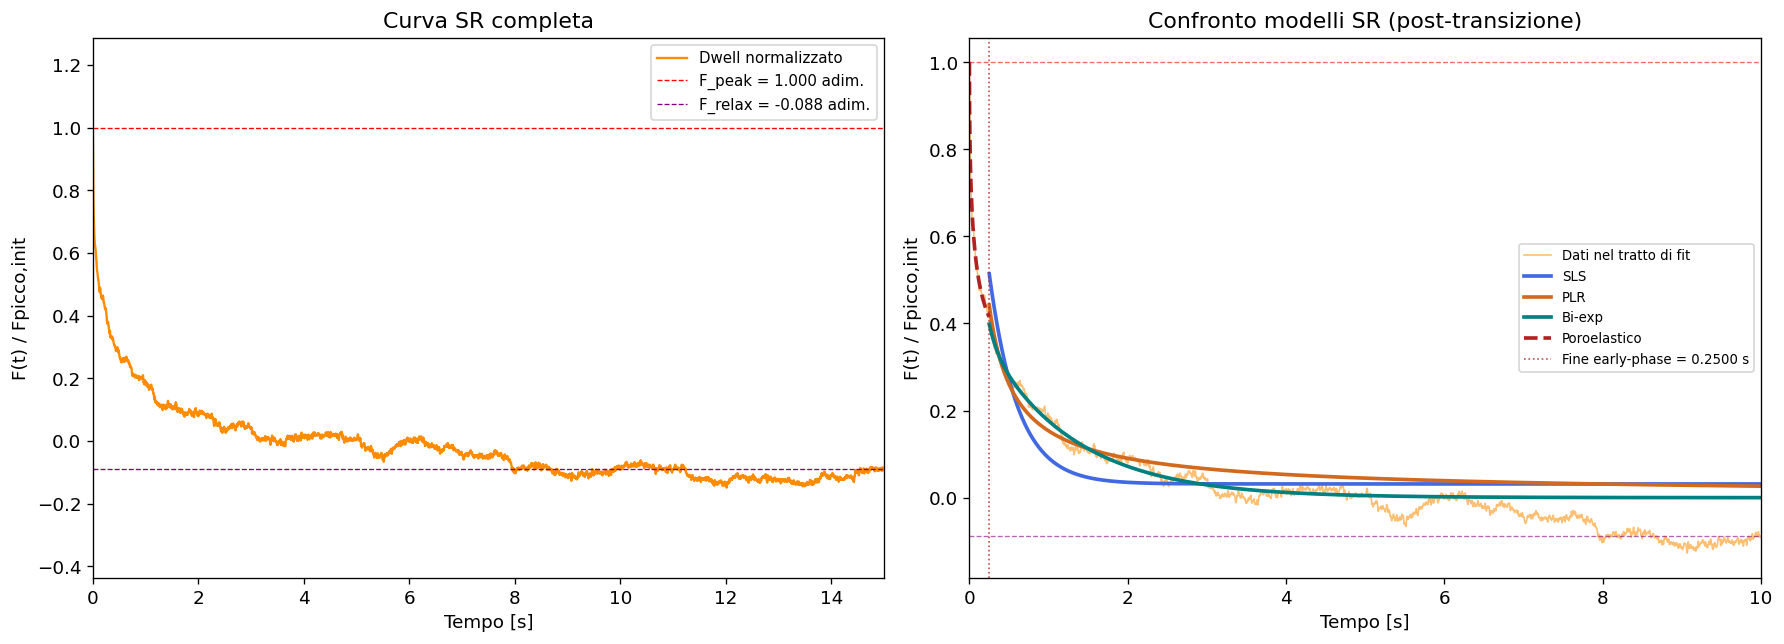

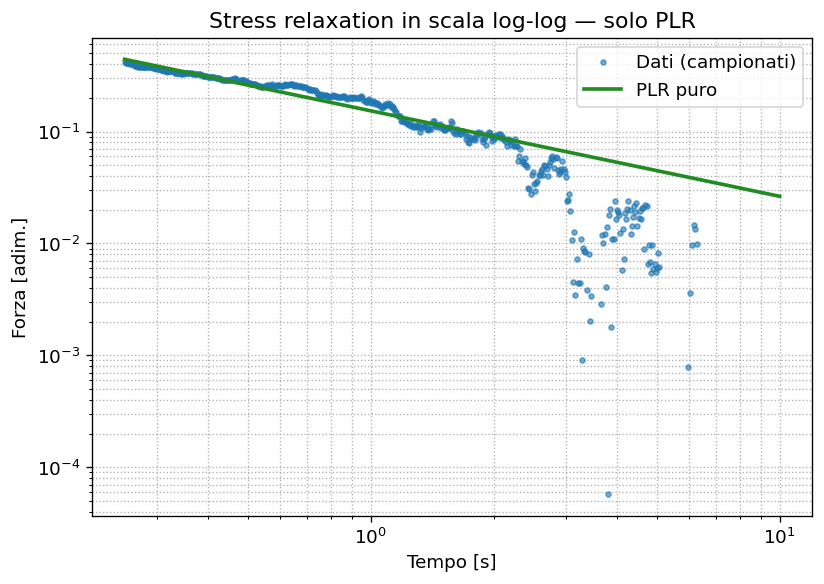

,candidate_t_s,late_model,late_r2,score
0,0.25,bi,0.955248,0.022481


,dominio,modello,parametri,R2
0,early-phase (0-0.250s),Poroelastico,"F∞=0.3078, τp=0.0716 s",0.9818
1,post-transizione (t≥0.250s),Bi-exp GM,"F∞=0.0000, w=0.5685, τ1=0.1059 s, τ2=1.1157 s",0.9552
2,post-transizione (t≥0.250s),PLR puro,"t0=0.0860 s, β=0.7643",0.9483
3,post-transizione (t≥0.250s),SLS,"F∞=0.0315, τ=0.3591 s",0.7816


Controllo qualita SR per condizione:


,condition,N_initial,N_quality_ok
0,EV,18,8
1,RAB5,11,8


Tabella SR per cellula salvata in: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/aggregated/Riassuntoumane/Riassunto/SR/sr_summary_per_cellula_RAB5_EV.csv
Audit qualita SR salvato in: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/aggregated/Riassuntoumane/Riassunto/SR/sr_quality_audit_RAB5_EV.csv
Mann-Whitney U SR a livello cellula:


,parameter,n_RAB5,n_EV,median_RAB5,median_EV,U,p_value,rank_biserial_r
0,F_relax,8,8,0.140533,0.001057,44.0,0.234499,0.37500
1,transition_s,8,8,0.470000,0.392500,37.0,0.635006,0.15625


Test SR salvato in: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/aggregated/Riassuntoumane/Riassunto/SR/sr_mann_whitney_RAB5_EV.csv


In [76]:
# 9. Tabella SR per cellula, controlli di qualita e Mann-Whitney RAB5 vs EV
# Questa sezione usa le curve medie gia caricate e filtrate: non richiede nuovi CSV raw.
import contextlib
import io
import re
from scipy.stats import mannwhitneyu

SR_R2_MIN = 0.70
SR_TAU_MIN_S = 1e-3
SR_T0_MIN_S = 1e-3
SR_TAUP_MAX_S = transition_time_s
SR_SAVE_DIR = Path(output_folder) / "Riassunto" / "SR"
SR_SAVE_DIR.mkdir(parents=True, exist_ok=True)


def infer_sr_condition(text):
    label = str(text).upper()
    if "RAB5" in label or re.search(r"(^|[_/])A1([_/]|$)", label):
        return "RAB5"
    if "EV" in label or re.search(r"(^|[_/])0R([_/]|$)", label):
        return "EV"
    return None


def sr_location_ids(curve):
    source = Path(str(curve.get("source_path", "")))
    cell_id = source.parent.name
    day = source.parent.parent.name
    return day, cell_id


def finite_or_nan(value):
    try:
        value = float(value)
        return value if np.isfinite(value) else np.nan
    except Exception:
        return np.nan


sr_rows = []
for curve in filtered_curves:
    condition = infer_sr_condition(f"{curve.get('label', '')} {curve.get('source_path', '')}")
    if condition not in {"RAB5", "EV"}:
        continue

    curve_name = str(curve.get("label", Path(curve.get("source_path", "curve")).stem))
    day_id, cell_id = sr_location_ids(curve)
    try:
        analysis_input = {
            "is_generated_mean": True,
            "folder_path": str(SR_SAVE_DIR),
            "base_name": re.sub(r"[^A-Za-z0-9_.-]+", "_", curve_name),
            "display_name": curve_name,
            "time": np.asarray(curve["time"], dtype=float),
            "force": np.asarray(curve["normalized_force"], dtype=float),
            "std": None,
            "distance": np.asarray(curve.get("distance", np.full(len(curve["time"]), np.nan)), dtype=float),
            "csv_path": None,
            "jpk_path": None,
        }
        sr_input = load_sr_curve(analysis_input, input_force_mode="auto", normalized_reference="Fpicco,init")
        with contextlib.redirect_stdout(io.StringIO()):
            result = run_sr_analysis(
                sr=sr_input,
                analysis_input_path=analysis_input,
                save_outputs=False,
                open_output_folder=False,
                plot_max_time_s=plot_max_time_s,
                fit_spike_filter_window=visual_spike_window,
                fit_spike_filter_z=visual_spike_z,
                fit_smoothing_window=smoothing_window,
                transition_time_s=transition_time_s,
                auto_optimize_transition=auto_optimize_transition,
                transition_search_range_s=transition_search_range_s,
                transition_search_steps=transition_search_steps,
                transition_max_join_gap=transition_max_join_gap,
                transition_max_local_rmse=transition_max_local_rmse,
                transition_late_models=("plr", "bi", "mono"),
                transition_min_late_r2=transition_min_late_r2,
                show_transition_diagnostic_plot=False,
            )

        fit_results = result.get("fit_results", {})
        metrics = result.get("global_metrics", {})
        plr_fit = fit_results.get("plr")
        bi_fit = fit_results.get("bi")
        poro_fit = fit_results.get("poro")
        selected_model = "bi" if condition == "RAB5" else "plr"
        selected_r2 = finite_or_nan(metrics.get(selected_model, {}).get("R2"))
        f_relax = finite_or_nan(result.get("F_relax"))
        transition_s = finite_or_nan(result.get("transition_time_selected_s"))
        taup_s = finite_or_nan(poro_fit[1]) if poro_fit is not None and len(poro_fit) > 1 else np.nan

        row = {
            "condition": condition,
            "source": curve_name,
            "day": day_id,
            "cell_id": cell_id,
            "F_relax": f_relax,
            "selected_model": selected_model,
            "selected_r2": selected_r2,
            "transition_s": transition_s,
            "taup_s": taup_s,
            "quality_r2_ok": bool(np.isfinite(selected_r2) and selected_r2 >= SR_R2_MIN),
            "quality_tau_ok": bool(selected_model != "bi" or (np.isfinite(taup_s) and taup_s <= SR_TAUP_MAX_S)),
            "quality_params_ok": True,
        }
        if selected_model == "plr" and plr_fit is not None:
            row.update({"beta": finite_or_nan(plr_fit[2]), "t0_s": finite_or_nan(plr_fit[1]), "w": np.nan, "tau1_s": np.nan, "tau2_s": np.nan})
            row["quality_params_ok"] = bool(np.isfinite(row["beta"]) and np.isfinite(row["t0_s"]) and row["beta"] > 0 and row["t0_s"] >= SR_T0_MIN_S)
        elif selected_model == "bi" and bi_fit is not None:
            row.update({"beta": np.nan, "t0_s": np.nan, "w": finite_or_nan(bi_fit[1]), "tau1_s": finite_or_nan(bi_fit[2]), "tau2_s": finite_or_nan(bi_fit[3])})
            row["quality_params_ok"] = bool(np.isfinite(row["w"]) and np.isfinite(row["tau1_s"]) and np.isfinite(row["tau2_s"]) and 0 <= row["w"] <= 1 and row["tau1_s"] >= SR_TAU_MIN_S and row["tau2_s"] >= SR_TAU_MIN_S)
        else:
            row.update({"beta": np.nan, "t0_s": np.nan, "w": np.nan, "tau1_s": np.nan, "tau2_s": np.nan})
        row["quality_ok"] = bool(row["quality_r2_ok"] and row["quality_tau_ok"] and row["quality_params_ok"])
        sr_rows.append(row)
    except Exception as exc:
        sr_rows.append({"condition": condition, "source": curve_name, "day": day_id, "cell_id": cell_id, "quality_ok": False, "error": str(exc)})

sr_cell_df = pd.DataFrame(sr_rows)
if sr_cell_df.empty:
    raise ValueError("Nessuna curva SR classificata come RAB5/EV disponibile per il fit per-cellula.")

sr_quality_log = sr_cell_df.groupby("condition", dropna=False).agg(N_initial=("source", "size"), N_quality_ok=("quality_ok", "sum")).reset_index()
print("Controllo qualita SR per condizione:")
display(sr_quality_log)
sr_filtered_df = sr_cell_df[sr_cell_df["quality_ok"]].copy()
sr_cell_csv = SR_SAVE_DIR / "sr_summary_per_cellula_RAB5_EV.csv"
sr_filtered_df.to_csv(sr_cell_csv, index=False)
sr_quality_csv = SR_SAVE_DIR / "sr_quality_audit_RAB5_EV.csv"
sr_quality_log.to_csv(sr_quality_csv, index=False)
print(f"Tabella SR per cellula salvata in: {sr_cell_csv}")
print(f"Audit qualita SR salvato in: {sr_quality_csv}")


def sr_mw_rows(frame, parameters):
    rows = []
    for parameter in parameters:
        rab5 = pd.to_numeric(frame.loc[frame["condition"] == "RAB5", parameter], errors="coerce").dropna().to_numpy(dtype=float)
        ev = pd.to_numeric(frame.loc[frame["condition"] == "EV", parameter], errors="coerce").dropna().to_numpy(dtype=float)
        if len(rab5) == 0 or len(ev) == 0:
            continue
        u_stat, p_value = mannwhitneyu(rab5, ev, alternative="two-sided", method="auto")
        rows.append({"parameter": parameter, "n_RAB5": len(rab5), "n_EV": len(ev), "median_RAB5": float(np.median(rab5)), "median_EV": float(np.median(ev)), "U": float(u_stat), "p_value": float(p_value), "rank_biserial_r": float(2 * u_stat / (len(rab5) * len(ev)) - 1)})
    return pd.DataFrame(rows)

sr_mw_df = sr_mw_rows(sr_filtered_df, ["F_relax", "beta", "t0_s", "w", "tau1_s", "tau2_s", "transition_s"])
sr_mw_csv = SR_SAVE_DIR / "sr_mann_whitney_RAB5_EV.csv"
sr_mw_df.to_csv(sr_mw_csv, index=False)
print("Mann-Whitney U SR a livello cellula:")
display(sr_mw_df)
print(f"Test SR salvato in: {sr_mw_csv}")